# Separate codes for each model

Device: cuda
GPU: Tesla T4
Memory: 15.83 GB
Target shape: torch.Size([1, 64, 64])
Target range: [0.000, 1.000]


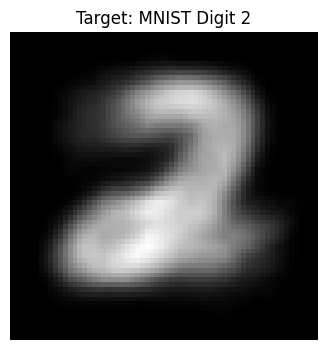


✅ Setup complete! TARGET variable is ready.
   Save directory: ./nca_comparison_results


In [7]:
"""
Block 1: Setup & Utilities
Run this first before any other blocks.
"""

import os
import time
import json
import warnings
import gc
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIGURATION
# ==============================================================================
@dataclass
class Config:
    save_dir: str = "./nca_comparison_results"
    img_size: int = 64
    target_digit: int = 2
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 42
    mixed_precision: bool = True
    grad_clip: float = 1.0
    gif_fps: int = 30
    gif_duration_sec: float = 10.0

# Global config
cfg = Config()

# Setup
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)
    torch.backends.cudnn.benchmark = True
os.makedirs(cfg.save_dir, exist_ok=True)

print(f"Device: {cfg.device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ==============================================================================
# DATA LOADING
# ==============================================================================
def load_mnist_digit(digit: int, size: int, num_samples: int = 1000):
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
    ])
    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    indices = [i for i, (_, label) in enumerate(dataset) if label == digit][:num_samples]
    images = torch.stack([dataset[i][0] for i in indices])
    return images

def get_target_image(digit: int = 2, size: int = 64):
    images = load_mnist_digit(digit, size, num_samples=100)
    target = images.mean(dim=0)
    target = (target - target.min()) / (target.max() - target.min() + 1e-8)
    return target

# Load target
TARGET = get_target_image(cfg.target_digit, cfg.img_size).to(cfg.device)
print(f"Target shape: {TARGET.shape}")
print(f"Target range: [{TARGET.min():.3f}, {TARGET.max():.3f}]")

# Save target image
plt.figure(figsize=(4, 4))
plt.imshow(TARGET.squeeze().cpu().numpy(), cmap='gray')
plt.title(f'Target: MNIST Digit {cfg.target_digit}')
plt.axis('off')
plt.savefig(os.path.join(cfg.save_dir, 'target.png'), dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================================
# METRICS
# ==============================================================================
def compute_psnr(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    mse = F.mse_loss(pred, target).item()
    if mse < 1e-10:
        return 100.0
    return 10 * np.log10(max_val ** 2 / mse)

def compute_ssim(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    return F.cosine_similarity(pred_flat.unsqueeze(0), target_flat.unsqueeze(0)).item()

def get_memory_usage() -> float:
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1e6
    return 0.0

def reset_memory_stats():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

def compute_error_map(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.abs(pred - target)

# ==============================================================================
# VISUALIZATION
# ==============================================================================
def save_gif(frames: List[torch.Tensor], save_path: str, fps: int = 30):
    if not frames:
        print(f"Warning: No frames to save for {save_path}")
        return
    imgs = []
    for frame in frames:
        if isinstance(frame, torch.Tensor):
            frame = frame.detach().cpu().squeeze().numpy()
        frame = (np.clip(frame, 0, 1) * 255).astype(np.uint8)
        imgs.append(frame)
    imageio.mimsave(save_path, imgs, duration=1000//fps, loop=0)
    print(f"Saved GIF: {save_path}")

def plot_results(model_name: str, target: torch.Tensor, output: torch.Tensor, 
                 error_map: torch.Tensor, loss_history: List[float], 
                 psnr: float, ssim: float, train_time: float, 
                 temporal_frames: List = None, temporal_steps: List = None):
    """Plot comprehensive results for a model."""
    
    fig = plt.figure(figsize=(16, 10))
    
    # Row 1: Output comparison
    ax1 = fig.add_subplot(2, 4, 1)
    ax1.imshow(target.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax1.set_title('Target', fontsize=12)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(2, 4, 2)
    ax2.imshow(output.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax2.set_title(f'{model_name} Output', fontsize=12)
    ax2.axis('off')
    
    ax3 = fig.add_subplot(2, 4, 3)
    im = ax3.imshow(error_map.squeeze().cpu().numpy(), cmap='hot', vmin=0, vmax=0.5)
    ax3.set_title(f'Error Map (Mean: {error_map.mean():.4f})', fontsize=12)
    ax3.axis('off')
    plt.colorbar(im, ax=ax3, fraction=0.046)
    
    # Metrics box
    ax4 = fig.add_subplot(2, 4, 4)
    ax4.axis('off')
    metrics_text = f"""
    Model: {model_name}
    
    PSNR: {psnr:.2f} dB
    SSIM: {ssim:.4f}
    Final Loss: {loss_history[-1]:.6f}
    Train Time: {train_time/60:.2f} min
    """
    ax4.text(0.1, 0.5, metrics_text, fontsize=14, verticalalignment='center',
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightgray'))
    
    # Row 2: Training curve
    ax5 = fig.add_subplot(2, 4, 5)
    ax5.plot(loss_history, 'b-', alpha=0.8)
    ax5.set_xlabel('Step/Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training Loss')
    ax5.grid(True, alpha=0.3)
    
    ax6 = fig.add_subplot(2, 4, 6)
    ax6.plot(np.log10(np.array(loss_history) + 1e-10), 'b-', alpha=0.8)
    ax6.set_xlabel('Step/Epoch')
    ax6.set_ylabel('log10(Loss)')
    ax6.set_title('Training Loss (Log Scale)')
    ax6.grid(True, alpha=0.3)
    
    # Temporal evolution (if available)
    if temporal_frames and temporal_steps:
        ax7 = fig.add_subplot(2, 4, (7, 8))
        n_frames = min(len(temporal_frames), 8)
        for i in range(n_frames):
            ax_sub = fig.add_axes([0.52 + i*0.058, 0.1, 0.05, 0.15])
            ax_sub.imshow(temporal_frames[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            ax_sub.set_title(f'{temporal_steps[i]}', fontsize=8)
            ax_sub.axis('off')
        ax7.axis('off')
        ax7.set_title('Temporal Evolution', fontsize=12, y=0.85)
    
    plt.suptitle(f'{model_name} Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, f'{model_name.lower().replace(" ", "_")}_results.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Setup complete! TARGET variable is ready.")
print(f"   Save directory: {cfg.save_dir}")


Training: CNN Generator
Parameters: 2,502,081
Epoch  180/200 | Loss: 0.000039 | LR: 1.00e-03

Final Loss: 0.000035
PSNR: 43.94 dB | SSIM: 0.9999
Training Time: 0.03 min | Peak Memory: 349.07 MB


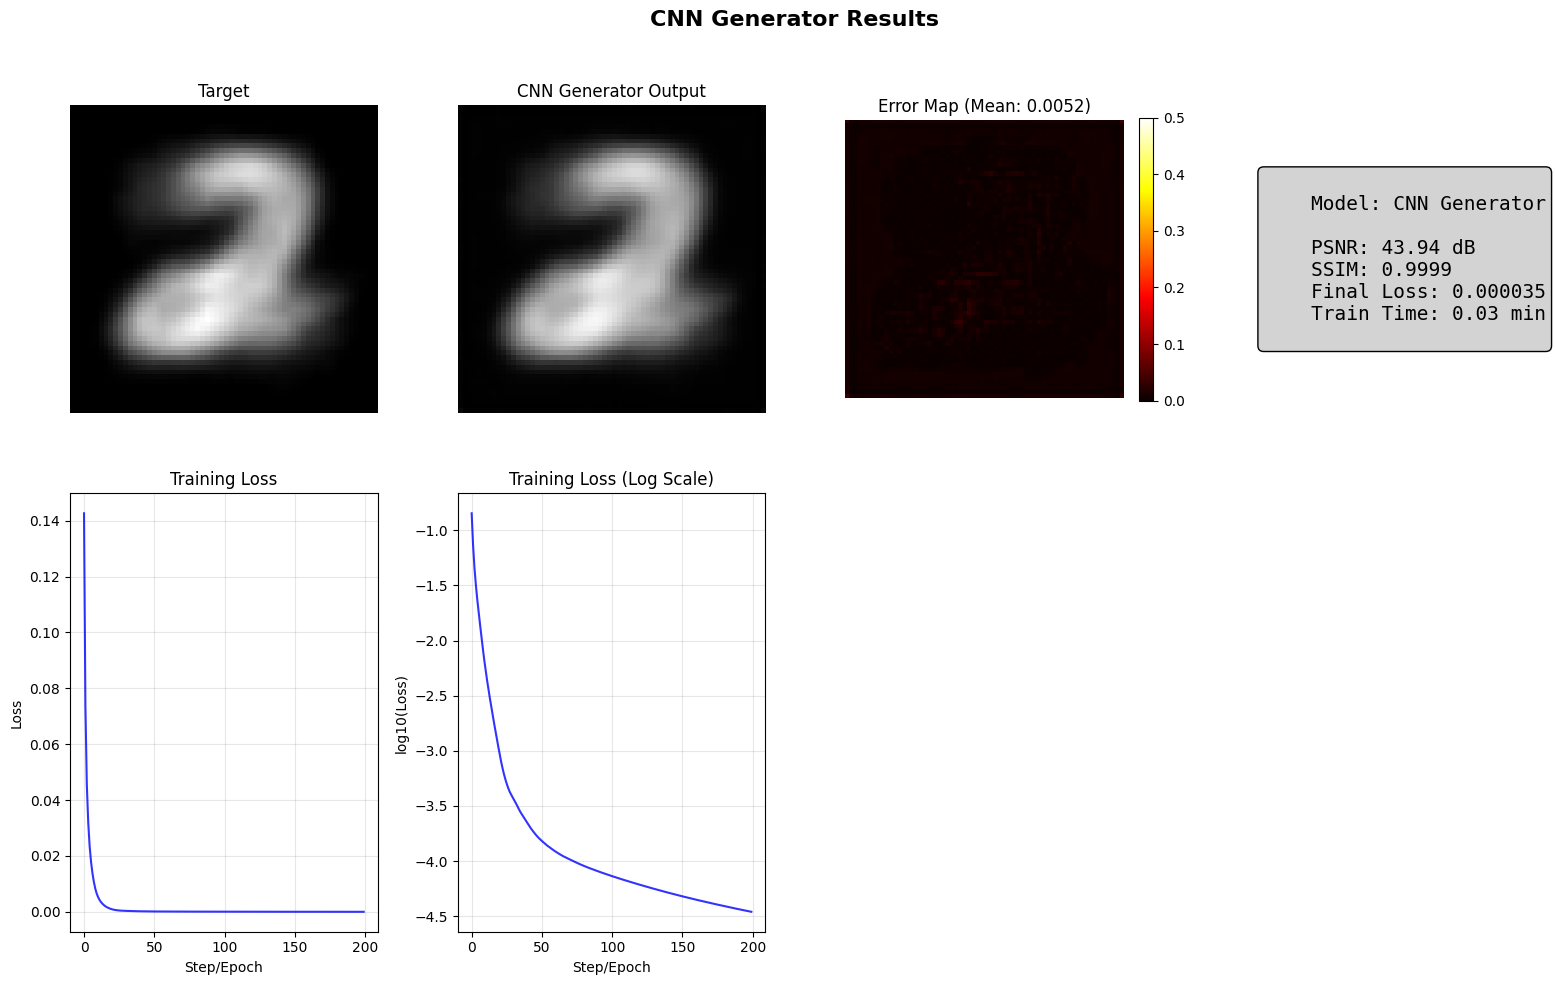

In [8]:
"""
Block 2: CNN Generator Training
Run Block 1 first!
"""

# ==============================================================================
# CNN GENERATOR MODEL
# ==============================================================================
class CNNGenerator(nn.Module):
    def __init__(self, latent_dim: int = 128, img_size: int = 64):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size = img_size
        self.init_size = img_size // 8
        
        self.fc = nn.Linear(latent_dim, 256 * self.init_size ** 2)
        
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Sigmoid()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.shape[0], 256, self.init_size, self.init_size)
        return self.conv_blocks(x)

# ==============================================================================
# TRAINING
# ==============================================================================
def train_cnn(epochs: int = 200, lr: float = 1e-3, latent_dim: int = 128):
    print("\n" + "="*60)
    print("Training: CNN Generator")
    print("="*60)
    
    reset_memory_stats()
    device = cfg.device
    target = TARGET.to(device)
    
    model = CNNGenerator(latent_dim=latent_dim, img_size=cfg.img_size).to(device)
    latent = nn.Parameter(torch.randn(1, latent_dim, device=device))
    
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    optimizer = torch.optim.Adam(list(model.parameters()) + [latent], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
    
    loss_history = []
    best_loss = float('inf')
    best_state = None
    best_latent = None
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        output = model(latent)
        loss = F.mse_loss(output, target.unsqueeze(0))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [latent], cfg.grad_clip)
        optimizer.step()
        scheduler.step(loss)
        
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        if loss_val < best_loss:
            best_loss = loss_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_latent = latent.detach().cpu().clone()
        
        if epoch % 20 == 0:
            print(f"\rEpoch {epoch:4d}/{epochs} | Loss: {loss_val:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}", end='')
    
    train_time = time.time() - start_time
    peak_memory = get_memory_usage()
    
    # Evaluation
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_output = model(best_latent.to(device))[0]
    
    psnr = compute_psnr(final_output.cpu(), target.cpu())
    ssim = compute_ssim(final_output.cpu(), target.cpu())
    error_map = compute_error_map(final_output.cpu(), target.cpu())
    
    print(f"\n\nFinal Loss: {best_loss:.6f}")
    print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")
    print(f"Training Time: {train_time/60:.2f} min | Peak Memory: {peak_memory:.2f} MB")
    
    # Plot results
    plot_results('CNN Generator', target.cpu(), final_output.cpu(), error_map,
                 loss_history, psnr, ssim, train_time)
    
    # Save model
    torch.save(best_state, os.path.join(cfg.save_dir, 'cnn_best.pth'))
    
    return {
        'model_name': 'CNN Generator',
        'final_loss': best_loss,
        'psnr': psnr,
        'ssim': ssim,
        'train_time': train_time,
        'peak_memory': peak_memory,
        'loss_history': loss_history,
        'final_output': final_output.cpu(),
        'parameters': sum(p.numel() for p in model.parameters())
    }

# Run training
cnn_results = train_cnn(epochs=200, lr=1e-3)


Training: Canonical NCA (Fixed for Grayscale)
Parameters: 22,480
Config: channels=16, hidden=128, fire_rate=0.5
Training: 10000 steps, batch=8, inner_steps=48-96
Loss: MSE + Perceptual (weight=0.5)
FIXED: Full image loss (no masking), activity-based alive mask
Step 10000/10000 | Loss: 0.000100 | log10: -4.001 | LR: 2.00e-04

Generating temporal evolution...
Generating GIF...
Saved GIF: ./nca_comparison_results/canonical_nca_growth.gif

Training Complete!
Final Loss: 0.000095
PSNR: 33.48 dB | SSIM: 0.9986
Training Time: 23.05 min | Peak Memory: 1999.81 MB


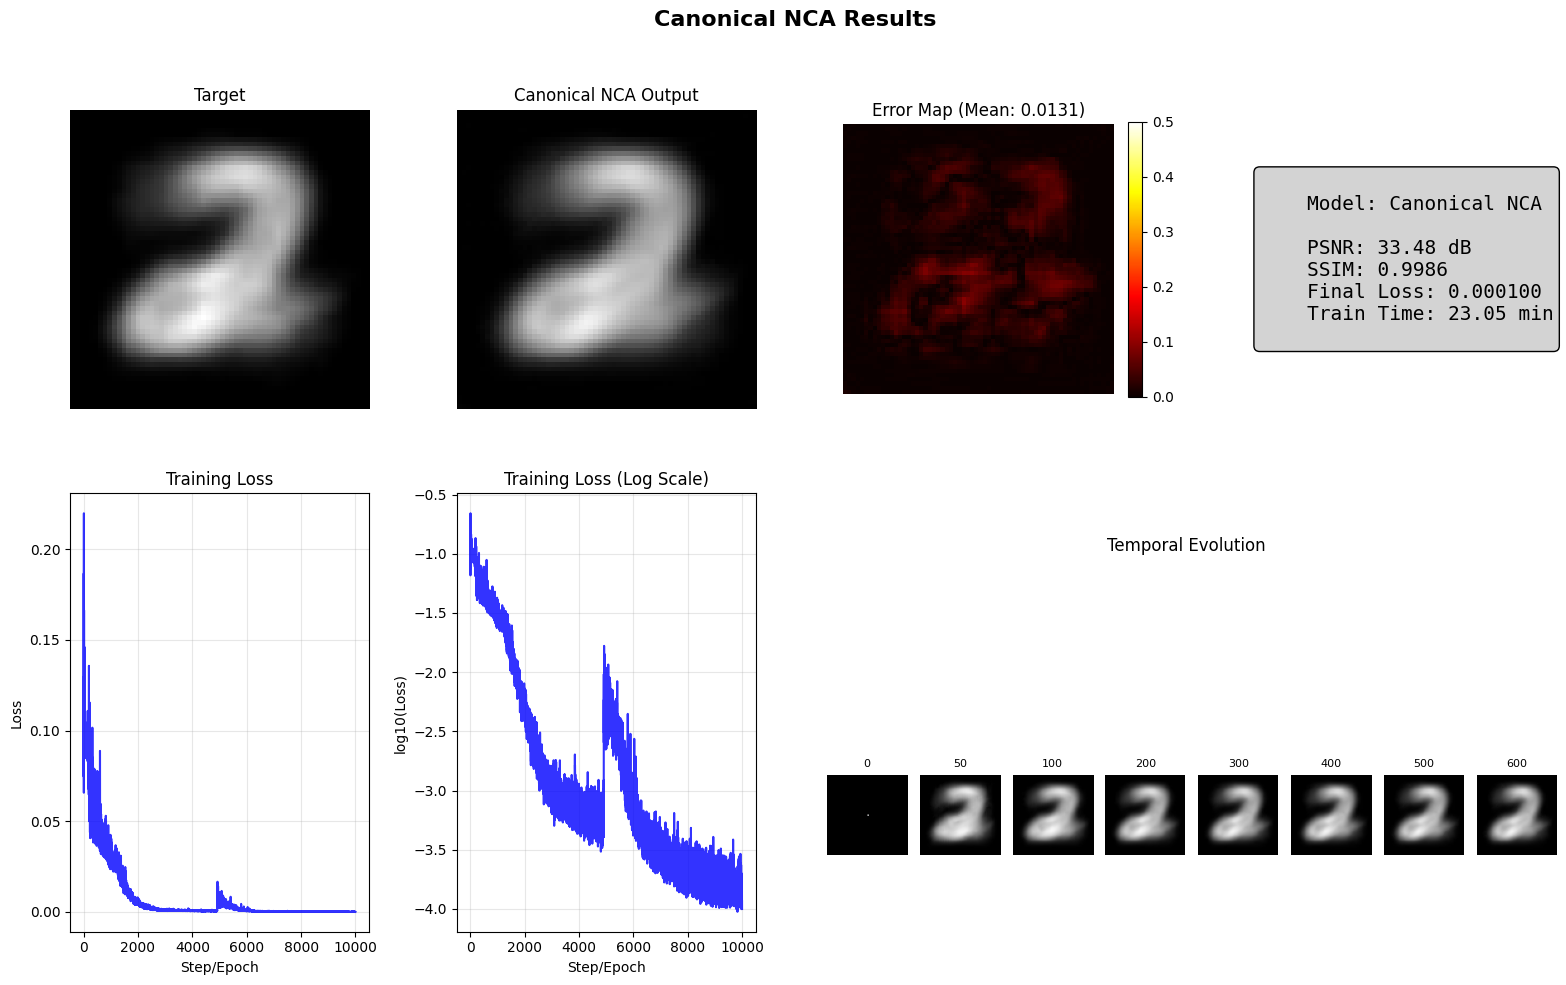

Model saved to ./nca_comparison_results/canonical_nca_best.pth

✅ Canonical NCA training complete!
   PSNR: 33.48 dB
   SSIM: 0.9986


In [9]:
"""
Block 3: Canonical NCA Training (Fixed for Grayscale/MNIST)
============================================================
Fixed issues:
1. Alive masking based on ACTIVITY (any channel), not brightness
2. Loss computed over ENTIRE image, not just bright regions
3. Works correctly for grayscale where dark pixels ARE the content

Run Block 1 first!
"""

# ==============================================================================
# CANONICAL NCA MODEL (Fixed for Grayscale)
# ==============================================================================
class CanonicalNCA(nn.Module):
    """
    Canonical NCA fixed for grayscale images (MNIST).
    
    Key fixes:
    - Alive masking based on cell activity across ALL channels
    - Works for images where dark pixels are the content (like MNIST digits)
    """
    
    def __init__(self, channels: int = 16, hidden_size: int = 128, fire_rate: float = 0.5, 
                 dx_clip: Optional[float] = None):
        super().__init__()
        self.channels = channels
        self.fire_rate = fire_rate
        self.dx_clip = dx_clip
        
        # Perception conv - initialized with Sobel filters
        self.perception = nn.Conv2d(channels, channels * 3, 3, padding=1, bias=False)
        
        # Update network (deeper for better capacity)
        self.dmodel = nn.Sequential(
            nn.Conv2d(channels * 3, hidden_size, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_size, hidden_size // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_size // 2, channels, 1)
        )
        
        # Zero init for stable start
        nn.init.zeros_(self.dmodel[-1].weight)
        nn.init.zeros_(self.dmodel[-1].bias)
        
        self._initialized = False
    
    def _init_weights(self):
        """Initialize perception filters with identity, Sobel-x, Sobel-y."""
        if self._initialized:
            return
        
        with torch.no_grad():
            dev = self.perception.weight.device
            
            # Identity filter (neighbor average)
            ident = torch.tensor([[0, 1, 0],
                                  [1, 0, 1],
                                  [0, 1, 0]], dtype=torch.float32, device=dev) / 4.0
            
            # Sobel-x filter
            dx = torch.tensor([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]], dtype=torch.float32, device=dev) / 8.0
            
            # Sobel-y filter
            dy = torch.tensor([[-1, -2, -1],
                               [0,  0,  0],
                               [1,  2,  1]], dtype=torch.float32, device=dev) / 8.0
            
            self.perception.weight.zero_()
            for i in range(self.channels):
                self.perception.weight[i * 3 + 0, i] = ident
                self.perception.weight[i * 3 + 1, i] = dx
                self.perception.weight[i * 3 + 2, i] = dy
        
        self._initialized = True
    
    def perceive(self, x: torch.Tensor) -> torch.Tensor:
        """Apply perception filters."""
        return self.perception(x)
    
    def get_alive_mask(self, x: torch.Tensor) -> torch.Tensor:
        """
        FIXED: Activity-based alive mask for grayscale.
        
        OLD (broken for grayscale):
            alive = F.max_pool2d(x[:, :1], 3, 1, 1) > 0.01
            This kills cells where the visible channel is dark (i.e., the digit!)
        
        NEW (works for grayscale):
            Use max absolute value across ALL channels as activity indicator.
            A cell is alive if it OR its neighbors have any activity.
        """
        # Max absolute value across all channels = activity level
        activity = torch.max(torch.abs(x), dim=1, keepdim=True)[0]
        
        # Cell is alive if it or neighbors have activity
        alive = F.max_pool2d(activity, kernel_size=3, stride=1, padding=1) > 0.01
        
        return alive.float()
    
    def update(self, x: torch.Tensor, perception: torch.Tensor, fire_rate: Optional[float] = None) -> torch.Tensor:
        """Compute and apply state update with fixed alive masking."""
        dx = self.dmodel(perception)
        
        # Clip for stability
        if self.dx_clip is not None:
            dx = dx.clamp(-self.dx_clip, self.dx_clip)
        
        fr = self.fire_rate if fire_rate is None else fire_rate
        
        # Stochastic update during training
        if self.training:
            mask = (torch.rand(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) <= fr).float()
            x = x + dx * mask
        else:
            x = x + dx
        
        # FIXED: Activity-based alive mask
        alive = self.get_alive_mask(x)
        
        return x * alive
    
    def forward(self, x: torch.Tensor, fire_rate: Optional[float] = None) -> torch.Tensor:
        """Single NCA step."""
        if not self._initialized:
            self._init_weights()
        
        y = self.perceive(x)
        return self.update(x, y, fire_rate)


# ==============================================================================
# SAMPLE POOL
# ==============================================================================
class NCAPool:
    """Sample pool for NCA training."""
    
    def __init__(self, size: int, channels: int, img_size: int, device: torch.device):
        self.size = size
        self.channels = channels
        self.img_size = img_size
        self.device = device
        self.pool = self._make_seeds(size, channels, img_size, device)
    
    def _make_seeds(self, n: int, channels: int, img_size: int, device: torch.device) -> torch.Tensor:
        """Create seed states with single active pixel in center."""
        seed = torch.zeros(n, channels, img_size, img_size, device=device)
        center = img_size // 2
        # Initialize ALL channels at center (strong seed signal)
        seed[:, :, center, center] = 1.0
        return seed
    
    def sample(self, n: int) -> Tuple[torch.Tensor, np.ndarray]:
        idx = np.random.choice(self.size, n, replace=False)
        return self.pool[idx].clone(), idx
    
    def commit(self, idx: np.ndarray, states: torch.Tensor):
        self.pool[idx] = states.detach()


# ==============================================================================
# LOSS FUNCTIONS (Fixed for Grayscale - Full Image Loss)
# ==============================================================================
def compute_mse_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Simple MSE loss over ENTIRE image.
    
    For grayscale MNIST, we MUST compute loss over all pixels because:
    - Dark pixels (low values) ARE the digit
    - Bright pixels (high values) ARE the background
    - Both matter equally!
    """
    return F.mse_loss(pred, target)


def compute_perceptual_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Gradient-matching loss for edge preservation.
    Helps the NCA learn sharp boundaries.
    """
    # Sobel kernels
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], 
                           dtype=torch.float32, device=pred.device).view(1, 1, 3, 3) / 4.0
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], 
                           dtype=torch.float32, device=pred.device).view(1, 1, 3, 3) / 4.0
    
    # Compute gradients
    pred_gx = F.conv2d(pred, sobel_x, padding=1)
    pred_gy = F.conv2d(pred, sobel_y, padding=1)
    target_gx = F.conv2d(target, sobel_x, padding=1)
    target_gy = F.conv2d(target, sobel_y, padding=1)
    
    # Gradient loss
    return F.mse_loss(pred_gx, target_gx) + F.mse_loss(pred_gy, target_gy)


def compute_combined_loss(pred: torch.Tensor, target: torch.Tensor, 
                          x_full: torch.Tensor = None,
                          perceptual_weight: float = 0.5,
                          hidden_reg_weight: float = 0.0001) -> torch.Tensor:
    """
    Combined loss for NCA training.
    
    Components:
    1. MSE loss over entire image (main reconstruction loss)
    2. Perceptual loss for edge preservation
    3. Optional regularization on hidden channels
    """
    # Main MSE loss
    mse_loss = compute_mse_loss(pred, target)
    
    # Perceptual loss
    perc_loss = compute_perceptual_loss(pred, target)
    
    # Total loss
    loss = mse_loss + perceptual_weight * perc_loss
    
    # Optional: regularize hidden channels to prevent explosion
    if x_full is not None and hidden_reg_weight > 0:
        hidden_reg = hidden_reg_weight * torch.mean(x_full[:, 1:] ** 2)
        loss = loss + hidden_reg
    
    return loss


# ==============================================================================
# TRAINING FUNCTION (Fixed for Grayscale)
# ==============================================================================
def train_canonical_nca(
    train_steps: int = 10000,
    channels: int = 16,
    hidden_size: int = 128,
    fire_rate: float = 0.5,
    lr: float = 2e-3,
    lr_decay_step: int = 4000,
    batch_size: int = 8,
    pool_size: int = 512,
    min_steps: int = 48,
    max_steps: int = 96,
    eval_steps: int = 600,
    dx_clip: Optional[float] = None,
    use_perceptual_loss: bool = True,
    perceptual_weight: float = 0.5
):
    """
    Train Canonical NCA - Fixed for grayscale images.
    
    Key fixes:
    - Loss computed over ENTIRE image (no masking)
    - Alive masking based on activity, not brightness
    - Perceptual loss for better edge preservation
    """
    print("\n" + "="*60)
    print("Training: Canonical NCA (Fixed for Grayscale)")
    print("="*60)
    
    # Clear memory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    
    device = cfg.device
    target = TARGET.to(device)
    
    # Create model
    model = CanonicalNCA(
        channels=channels,
        hidden_size=hidden_size,
        fire_rate=fire_rate,
        dx_clip=dx_clip
    ).to(device)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {num_params:,}")
    print(f"Config: channels={channels}, hidden={hidden_size}, fire_rate={fire_rate}")
    print(f"Training: {train_steps} steps, batch={batch_size}, inner_steps={min_steps}-{max_steps}")
    print(f"Loss: MSE + Perceptual (weight={perceptual_weight})" if use_perceptual_loss else "Loss: MSE only")
    print(f"FIXED: Full image loss (no masking), activity-based alive mask")
    
    # Expand target to match channels (channel 0 = visible grayscale)
    target_full = torch.zeros(1, channels, cfg.img_size, cfg.img_size, device=device)
    target_full[:, :1] = target.unsqueeze(0)
    
    # Optimizer with cosine annealing
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    def lr_lambda(step):
        if step < lr_decay_step:
            return 1.0
        else:
            progress = (step - lr_decay_step) / (train_steps - lr_decay_step + 1)
            return max(0.1, 0.5 * (1 + np.cos(np.pi * progress)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Mixed precision
    use_amp = cfg.mixed_precision and torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    # Sample pool
    pool = NCAPool(pool_size, channels, cfg.img_size, device)
    seed = pool._make_seeds(1, channels, cfg.img_size, device)
    
    # Training tracking
    loss_history = []
    best_loss = float('inf')
    best_state = None
    temporal_frames = []
    temporal_steps = [0, 50, 100, 200, 300, 400, 500, 600]
    
    start_time = time.time()
    
    for step in range(train_steps + 1):
        model.train()
        
        # Sample from pool
        batch_x, pool_idx = pool.sample(batch_size)
        batch_x[0:1] = seed.clone()
        
        # Random inner steps
        n_steps = np.random.randint(min_steps, max_steps)
        
        # Forward pass
        with torch.amp.autocast('cuda', enabled=use_amp):
            x = batch_x
            for _ in range(n_steps):
                x = model(x)
            
            # FIXED: Loss on visible channel over ENTIRE image
            pred = x[:, :1]
            tgt = target_full[:, :1].expand(batch_size, -1, -1, -1)
            
            if use_perceptual_loss:
                loss = compute_combined_loss(pred, tgt, x, perceptual_weight)
            else:
                loss = compute_mse_loss(pred, tgt)
        
        # Backward
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        # Update pool
        pool.commit(pool_idx, x)
        
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        # Track best
        if loss_val < best_loss:
            best_loss = loss_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        # Logging
        if step % 100 == 0:
            log10_loss = np.log10(loss_val + 1e-10)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"\rStep {step:5d}/{train_steps} | Loss: {loss_val:.6f} | log10: {log10_loss:.3f} | LR: {current_lr:.2e}", end='')
    
    train_time = time.time() - start_time
    peak_memory = get_memory_usage()
    
    # Load best
    model.load_state_dict(best_state)
    model.eval()
    
    # Generate temporal evolution
    print("\n\nGenerating temporal evolution...")
    with torch.no_grad():
        x = seed.clone()
        for s in range(eval_steps + 1):
            if s in temporal_steps:
                temporal_frames.append(x[0, :1].cpu().clone())
            x = model(x, fire_rate=1.0)
        final_output = x[0, :1]
    
    # GIF
    print("Generating GIF...")
    gif_frames = []
    with torch.no_grad():
        x = seed.clone()
        num_gif_frames = int(cfg.gif_fps * cfg.gif_duration_sec)
        steps_per_frame = max(1, eval_steps // num_gif_frames)
        
        for s in range(eval_steps):
            x = model(x, fire_rate=1.0)
            if s % steps_per_frame == 0:
                gif_frames.append(x[0, :1].cpu().clone())
    
    save_gif(gif_frames, os.path.join(cfg.save_dir, 'canonical_nca_growth.gif'), fps=cfg.gif_fps)
    
    # Metrics
    psnr = compute_psnr(final_output.cpu(), target.cpu())
    ssim = compute_ssim(final_output.cpu(), target.cpu())
    error_map = compute_error_map(final_output.cpu(), target.cpu())
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"{'='*60}")
    print(f"Final Loss: {best_loss:.6f}")
    print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")
    print(f"Training Time: {train_time/60:.2f} min | Peak Memory: {peak_memory:.2f} MB")
    
    # Plot
    plot_results(
        'Canonical NCA',
        target.cpu(),
        final_output.cpu(),
        error_map,
        loss_history,
        psnr,
        ssim,
        train_time,
        temporal_frames,
        temporal_steps[:len(temporal_frames)]
    )
    
    # Save
    torch.save(best_state, os.path.join(cfg.save_dir, 'canonical_nca_best.pth'))
    print(f"Model saved to {os.path.join(cfg.save_dir, 'canonical_nca_best.pth')}")
    
    return {
        'model_name': 'Canonical NCA',
        'final_loss': best_loss,
        'psnr': psnr,
        'ssim': ssim,
        'train_time': train_time,
        'peak_memory': peak_memory,
        'loss_history': loss_history,
        'final_output': final_output.cpu(),
        'error_map': error_map,
        'temporal_frames': temporal_frames,
        'temporal_steps': temporal_steps[:len(temporal_frames)],
        'gif_frames': gif_frames,
        'best_state': best_state,
        'parameters': num_params
    }


# ==============================================================================
# RUN TRAINING
# ==============================================================================
nca_results = train_canonical_nca(
    train_steps=10000,       # Good number of steps
    channels=16,             # 16 channels (first is visible)
    hidden_size=128,         # Hidden layer size
    fire_rate=0.5,           # Standard fire rate
    lr=2e-3,                 # Learning rate
    lr_decay_step=4000,      # Decay LR after this
    batch_size=8,            # Batch size
    pool_size=512,           # Pool for diversity
    min_steps=48,            # Min inner steps
    max_steps=96,            # Max inner steps
    eval_steps=600,          # Steps for final generation
    dx_clip=None,            # No clipping (set to 0.25 if unstable)
    use_perceptual_loss=True,  # Edge-preserving loss
    perceptual_weight=0.5    # Weight for perceptual loss
)

print("\n✅ Canonical NCA training complete!")
print(f"   PSNR: {nca_results['psnr']:.2f} dB")
print(f"   SSIM: {nca_results['ssim']:.4f}")


Training: GNN Generator
Parameters: 629,057
Epoch  135/150 | Loss: 0.000059 | LR: 1.00e-03

Final Loss: 0.000048
PSNR: 43.26 dB | SSIM: 0.9998
Training Time: 0.05 min | Peak Memory: 293.12 MB


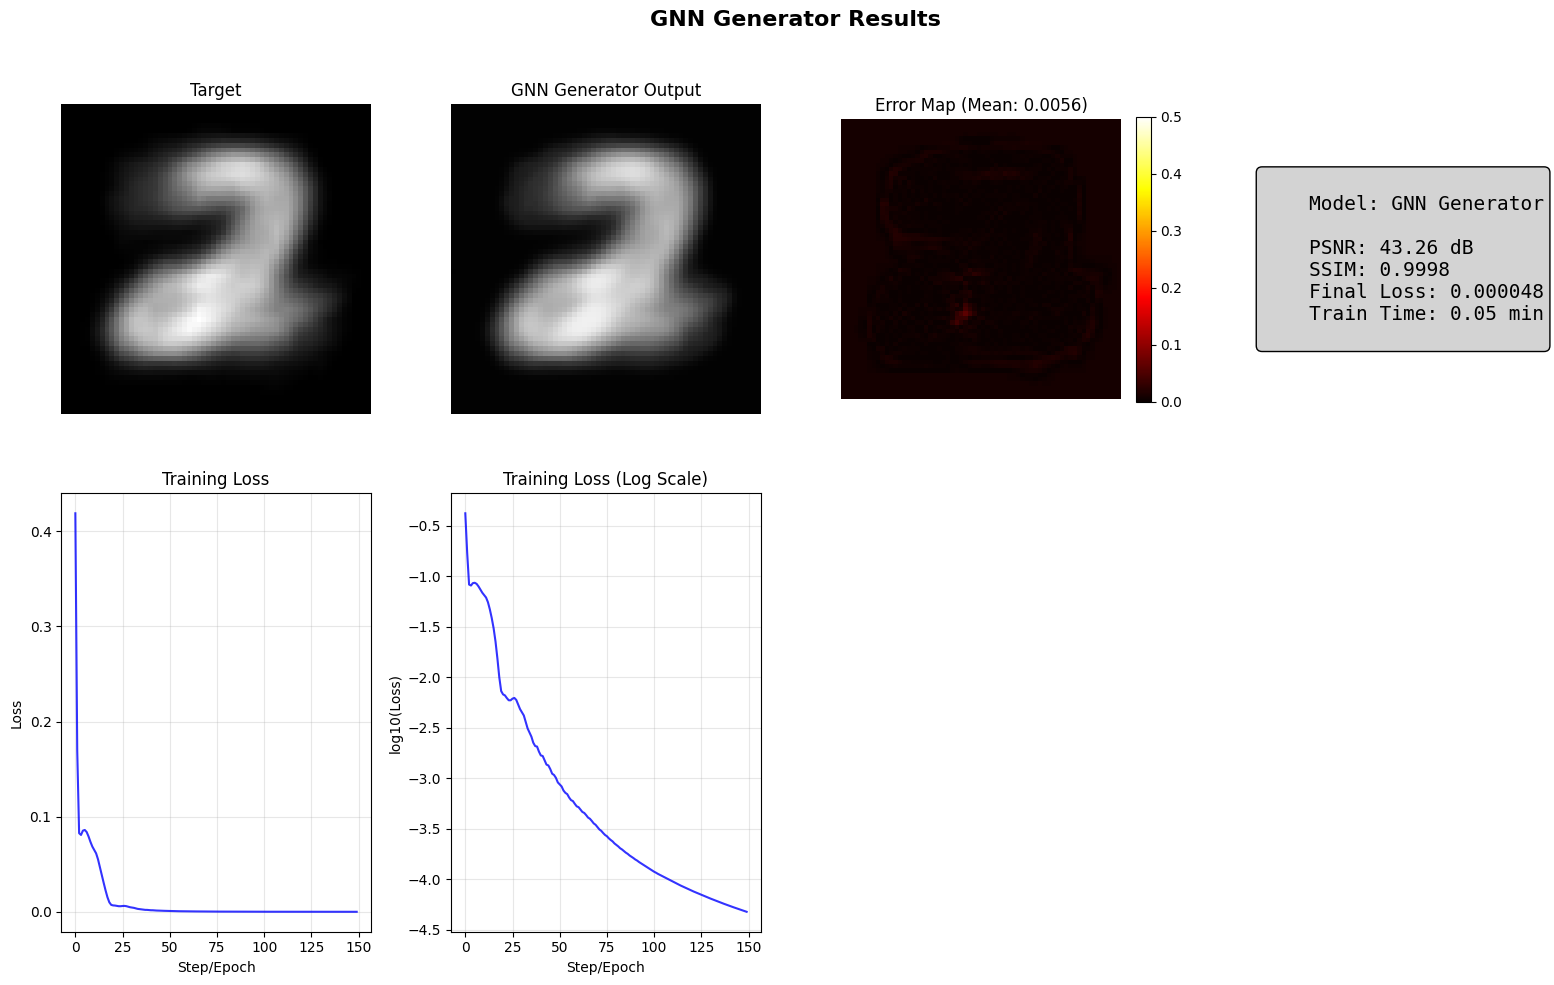

In [10]:
"""
Block 4: GNN Generator Training
Run Block 1 first!
"""

# ==============================================================================
# GRAPH CONV LAYER
# ==============================================================================
class GraphConvLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
    
    def forward(self, x, adj):
        agg = torch.bmm(adj, x)
        return self.linear(agg)

# ==============================================================================
# GNN GENERATOR MODEL
# ==============================================================================
class GNNGenerator(nn.Module):
    def __init__(self, hidden_dim: int = 128, img_size: int = 64, num_layers: int = 6):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.img_size = img_size
        self.num_nodes = img_size * img_size
        
        self.init_embed = nn.Parameter(torch.randn(1, self.num_nodes, hidden_dim) * 0.01)
        
        self.layers = nn.ModuleList([
            GraphConvLayer(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])
        
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        self._adj = None
    
    def get_adj(self, device):
        if self._adj is None or self._adj.device != device:
            H = W = self.img_size
            N = H * W
            adj = torch.zeros(N, N, device=device)
            
            for i in range(H):
                for j in range(W):
                    idx = i * W + j
                    if j < W - 1:
                        adj[idx, idx + 1] = 1
                        adj[idx + 1, idx] = 1
                    if i < H - 1:
                        adj[idx, idx + W] = 1
                        adj[idx + W, idx] = 1
            
            degree = adj.sum(dim=1, keepdim=True).clamp(min=1)
            adj = adj / degree
            self._adj = adj.unsqueeze(0)
        return self._adj
    
    def forward(self, batch_size=1):
        device = self.init_embed.device
        adj = self.get_adj(device).expand(batch_size, -1, -1)
        x = self.init_embed.expand(batch_size, -1, -1)
        
        for layer, norm in zip(self.layers, self.norms):
            x = x + F.relu(norm(layer(x, adj)))
        
        out = self.output(x)
        return out.view(batch_size, 1, self.img_size, self.img_size)

# ==============================================================================
# TRAINING
# ==============================================================================
def train_gnn(epochs: int = 150, lr: float = 1e-3, hidden_dim: int = 128):
    print("\n" + "="*60)
    print("Training: GNN Generator")
    print("="*60)
    
    reset_memory_stats()
    device = cfg.device
    target = TARGET.to(device)
    
    model = GNNGenerator(hidden_dim=hidden_dim, img_size=cfg.img_size).to(device)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
    
    loss_history = []
    best_loss = float('inf')
    best_state = None
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        output = model(batch_size=1)
        loss = F.mse_loss(output, target.unsqueeze(0))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        scheduler.step(loss)
        
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        if loss_val < best_loss:
            best_loss = loss_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if epoch % 15 == 0:
            print(f"\rEpoch {epoch:4d}/{epochs} | Loss: {loss_val:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}", end='')
    
    train_time = time.time() - start_time
    peak_memory = get_memory_usage()
    
    # Evaluation
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_output = model(batch_size=1)[0]
    
    psnr = compute_psnr(final_output.cpu(), target.cpu())
    ssim = compute_ssim(final_output.cpu(), target.cpu())
    error_map = compute_error_map(final_output.cpu(), target.cpu())
    
    print(f"\n\nFinal Loss: {best_loss:.6f}")
    print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")
    print(f"Training Time: {train_time/60:.2f} min | Peak Memory: {peak_memory:.2f} MB")
    
    # Plot
    plot_results('GNN Generator', target.cpu(), final_output.cpu(), error_map,
                 loss_history, psnr, ssim, train_time)
    
    # Save
    torch.save(best_state, os.path.join(cfg.save_dir, 'gnn_best.pth'))
    
    return {
        'model_name': 'GNN Generator',
        'final_loss': best_loss,
        'psnr': psnr,
        'ssim': ssim,
        'train_time': train_time,
        'peak_memory': peak_memory,
        'loss_history': loss_history,
        'final_output': final_output.cpu(),
        'parameters': sum(p.numel() for p in model.parameters())
    }

# Run training
gnn_results = train_gnn(epochs=150, lr=1e-3, hidden_dim=128)


Training: GAN (Generator + Discriminator)
Generator Parameters: 3,598,657
Discriminator Parameters: 2,764,481
Epoch 2970/3000 | G: 0.4406 | D: 1.1295 | Recon: 0.0007549

Final Loss: 0.000391
PSNR: 34.08 dB | SSIM: 0.9984
Training Time: 0.51 min | Peak Memory: 2492.54 MB


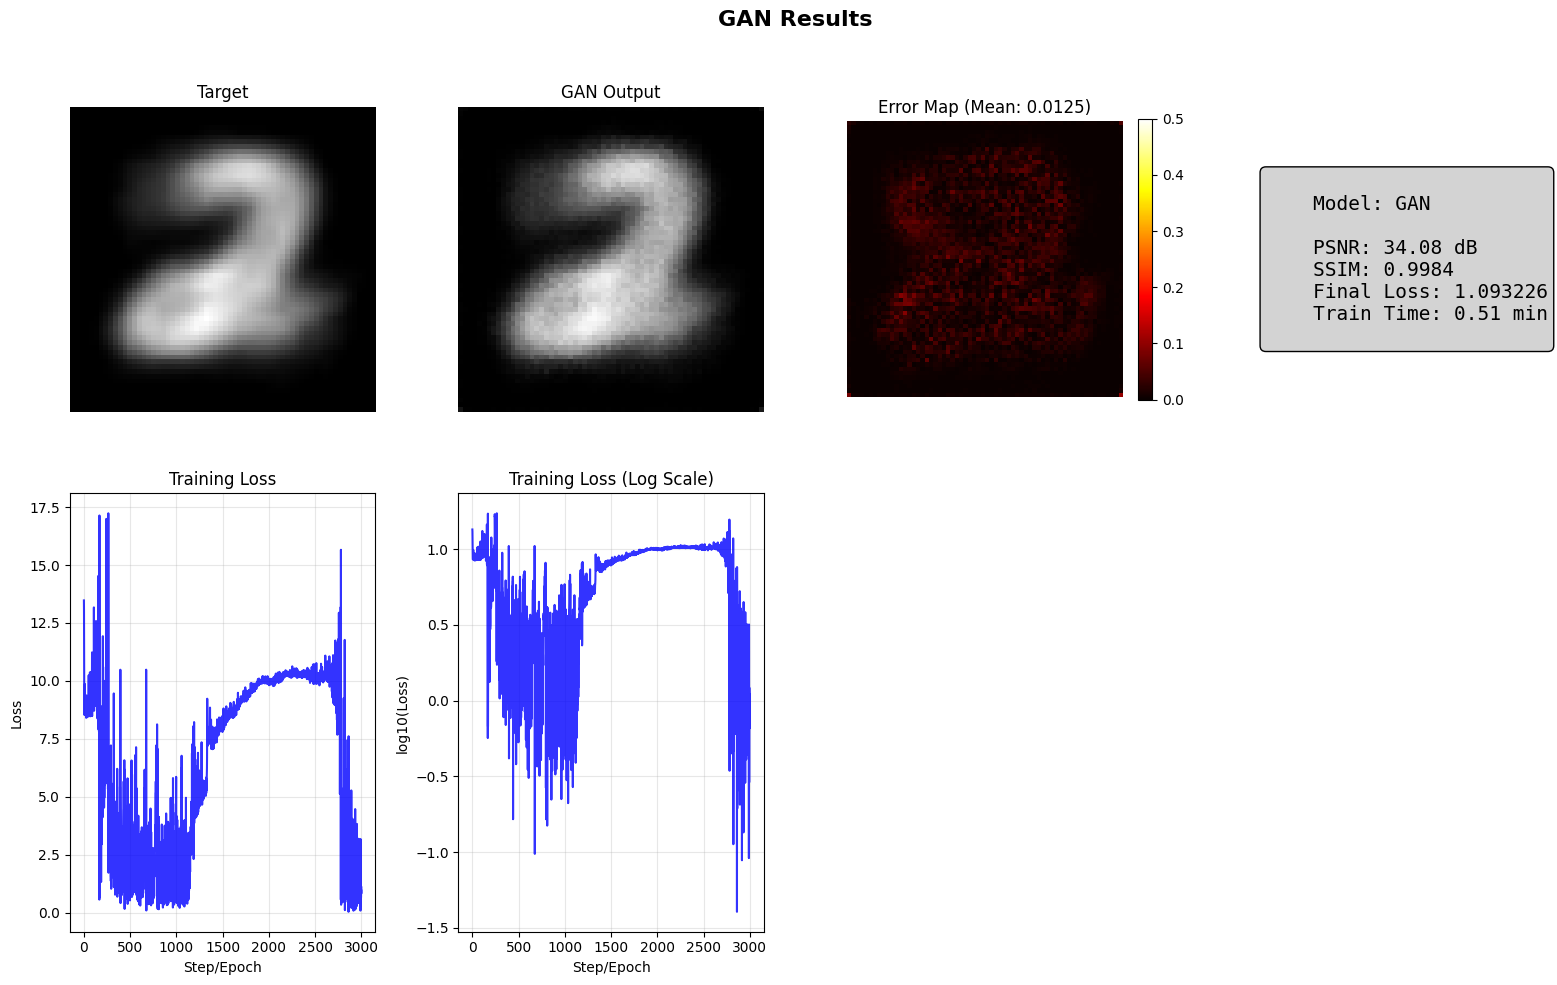

In [11]:
"""
Block 6: GAN Training
Run Block 1 first!
"""

# ==============================================================================
# GAN MODELS
# ==============================================================================
class GANGenerator(nn.Module):
    def __init__(self, latent_dim: int = 100, img_size: int = 64):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size = img_size
        self.init_size = img_size // 16
        
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * self.init_size ** 2),
            nn.LayerNorm(512 * self.init_size ** 2),  # LayerNorm instead of BatchNorm for batch=1
            nn.ReLU(inplace=True)
        )
        
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.shape[0], 512, self.init_size, self.init_size)
        x = self.conv(x)
        return (x + 1) / 2


class GANDiscriminator(nn.Module):
    def __init__(self, img_size: int = 64):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        ds_size = img_size // 16
        self.fc = nn.Sequential(
            nn.Linear(512 * ds_size ** 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        features = self.conv(x)
        features = features.view(features.shape[0], -1)
        return self.fc(features)

# ==============================================================================
# TRAINING
# ==============================================================================
def train_gan(epochs: int = 300, lr_g: float = 2e-4, lr_d: float = 2e-4, latent_dim: int = 100):
    print("\n" + "="*60)
    print("Training: GAN (Generator + Discriminator)")
    print("="*60)
    
    reset_memory_stats()
    device = cfg.device
    target = TARGET.to(device).unsqueeze(0)
    
    generator = GANGenerator(latent_dim=latent_dim, img_size=cfg.img_size).to(device)
    discriminator = GANDiscriminator(img_size=cfg.img_size).to(device)
    
    print(f"Generator Parameters: {sum(p.numel() for p in generator.parameters()):,}")
    print(f"Discriminator Parameters: {sum(p.numel() for p in discriminator.parameters()):,}")
    
    fixed_z = torch.randn(1, latent_dim, device=device)
    
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    
    criterion = nn.BCELoss()
    
    loss_history_g = []
    loss_history_d = []
    best_loss = float('inf')
    best_state_g = None
    
    start_time = time.time()
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        real_label = torch.ones(1, 1, device=device)
        fake_label = torch.zeros(1, 1, device=device)
        
        # Train Discriminator
        opt_d.zero_grad()
        real_output = discriminator(target)
        loss_d_real = criterion(real_output, real_label)
        
        z = torch.randn(1, latent_dim, device=device)
        fake = generator(z)
        fake_output = discriminator(fake.detach())
        loss_d_fake = criterion(fake_output, fake_label)
        
        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        opt_d.step()
        
        # Train Generator
        opt_g.zero_grad()
        fake_output = discriminator(fake)
        loss_g_adv = criterion(fake_output, real_label)
        loss_g_recon = F.mse_loss(fake, target) * 10.0
        loss_g = loss_g_adv + loss_g_recon
        loss_g.backward()
        opt_g.step()
        
        loss_history_g.append(loss_g.item())
        loss_history_d.append(loss_d.item())
        
        # Track best
        generator.eval()
        with torch.no_grad():
            eval_output = generator(fixed_z)
            eval_loss = F.mse_loss(eval_output, target).item()
        
        if eval_loss < best_loss:
            best_loss = eval_loss
            best_state_g = {k: v.cpu().clone() for k, v in generator.state_dict().items()}
        
        if epoch % 30 == 0:
            print(f"\rEpoch {epoch:4d}/{epochs} | G: {loss_g.item():.4f} | D: {loss_d.item():.4f} | Recon: {eval_loss:.6f}", end='')
    
    train_time = time.time() - start_time
    peak_memory = get_memory_usage()
    
    # Evaluation
    generator.load_state_dict(best_state_g)
    generator.eval()
    with torch.no_grad():
        final_output = generator(fixed_z)[0]
    
    psnr = compute_psnr(final_output.cpu(), target[0].cpu())
    ssim = compute_ssim(final_output.cpu(), target[0].cpu())
    error_map = compute_error_map(final_output.cpu(), target[0].cpu())
    
    print(f"\n\nFinal Loss: {best_loss:.6f}")
    print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")
    print(f"Training Time: {train_time/60:.2f} min | Peak Memory: {peak_memory:.2f} MB")
    
    # Plot
    plot_results('GAN', target[0].cpu(), final_output.cpu(), error_map,
                 loss_history_g, psnr, ssim, train_time)
    
    # Save
    torch.save(best_state_g, os.path.join(cfg.save_dir, 'gan_best.pth'))
    
    return {
        'model_name': 'GAN',
        'final_loss': best_loss,
        'psnr': psnr,
        'ssim': ssim,
        'train_time': train_time,
        'peak_memory': peak_memory,
        'loss_history': loss_history_g,
        'final_output': final_output.cpu(),
        'parameters': sum(p.numel() for p in generator.parameters())
    }

# Run training
gan_results = train_gan(epochs=3000, lr_g=2e-4, lr_d=2e-4, latent_dim=100)


Training: Graph NCA (Fixed for Grayscale)
Parameters: 16,928
Config: channels=16, hidden=128, fire_rate=0.5, dx_clip=0.25
Training: 10000 steps, batch=8, inner_steps=48-96
Loss: MSE + Perceptual (weight=0.5)
Step 10000/10000 | Loss: 0.000145 | log10: -3.838 | LR: 2.00e-04

Generating temporal evolution...
Generating GIF...
Saved GIF: ./nca_comparison_results/graph_nca_growth.gif

Training Complete!
Final Loss: 0.000086
PSNR: 29.60 dB | SSIM: 0.9960
Training Time: 47.45 min | Peak Memory: 3797.14 MB


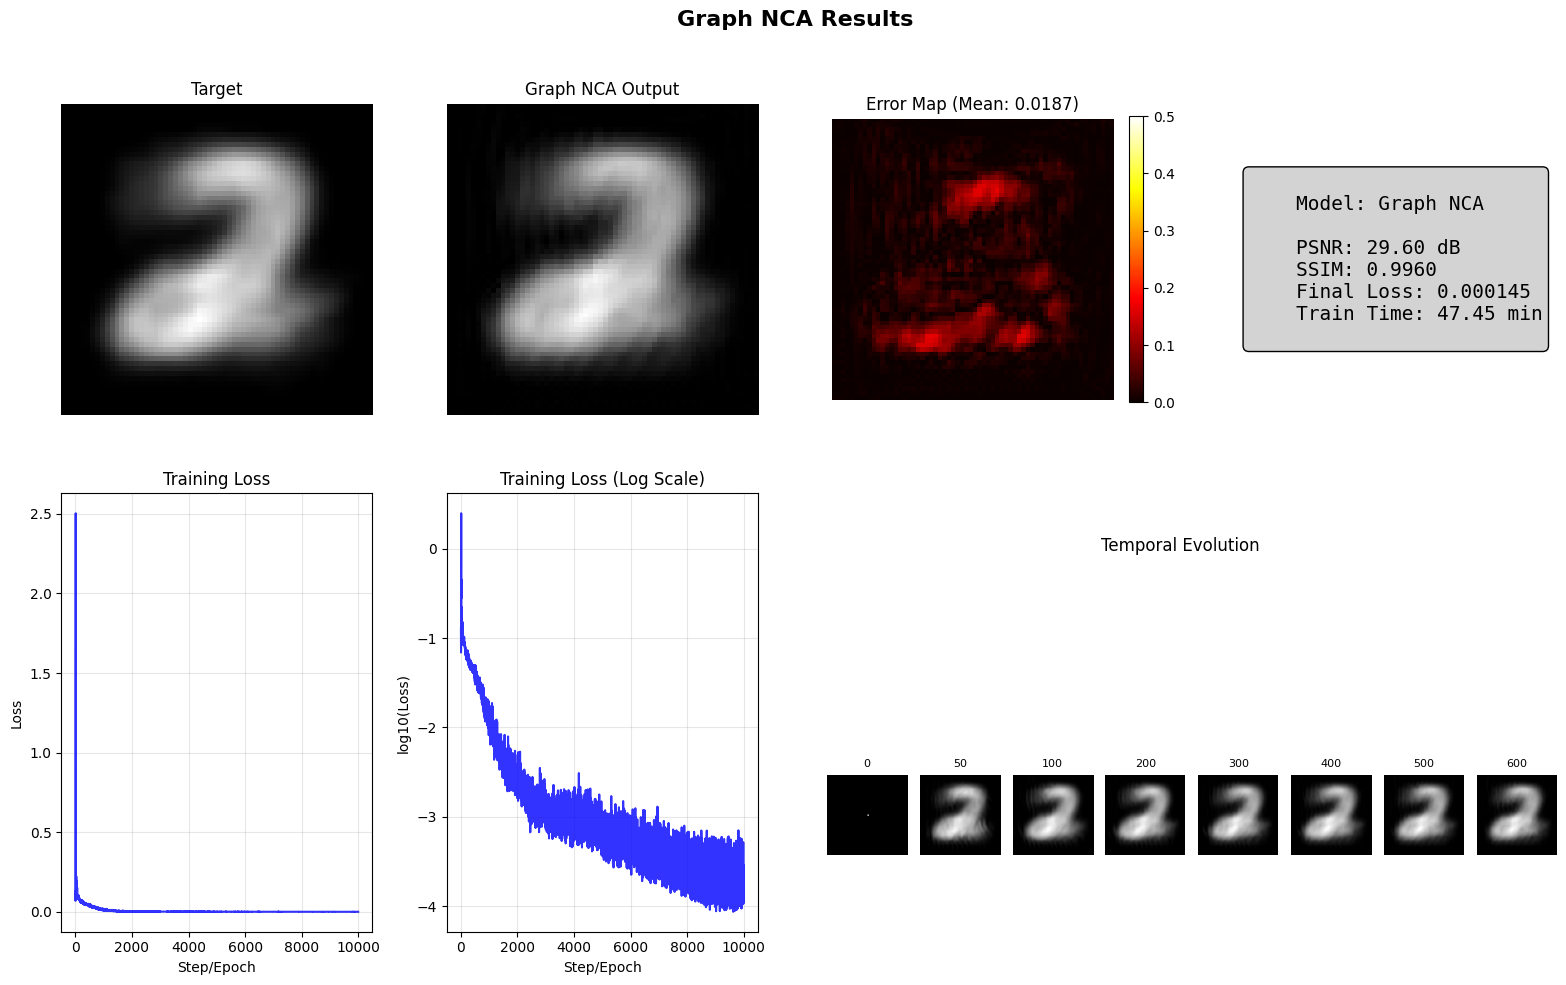

Model saved to ./nca_comparison_results/graph_nca_best.pth

✅ Graph NCA training complete!
   PSNR: 29.60 dB
   SSIM: 0.9960


In [12]:
"""
Block 5: Graph NCA Training (Fixed for Grayscale/MNIST)
========================================================
Fixed issues:
1. Alive masking now works correctly for grayscale (keeps cells alive based on activity, not brightness)
2. Loss computed over entire image, not just bright regions
3. Proper grayscale handling throughout

Run Block 1 first!
"""

# ==============================================================================
# GRAPH NCA MODEL (Fixed for Grayscale)
# ==============================================================================
class GraphNCA(nn.Module):
    """
    Graph Neural Cellular Automata using Conv2d operations.
    Fixed for grayscale images (MNIST).
    
    Key fixes:
    - Alive masking based on cell activity (any channel), not just brightness
    - Works across entire grid, not just white/bright regions
    """
    
    def __init__(self, channels: int = 16, hidden_size: int = 128, fire_rate: float = 0.5, 
                 dx_clip: Optional[float] = 0.3, alive_channel: int = None):
        super().__init__()
        self.channels = channels
        self.fire_rate = fire_rate
        self.dx_clip = dx_clip
        # For grayscale: use a dedicated "alive" channel (not the visible channel)
        # We'll use channel index 1 as the alive indicator, channel 0 is visible
        self.alive_channel = alive_channel if alive_channel is not None else min(1, channels - 1)
        
        # Directional attention for 4 neighbors (N, S, W, E)
        self.dir_attn = nn.Conv2d(channels, 4 * channels, 1)
        
        # Message projection
        self.msg_proj = nn.Conv2d(channels, channels, 1)
        
        # Sobel filters for gradient
        self.register_buffer("_sobel_x", torch.tensor([[-1, 0, 1],
                                                        [-2, 0, 2],
                                                        [-1, 0, 1]], dtype=torch.float32) / 8.0)
        self.register_buffer("_sobel_y", torch.tensor([[-1, -2, -1],
                                                        [0,  0,  0],
                                                        [1,  2,  1]], dtype=torch.float32) / 8.0)
        
        # Update network - input is [x, agg, sobel_x, sobel_y] = 4*channels
        # Or [x, agg, sobel] = 3*channels if using single sobel
        self.dmodel = nn.Sequential(
            nn.Conv2d(channels * 3, hidden_size, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_size, hidden_size // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_size // 2, channels, 1)
        )
        
        # Zero init for stable start
        nn.init.zeros_(self.dmodel[-1].weight)
        nn.init.zeros_(self.dmodel[-1].bias)
        
        # Small random init for attention (not zero, to break symmetry)
        nn.init.normal_(self.dir_attn.weight, mean=0, std=0.01)
        nn.init.zeros_(self.dir_attn.bias)
    
    def shift(self, x: torch.Tensor, direction: str) -> torch.Tensor:
        """Shift tensor to access neighbor values."""
        if direction == 'N':
            return F.pad(x, (0, 0, 1, 0))[:, :, :-1, :]
        if direction == 'S':
            return F.pad(x, (0, 0, 0, 1))[:, :, 1:, :]
        if direction == 'W':
            return F.pad(x, (1, 0, 0, 0))[:, :, :, :-1]
        if direction == 'E':
            return F.pad(x, (0, 1, 0, 0))[:, :, :, 1:]
        return x
    
    def perceive(self, x: torch.Tensor) -> torch.Tensor:
        """Perceive neighborhood using directional attention + Sobel gradient."""
        b, c, h, w = x.shape
        
        # Get shifted neighbors
        n = self.shift(x, 'N')
        s = self.shift(x, 'S')
        wv = self.shift(x, 'W')
        e = self.shift(x, 'E')
        
        # Stack and project messages
        msgs = torch.stack([n, s, wv, e], dim=1).view(b * 4, c, h, w)
        msgs = self.msg_proj(msgs).view(b, 4, c, h, w)
        
        # Attention weights
        logits = self.dir_attn(x).view(b, 4, c, h, w)
        attn = F.softmax(logits, dim=1)
        
        # Weighted aggregation
        agg = (attn * msgs).sum(dim=1)
        
        # Sobel gradient (using x direction only for simplicity)
        sobel_kernel = self._sobel_x.to(x.device).view(1, 1, 3, 3).repeat(c, 1, 1, 1)
        sobel = F.conv2d(x, sobel_kernel, padding=1, groups=c)
        
        return torch.cat([x, agg, sobel], dim=1)
    
    def get_alive_mask(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute alive mask based on cell ACTIVITY, not brightness.
        
        For grayscale MNIST:
        - We can't use "pixel > threshold" because dark pixels are the digit!
        - Instead, use the maximum absolute value across hidden channels
        - Or use a dedicated alive channel that tracks cell activity
        
        A cell is alive if:
        1. It has any significant activity in hidden channels, OR
        2. Any of its neighbors have activity (allows growth)
        """
        # Use max absolute value across ALL channels as activity indicator
        # This works for both bright and dark targets
        activity = torch.max(torch.abs(x), dim=1, keepdim=True)[0]
        
        # A cell is alive if it or its neighbors have activity
        alive = F.max_pool2d(activity, kernel_size=3, stride=1, padding=1) > 0.01
        
        return alive.float()
    
    def update(self, x: torch.Tensor, perception: torch.Tensor, fire_rate: Optional[float] = None) -> torch.Tensor:
        """Apply update with proper alive masking for grayscale."""
        # Compute update
        dx = self.dmodel(perception)
        
        # Clip for stability
        if self.dx_clip is not None:
            dx = dx.clamp(-self.dx_clip, self.dx_clip)
        
        fr = self.fire_rate if fire_rate is None else fire_rate
        
        # Stochastic update
        if self.training:
            mask = (torch.rand(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) <= fr).float()
            x = x + dx * mask
        else:
            x = x + dx
        
        # Alive masking - use activity-based mask
        alive = self.get_alive_mask(x)
        
        return x * alive
    
    def forward(self, x: torch.Tensor, fire_rate: Optional[float] = None) -> torch.Tensor:
        """Single GraphNCA step."""
        y = self.perceive(x)
        return self.update(x, y, fire_rate)


# ==============================================================================
# SAMPLE POOL
# ==============================================================================
class GraphNCAPool:
    """Sample pool for GraphNCA training."""
    
    def __init__(self, size: int, channels: int, img_size: int, device: torch.device):
        self.size = size
        self.channels = channels
        self.img_size = img_size
        self.device = device
        self.pool = self._make_seeds(size, channels, img_size, device)
    
    def _make_seeds(self, n: int, channels: int, img_size: int, device: torch.device) -> torch.Tensor:
        """Create seed states with single active pixel in center."""
        seed = torch.zeros(n, channels, img_size, img_size, device=device)
        center = img_size // 2
        # Initialize ALL channels at center to 1.0 (strong seed signal)
        seed[:, :, center, center] = 1.0
        return seed
    
    def sample(self, n: int) -> Tuple[torch.Tensor, np.ndarray]:
        idx = np.random.choice(self.size, n, replace=False)
        return self.pool[idx].clone(), idx
    
    def commit(self, idx: np.ndarray, states: torch.Tensor):
        self.pool[idx] = states.detach()


# ==============================================================================
# LOSS FUNCTIONS (Fixed for Grayscale)
# ==============================================================================
def compute_nca_loss(pred: torch.Tensor, target: torch.Tensor, 
                     x_full: torch.Tensor = None, 
                     loss_type: str = 'mse') -> torch.Tensor:
    """
    Compute loss for NCA training.
    
    For grayscale MNIST, we compute loss over the ENTIRE image,
    not just masked regions, because both dark and light pixels matter.
    
    Args:
        pred: Predicted visible channel [B, 1, H, W]
        target: Target image [B, 1, H, W]
        x_full: Full state (optional, for regularization)
        loss_type: 'mse', 'l1', or 'huber'
    """
    if loss_type == 'mse':
        loss = F.mse_loss(pred, target)
    elif loss_type == 'l1':
        loss = F.l1_loss(pred, target)
    elif loss_type == 'huber':
        loss = F.smooth_l1_loss(pred, target)
    else:
        loss = F.mse_loss(pred, target)
    
    # Optional: Add small regularization on hidden channels to prevent explosion
    if x_full is not None:
        hidden_reg = 0.0001 * torch.mean(x_full[:, 1:] ** 2)
        loss = loss + hidden_reg
    
    return loss


def compute_perceptual_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Simple perceptual loss using gradient matching.
    Helps preserve edges in the reconstruction.
    """
    # Sobel kernels
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], 
                           dtype=torch.float32, device=pred.device).view(1, 1, 3, 3) / 4.0
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], 
                           dtype=torch.float32, device=pred.device).view(1, 1, 3, 3) / 4.0
    
    # Compute gradients
    pred_gx = F.conv2d(pred, sobel_x, padding=1)
    pred_gy = F.conv2d(pred, sobel_y, padding=1)
    target_gx = F.conv2d(target, sobel_x, padding=1)
    target_gy = F.conv2d(target, sobel_y, padding=1)
    
    # Gradient loss
    loss = F.mse_loss(pred_gx, target_gx) + F.mse_loss(pred_gy, target_gy)
    
    return loss


# ==============================================================================
# TRAINING FUNCTION (Fixed for Grayscale)
# ==============================================================================
def train_graph_nca(
    train_steps: int = 10000,
    channels: int = 16,
    hidden_size: int = 128,
    fire_rate: float = 0.5,
    lr: float = 2e-3,
    lr_decay_step: int = 4000,
    batch_size: int = 8,
    pool_size: int = 512,
    min_steps: int = 48,
    max_steps: int = 96,
    eval_steps: int = 600,
    dx_clip: float = 0.25,
    use_perceptual_loss: bool = True,
    perceptual_weight: float = 0.5
):
    """
    Train Graph NCA - Fixed for grayscale images.
    
    Key fixes:
    - Loss computed over entire image (no masking)
    - Alive masking based on activity, not brightness
    - Optional perceptual loss for better edge preservation
    """
    print("\n" + "="*60)
    print("Training: Graph NCA (Fixed for Grayscale)")
    print("="*60)
    
    # Clear memory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    
    device = cfg.device
    target = TARGET.to(device)
    
    # Create model
    model = GraphNCA(
        channels=channels,
        hidden_size=hidden_size,
        fire_rate=fire_rate,
        dx_clip=dx_clip
    ).to(device)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {num_params:,}")
    print(f"Config: channels={channels}, hidden={hidden_size}, fire_rate={fire_rate}, dx_clip={dx_clip}")
    print(f"Training: {train_steps} steps, batch={batch_size}, inner_steps={min_steps}-{max_steps}")
    print(f"Loss: MSE + Perceptual (weight={perceptual_weight})" if use_perceptual_loss else "Loss: MSE only")
    
    # Expand target to match channels (channel 0 = visible grayscale)
    target_full = torch.zeros(1, channels, cfg.img_size, cfg.img_size, device=device)
    target_full[:, :1] = target.unsqueeze(0)
    
    # Optimizer with cosine annealing
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    def lr_lambda(step):
        if step < lr_decay_step:
            return 1.0
        else:
            progress = (step - lr_decay_step) / (train_steps - lr_decay_step + 1)
            return max(0.1, 0.5 * (1 + np.cos(np.pi * progress)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Mixed precision
    use_amp = cfg.mixed_precision and torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    # Sample pool
    pool = GraphNCAPool(pool_size, channels, cfg.img_size, device)
    seed = pool._make_seeds(1, channels, cfg.img_size, device)
    
    # Training tracking
    loss_history = []
    best_loss = float('inf')
    best_state = None
    temporal_frames = []
    temporal_steps = [0, 50, 100, 200, 300, 400, 500, 600]
    
    start_time = time.time()
    
    for step in range(train_steps + 1):
        model.train()
        
        # Sample from pool
        batch_x, pool_idx = pool.sample(batch_size)
        batch_x[0:1] = seed.clone()
        
        # Random inner steps
        n_steps = np.random.randint(min_steps, max_steps)
        
        # Forward pass
        with torch.amp.autocast('cuda', enabled=use_amp):
            x = batch_x
            for _ in range(n_steps):
                x = model(x)
            
            # Loss on visible channel (entire image, no masking!)
            pred = x[:, :1]
            tgt = target_full[:, :1].expand(batch_size, -1, -1, -1)
            
            # MSE loss over entire image
            mse_loss = F.mse_loss(pred, tgt)
            
            # Optional perceptual loss
            if use_perceptual_loss:
                perc_loss = compute_perceptual_loss(pred, tgt)
                loss = mse_loss + perceptual_weight * perc_loss
            else:
                loss = mse_loss
        
        # Backward
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        # Update pool
        pool.commit(pool_idx, x)
        
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        # Track best
        if loss_val < best_loss:
            best_loss = loss_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        # Logging
        if step % 100 == 0:
            log10_loss = np.log10(loss_val + 1e-10)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"\rStep {step:5d}/{train_steps} | Loss: {loss_val:.6f} | log10: {log10_loss:.3f} | LR: {current_lr:.2e}", end='')
            
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    train_time = time.time() - start_time
    peak_memory = get_memory_usage()
    
    # Load best
    model.load_state_dict(best_state)
    model.eval()
    
    # Generate temporal evolution
    print("\n\nGenerating temporal evolution...")
    with torch.no_grad():
        x = seed.clone()
        for s in range(eval_steps + 1):
            if s in temporal_steps:
                temporal_frames.append(x[0, :1].cpu().clone())
            x = model(x, fire_rate=1.0)
        final_output = x[0, :1]
    
    # GIF
    print("Generating GIF...")
    gif_frames = []
    with torch.no_grad():
        x = seed.clone()
        num_gif_frames = int(cfg.gif_fps * cfg.gif_duration_sec)
        steps_per_frame = max(1, eval_steps // num_gif_frames)
        
        for s in range(eval_steps):
            x = model(x, fire_rate=1.0)
            if s % steps_per_frame == 0:
                gif_frames.append(x[0, :1].cpu().clone())
    
    save_gif(gif_frames, os.path.join(cfg.save_dir, 'graph_nca_growth.gif'), fps=cfg.gif_fps)
    
    # Metrics
    psnr = compute_psnr(final_output.cpu(), target.cpu())
    ssim = compute_ssim(final_output.cpu(), target.cpu())
    error_map = compute_error_map(final_output.cpu(), target.cpu())
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"{'='*60}")
    print(f"Final Loss: {best_loss:.6f}")
    print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")
    print(f"Training Time: {train_time/60:.2f} min | Peak Memory: {peak_memory:.2f} MB")
    
    # Plot
    plot_results(
        'Graph NCA',
        target.cpu(),
        final_output.cpu(),
        error_map,
        loss_history,
        psnr,
        ssim,
        train_time,
        temporal_frames,
        temporal_steps[:len(temporal_frames)]
    )
    
    # Save
    torch.save(best_state, os.path.join(cfg.save_dir, 'graph_nca_best.pth'))
    print(f"Model saved to {os.path.join(cfg.save_dir, 'graph_nca_best.pth')}")
    
    return {
        'model_name': 'Graph NCA',
        'final_loss': best_loss,
        'psnr': psnr,
        'ssim': ssim,
        'train_time': train_time,
        'peak_memory': peak_memory,
        'loss_history': loss_history,
        'final_output': final_output.cpu(),
        'error_map': error_map,
        'temporal_frames': temporal_frames,
        'temporal_steps': temporal_steps[:len(temporal_frames)],
        'gif_frames': gif_frames,
        'best_state': best_state,
        'parameters': num_params
    }


# ==============================================================================
# RUN TRAINING
# ==============================================================================
gnca_results = train_graph_nca(
    train_steps=10000,       # More steps for better convergence
    channels=16,
    hidden_size=128,
    fire_rate=0.5,
    lr=2e-3,
    lr_decay_step=4000,
    batch_size=8,
    pool_size=512,
    min_steps=48,            # More inner steps
    max_steps=96,
    eval_steps=600,
    dx_clip=0.25,            # Slightly tighter clipping
    use_perceptual_loss=True,  # Edge-preserving loss
    perceptual_weight=0.5
)

print("\n✅ Graph NCA training complete!")
print(f"   PSNR: {gnca_results['psnr']:.2f} dB")
print(f"   SSIM: {gnca_results['ssim']:.4f}")

In [13]:
"""
NCA Resolution Scaling: 64x64 → 512x512
========================================
Test trained NCA models at higher resolutions.

NCAs learn LOCAL rules, so they should work at any resolution!
"""

import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import imageio
from typing import List, Dict, Optional
import time

# ==============================================================================
# CONFIGURATION
# ==============================================================================
RESOLUTIONS = [64, 128, 256, 512]  # Resolutions to test
EVAL_STEPS_PER_RESOLUTION = {
    64: 600,
    128: 800,
    256: 1200,
    512: 2000  # More steps needed for larger images
}
GIF_FPS = 30
SAVE_DIR = os.path.join(cfg.save_dir, "resolution_scaling")
os.makedirs(SAVE_DIR, exist_ok=True)

device = cfg.device
print(f"Device: {device}")
print(f"Resolutions to test: {RESOLUTIONS}")

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def create_seed(channels: int, img_size: int, device: torch.device) -> torch.Tensor:
    """Create a seed with single active pixel in center."""
    seed = torch.zeros(1, channels, img_size, img_size, device=device)
    center = img_size // 2
    seed[:, :, center, center] = 1.0
    return seed

def create_seed_scaled(channels: int, img_size: int, device: torch.device, 
                       seed_size: int = 3) -> torch.Tensor:
    """
    Create a seed with a small active region in center.
    For larger images, a single pixel seed might be too small.
    """
    seed = torch.zeros(1, channels, img_size, img_size, device=device)
    center = img_size // 2
    half = seed_size // 2
    seed[:, :, center-half:center+half+1, center-half:center+half+1] = 1.0
    return seed

def upscale_target(target: torch.Tensor, new_size: int) -> torch.Tensor:
    """Upscale target image to new resolution using bilinear interpolation."""
    if target.dim() == 2:
        target = target.unsqueeze(0).unsqueeze(0)
    elif target.dim() == 3:
        target = target.unsqueeze(0)
    
    upscaled = F.interpolate(target, size=(new_size, new_size), mode='bilinear', align_corners=False)
    return upscaled.squeeze()

def run_nca_at_resolution(model, channels: int, img_size: int, num_steps: int,
                          device: torch.device, seed_size: int = 1) -> Dict:
    """
    Run NCA at a specific resolution.
    
    Returns:
        Dictionary with frames, final output, and timing info
    """
    model.eval()
    
    # Create seed (scale seed size with resolution)
    if seed_size == 'auto':
        seed_size = max(1, img_size // 64)  # Scale with resolution
    
    if seed_size > 1:
        seed = create_seed_scaled(channels, img_size, device, seed_size)
    else:
        seed = create_seed(channels, img_size, device)
    
    frames = []
    frame_interval = max(1, num_steps // 100)  # Save ~100 frames
    
    start_time = time.time()
    
    with torch.no_grad():
        x = seed.clone()
        for step in range(num_steps + 1):
            if step % frame_interval == 0:
                frames.append(x[0, :1].cpu().clone())
            x = model(x, fire_rate=1.0)
        
        final_output = x[0, :1].cpu()
    
    elapsed_time = time.time() - start_time
    
    return {
        'frames': frames,
        'final_output': final_output,
        'seed': seed[0, :1].cpu(),
        'elapsed_time': elapsed_time,
        'num_steps': num_steps,
        'resolution': img_size
    }

def save_resolution_gif(frames: List[torch.Tensor], save_path: str, fps: int = 30):
    """Save frames as GIF."""
    imgs = []
    for frame in frames:
        img = frame.squeeze().numpy()
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        imgs.append(img)
    
    imageio.mimsave(save_path, imgs, duration=1000//fps, loop=0)
    print(f"  ✓ Saved GIF: {save_path}")

def plot_resolution_comparison(results: Dict[int, Dict], model_name: str, 
                               target_original: torch.Tensor, save_dir: str):
    """Plot comparison of NCA outputs at different resolutions."""
    
    resolutions = sorted(results.keys())
    n_res = len(resolutions)
    
    fig, axes = plt.subplots(3, n_res, figsize=(5*n_res, 15))
    
    for i, res in enumerate(resolutions):
        result = results[res]
        
        # Row 1: Final outputs
        ax = axes[0, i]
        output = result['final_output'].squeeze().numpy()
        ax.imshow(output, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{res}x{res}\n({result["num_steps"]} steps)', fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # Row 2: Upscaled target for comparison
        ax = axes[1, i]
        target_upscaled = upscale_target(target_original, res).numpy()
        ax.imshow(target_upscaled, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Target (upscaled)', fontsize=12)
        ax.axis('off')
        
        # Row 3: Error map
        ax = axes[2, i]
        error = np.abs(output - target_upscaled)
        im = ax.imshow(error, cmap='hot', vmin=0, vmax=0.5)
        psnr = compute_psnr(
            torch.tensor(output).unsqueeze(0), 
            torch.tensor(target_upscaled).unsqueeze(0)
        )
        ax.set_title(f'Error (PSNR: {psnr:.2f} dB)', fontsize=12)
        ax.axis('off')
    
    # Add row labels
    axes[0, 0].text(-0.15, 0.5, 'NCA Output', transform=axes[0, 0].transAxes,
                    fontsize=14, fontweight='bold', va='center', rotation=90)
    axes[1, 0].text(-0.15, 0.5, 'Target', transform=axes[1, 0].transAxes,
                    fontsize=14, fontweight='bold', va='center', rotation=90)
    axes[2, 0].text(-0.15, 0.5, 'Error Map', transform=axes[2, 0].transAxes,
                    fontsize=14, fontweight='bold', va='center', rotation=90)
    
    plt.suptitle(f'{model_name} - Resolution Scaling Test', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_resolution_comparison.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Saved: {save_path}")

def plot_temporal_evolution_multirez(results: Dict[int, Dict], model_name: str, save_dir: str):
    """Plot temporal evolution at each resolution."""
    
    resolutions = sorted(results.keys())
    
    for res in resolutions:
        result = results[res]
        frames = result['frames']
        
        # Select frames to show
        n_show = min(10, len(frames))
        indices = np.linspace(0, len(frames)-1, n_show, dtype=int)
        
        fig, axes = plt.subplots(1, n_show, figsize=(2.5*n_show, 3))
        
        for i, idx in enumerate(indices):
            frame = frames[idx].squeeze().numpy()
            axes[i].imshow(frame, cmap='gray', vmin=0, vmax=1)
            step = idx * (result['num_steps'] // len(frames))
            axes[i].set_title(f'Step {step}', fontsize=10)
            axes[i].axis('off')
        
        plt.suptitle(f'{model_name} at {res}x{res} - Temporal Evolution', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_{res}x{res}_evolution.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"  ✓ Saved: {save_path}")

def plot_metrics_vs_resolution(all_results: Dict[str, Dict[int, Dict]], 
                               target_original: torch.Tensor, save_dir: str):
    """Plot metrics across resolutions for all models."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    colors = {'Canonical NCA': '#3498DB', 'Graph NCA': '#9B59B6'}
    
    for model_name, results in all_results.items():
        resolutions = sorted(results.keys())
        color = colors.get(model_name, '#333333')
        
        psnr_values = []
        ssim_values = []
        times = []
        
        for res in resolutions:
            output = results[res]['final_output']
            target_up = upscale_target(target_original, res)
            
            psnr = compute_psnr(output.unsqueeze(0), target_up.unsqueeze(0))
            ssim = compute_ssim(output.unsqueeze(0), target_up.unsqueeze(0))
            
            psnr_values.append(psnr)
            ssim_values.append(ssim)
            times.append(results[res]['elapsed_time'])
        
        # PSNR vs Resolution
        ax = axes[0, 0]
        ax.plot(resolutions, psnr_values, 'o-', color=color, linewidth=2, 
                markersize=10, label=model_name)
        ax.set_xlabel('Resolution', fontsize=12)
        ax.set_ylabel('PSNR (dB)', fontsize=12)
        ax.set_title('PSNR vs Resolution', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # SSIM vs Resolution
        ax = axes[0, 1]
        ax.plot(resolutions, ssim_values, 'o-', color=color, linewidth=2,
                markersize=10, label=model_name)
        ax.set_xlabel('Resolution', fontsize=12)
        ax.set_ylabel('SSIM', fontsize=12)
        ax.set_title('SSIM vs Resolution', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Time vs Resolution
        ax = axes[1, 0]
        ax.plot(resolutions, times, 'o-', color=color, linewidth=2,
                markersize=10, label=model_name)
        ax.set_xlabel('Resolution', fontsize=12)
        ax.set_ylabel('Time (seconds)', fontsize=12)
        ax.set_title('Generation Time vs Resolution', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Steps vs Resolution
        ax = axes[1, 1]
        steps = [results[res]['num_steps'] for res in resolutions]
        ax.plot(resolutions, steps, 'o-', color=color, linewidth=2,
                markersize=10, label=model_name)
        ax.set_xlabel('Resolution', fontsize=12)
        ax.set_ylabel('Number of Steps', fontsize=12)
        ax.set_title('Steps Required vs Resolution', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('NCA Resolution Scaling Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'resolution_scaling_metrics.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Saved: {save_path}")

# ==============================================================================
# MAIN: RUN RESOLUTION SCALING TESTS
# ==============================================================================
print("\n" + "="*70)
print(" NCA RESOLUTION SCALING TEST ")
print("="*70)

all_model_results = {}

# ------------------------------------------------------------------------------
# TEST CANONICAL NCA
# ------------------------------------------------------------------------------
if nca_results is not None:
    print("\n" + "-"*50)
    print("Testing: Canonical NCA")
    print("-"*50)
    
    # Load model
    state_dict = nca_results['best_state']
    channels = state_dict['perception.weight'].shape[1] if 'perception.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    canonical_nca = CanonicalNCA(
        channels=channels,
        hidden_size=hidden_size,
        fire_rate=0.5
    ).to(device)
    canonical_nca.load_state_dict(state_dict)
    canonical_nca.eval()
    
    print(f"  Model loaded: channels={channels}, hidden={hidden_size}")
    
    canonical_results = {}
    
    for res in RESOLUTIONS:
        print(f"\n  Resolution: {res}x{res}")
        num_steps = EVAL_STEPS_PER_RESOLUTION.get(res, 1000)
        
        # Scale seed size with resolution
        seed_size = max(1, res // 64)
        print(f"    Steps: {num_steps}, Seed size: {seed_size}x{seed_size}")
        
        result = run_nca_at_resolution(
            canonical_nca, channels, res, num_steps, device, seed_size
        )
        canonical_results[res] = result
        
        print(f"    ✓ Done in {result['elapsed_time']:.2f}s")
        
        # Save GIF
        gif_path = os.path.join(SAVE_DIR, f'canonical_nca_{res}x{res}_growth.gif')
        save_resolution_gif(result['frames'], gif_path, fps=GIF_FPS)
    
    all_model_results['Canonical NCA'] = canonical_results
    
    # Plot comparisons
    print("\n  Generating plots...")
    plot_resolution_comparison(canonical_results, 'Canonical NCA', TARGET.cpu(), SAVE_DIR)
    plot_temporal_evolution_multirez(canonical_results, 'Canonical NCA', SAVE_DIR)

# ------------------------------------------------------------------------------
# TEST GRAPH NCA
# ------------------------------------------------------------------------------
if gnca_results is not None:
    print("\n" + "-"*50)
    print("Testing: Graph NCA")
    print("-"*50)
    
    # Load model
    state_dict = gnca_results['best_state']
    channels = state_dict['dir_attn.weight'].shape[1] if 'dir_attn.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    graph_nca = GraphNCA(
        channels=channels,
        hidden_size=hidden_size,
        fire_rate=0.5,
        dx_clip=0.25
    ).to(device)
    graph_nca.load_state_dict(state_dict)
    graph_nca.eval()
    
    print(f"  Model loaded: channels={channels}, hidden={hidden_size}")
    
    graph_results = {}
    
    for res in RESOLUTIONS:
        print(f"\n  Resolution: {res}x{res}")
        num_steps = EVAL_STEPS_PER_RESOLUTION.get(res, 1000)
        
        seed_size = max(1, res // 64)
        print(f"    Steps: {num_steps}, Seed size: {seed_size}x{seed_size}")
        
        result = run_nca_at_resolution(
            graph_nca, channels, res, num_steps, device, seed_size
        )
        graph_results[res] = result
        
        print(f"    ✓ Done in {result['elapsed_time']:.2f}s")
        
        # Save GIF
        gif_path = os.path.join(SAVE_DIR, f'graph_nca_{res}x{res}_growth.gif')
        save_resolution_gif(result['frames'], gif_path, fps=GIF_FPS)
    
    all_model_results['Graph NCA'] = graph_results
    
    # Plot comparisons
    print("\n  Generating plots...")
    plot_resolution_comparison(graph_results, 'Graph NCA', TARGET.cpu(), SAVE_DIR)
    plot_temporal_evolution_multirez(graph_results, 'Graph NCA', SAVE_DIR)

# ------------------------------------------------------------------------------
# COMBINED ANALYSIS
# ------------------------------------------------------------------------------
print("\n" + "-"*50)
print("Generating Combined Analysis...")
print("-"*50)

if all_model_results:
    plot_metrics_vs_resolution(all_model_results, TARGET.cpu(), SAVE_DIR)

# ------------------------------------------------------------------------------
# SAVE FINAL HIGH-RES OUTPUTS
# ------------------------------------------------------------------------------
print("\n" + "-"*50)
print("Saving High-Resolution Outputs...")
print("-"*50)

for model_name, results in all_model_results.items():
    for res, result in results.items():
        output = result['final_output'].squeeze().numpy()
        output_uint8 = (np.clip(output, 0, 1) * 255).astype(np.uint8)
        
        # Save as PNG
        save_path = os.path.join(SAVE_DIR, f'{model_name.lower().replace(" ", "_")}_{res}x{res}_output.png')
        plt.imsave(save_path, output_uint8, cmap='gray')
        print(f"  ✓ Saved: {save_path}")

# ------------------------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------------------------
print("\n" + "="*70)
print(" RESOLUTION SCALING SUMMARY ")
print("="*70)

for model_name, results in all_model_results.items():
    print(f"\n{model_name}:")
    print(f"  {'Resolution':<12} {'PSNR (dB)':<12} {'SSIM':<12} {'Time (s)':<12}")
    print(f"  {'-'*48}")
    
    for res in sorted(results.keys()):
        output = results[res]['final_output']
        target_up = upscale_target(TARGET.cpu(), res)
        
        psnr = compute_psnr(output.unsqueeze(0), target_up.unsqueeze(0))
        ssim = compute_ssim(output.unsqueeze(0), target_up.unsqueeze(0))
        time_elapsed = results[res]['elapsed_time']
        
        print(f"  {res}x{res:<8} {psnr:<12.2f} {ssim:<12.4f} {time_elapsed:<12.2f}")

print(f"\n📁 All results saved to: {SAVE_DIR}")
print("\n✅ Resolution scaling test complete!")

Device: cuda
Resolutions to test: [64, 128, 256, 512]

 NCA RESOLUTION SCALING TEST 

--------------------------------------------------
Testing: Canonical NCA
--------------------------------------------------
  Model loaded: channels=16, hidden=128

  Resolution: 64x64
    Steps: 600, Seed size: 1x1
    ✓ Done in 0.21s
  ✓ Saved GIF: ./nca_comparison_results/resolution_scaling/canonical_nca_64x64_growth.gif

  Resolution: 128x128
    Steps: 800, Seed size: 2x2
    ✓ Done in 0.47s
  ✓ Saved GIF: ./nca_comparison_results/resolution_scaling/canonical_nca_128x128_growth.gif

  Resolution: 256x256
    Steps: 1200, Seed size: 4x4
    ✓ Done in 2.50s
  ✓ Saved GIF: ./nca_comparison_results/resolution_scaling/canonical_nca_256x256_growth.gif

  Resolution: 512x512
    Steps: 2000, Seed size: 8x8
    ✓ Done in 15.59s
  ✓ Saved GIF: ./nca_comparison_results/resolution_scaling/canonical_nca_512x512_growth.gif

  Generating plots...
  ✓ Saved: ./nca_comparison_results/resolution_scaling/canonica

In [14]:
"""
All Models Resolution Scaling: 64x64 → 512x512
===============================================
Compare NCAs (native scaling) vs CNN/GAN/GNN (upscaling or retraining)

Approach:
- NCAs: Run at any resolution (they're resolution-independent!)
- CNN/GAN/GNN: Upscale outputs OR retrain at target resolution
"""

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import imageio
from typing import Dict, List, Tuple
import time
import gc

# ==============================================================================
# CONFIGURATION
# ==============================================================================
RESOLUTIONS = [64, 128, 256, 512]
SAVE_DIR = os.path.join(cfg.save_dir, "resolution_scaling_all_models")
os.makedirs(SAVE_DIR, exist_ok=True)

device = cfg.device
print(f"Device: {device}")
print(f"Testing resolutions: {RESOLUTIONS}")

# ==============================================================================
# APPROACH 1: UPSCALE EXISTING OUTPUTS (Quick Comparison)
# ==============================================================================
print("\n" + "="*70)
print(" APPROACH 1: UPSCALE EXISTING OUTPUTS ")
print("="*70)
print("This upscales the 64x64 outputs to higher resolutions.")
print("NCAs regenerate natively; CNN/GAN/GNN use interpolation.")

def upscale_output(output: torch.Tensor, target_size: int, method: str = 'bilinear') -> torch.Tensor:
    """Upscale output to target size."""
    if output.dim() == 2:
        output = output.unsqueeze(0).unsqueeze(0)
    elif output.dim() == 3:
        output = output.unsqueeze(0)
    
    upscaled = F.interpolate(output, size=(target_size, target_size), 
                             mode=method, align_corners=False if method != 'nearest' else None)
    return upscaled.squeeze()

def upscale_target(target: torch.Tensor, new_size: int) -> torch.Tensor:
    """Upscale target image."""
    if target.dim() == 2:
        target = target.unsqueeze(0).unsqueeze(0)
    elif target.dim() == 3:
        target = target.unsqueeze(0)
    
    upscaled = F.interpolate(target, size=(new_size, new_size), mode='bilinear', align_corners=False)
    return upscaled.squeeze()

# Store all results
upscale_results = {}

# Get all model outputs at 64x64
model_outputs_64 = {
    'CNN': cnn_results['final_output'] if cnn_results else None,
    'GNN': gnn_results['final_output'] if gnn_results else None,
    'GAN': gan_results['final_output'] if gan_results else None,
    'Canonical NCA': nca_results['final_output'] if nca_results else None,
    'Graph NCA': gnca_results['final_output'] if gnca_results else None,
}

# Remove None entries
model_outputs_64 = {k: v for k, v in model_outputs_64.items() if v is not None}

print(f"\nModels available: {list(model_outputs_64.keys())}")

# Upscale all non-NCA models
print("\n--- Upscaling Non-NCA Models ---")
for model_name, output in model_outputs_64.items():
    if 'NCA' not in model_name:  # Skip NCAs (they'll regenerate natively)
        upscale_results[model_name] = {}
        for res in RESOLUTIONS:
            upscaled = upscale_output(output, res, method='bicubic')
            upscale_results[model_name][res] = {
                'output': upscaled,
                'method': 'bicubic_upscale',
                'native': False
            }
        print(f"  ✓ {model_name}: Upscaled to all resolutions")

# ==============================================================================
# NCA NATIVE REGENERATION AT EACH RESOLUTION
# ==============================================================================
print("\n--- NCA Native Regeneration ---")

NCA_STEPS = {64: 600, 128: 800, 256: 1200, 512: 2000}

def run_nca_native(model, channels: int, img_size: int, num_steps: int, 
                   device: torch.device) -> torch.Tensor:
    """Run NCA natively at target resolution."""
    model.eval()
    
    # Create seed (scale size with resolution)
    seed_size = max(1, img_size // 64)
    seed = torch.zeros(1, channels, img_size, img_size, device=device)
    center = img_size // 2
    half = seed_size // 2
    seed[:, :, center-half:center+half+1, center-half:center+half+1] = 1.0
    
    with torch.no_grad():
        x = seed
        for _ in range(num_steps):
            x = model(x, fire_rate=1.0)
    
    return x[0, :1].cpu()

# Canonical NCA
if nca_results is not None:
    print("  Running Canonical NCA at all resolutions...")
    state_dict = nca_results['best_state']
    channels = state_dict['perception.weight'].shape[1] if 'perception.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    canonical_nca = CanonicalNCA(channels=channels, hidden_size=hidden_size, fire_rate=0.5).to(device)
    canonical_nca.load_state_dict(state_dict)
    
    upscale_results['Canonical NCA'] = {}
    for res in RESOLUTIONS:
        print(f"    {res}x{res}...", end=' ')
        start = time.time()
        output = run_nca_native(canonical_nca, channels, res, NCA_STEPS[res], device)
        elapsed = time.time() - start
        upscale_results['Canonical NCA'][res] = {
            'output': output,
            'method': 'native',
            'native': True,
            'time': elapsed
        }
        print(f"Done ({elapsed:.1f}s)")
    
    del canonical_nca
    torch.cuda.empty_cache()

# Graph NCA
if gnca_results is not None:
    print("  Running Graph NCA at all resolutions...")
    state_dict = gnca_results['best_state']
    channels = state_dict['dir_attn.weight'].shape[1] if 'dir_attn.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    graph_nca = GraphNCA(channels=channels, hidden_size=hidden_size, fire_rate=0.5, dx_clip=0.25).to(device)
    graph_nca.load_state_dict(state_dict)
    
    upscale_results['Graph NCA'] = {}
    for res in RESOLUTIONS:
        print(f"    {res}x{res}...", end=' ')
        start = time.time()
        output = run_nca_native(graph_nca, channels, res, NCA_STEPS[res], device)
        elapsed = time.time() - start
        upscale_results['Graph NCA'][res] = {
            'output': output,
            'method': 'native',
            'native': True,
            'time': elapsed
        }
        print(f"Done ({elapsed:.1f}s)")
    
    del graph_nca
    torch.cuda.empty_cache()

# ==============================================================================
# COMPUTE METRICS FOR ALL
# ==============================================================================
print("\n--- Computing Metrics ---")

metrics_table = {}
target_cpu = TARGET.cpu()

for model_name, res_results in upscale_results.items():
    metrics_table[model_name] = {}
    for res, data in res_results.items():
        output = data['output']
        target_up = upscale_target(target_cpu, res)
        
        psnr = compute_psnr(output.unsqueeze(0), target_up.unsqueeze(0))
        ssim = compute_ssim(output.unsqueeze(0), target_up.unsqueeze(0))
        
        metrics_table[model_name][res] = {
            'psnr': psnr,
            'ssim': ssim,
            'native': data['native'],
            'method': data['method']
        }

print("  ✓ Metrics computed")

# ==============================================================================
# VISUALIZATION: COMPARISON GRID
# ==============================================================================
print("\n--- Generating Comparison Plots ---")

def plot_all_models_resolution_grid(upscale_results: Dict, target: torch.Tensor, save_dir: str):
    """Plot all models at all resolutions in a grid."""
    
    models = list(upscale_results.keys())
    resolutions = RESOLUTIONS
    
    n_models = len(models)
    n_res = len(resolutions)
    
    fig, axes = plt.subplots(n_models + 1, n_res, figsize=(4*n_res, 4*(n_models+1)))
    
    # Row 0: Targets at each resolution
    for j, res in enumerate(resolutions):
        target_up = upscale_target(target, res).numpy()
        axes[0, j].imshow(target_up, cmap='gray', vmin=0, vmax=1)
        axes[0, j].set_title(f'Target {res}x{res}', fontsize=12, fontweight='bold')
        axes[0, j].axis('off')
    
    # Rows 1+: Each model
    for i, model_name in enumerate(models):
        for j, res in enumerate(resolutions):
            output = upscale_results[model_name][res]['output'].squeeze().numpy()
            psnr = metrics_table[model_name][res]['psnr']
            is_native = upscale_results[model_name][res]['native']
            
            axes[i+1, j].imshow(output, cmap='gray', vmin=0, vmax=1)
            
            # Title with method indicator
            method_str = "Native" if is_native else "Upscaled"
            axes[i+1, j].set_title(f'{psnr:.1f} dB\n({method_str})', fontsize=10)
            axes[i+1, j].axis('off')
        
        # Model name on the left
        axes[i+1, 0].text(-0.15, 0.5, model_name, transform=axes[i+1, 0].transAxes,
                         fontsize=12, fontweight='bold', va='center', rotation=90)
    
    plt.suptitle('All Models - Resolution Scaling Comparison\n(Native = regenerated at resolution, Upscaled = bicubic interpolation)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'all_models_resolution_grid.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Saved: {save_path}")

def plot_psnr_comparison(metrics_table: Dict, save_dir: str):
    """Plot PSNR comparison across resolutions."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {
        'CNN': '#E74C3C',
        'GNN': '#2ECC71', 
        'GAN': '#F39C12',
        'Canonical NCA': '#3498DB',
        'Graph NCA': '#9B59B6'
    }
    
    markers = {
        'CNN': 's',
        'GNN': '^',
        'GAN': 'd',
        'Canonical NCA': 'o',
        'Graph NCA': 'p'
    }
    
    # PSNR plot
    ax = axes[0]
    for model_name, res_metrics in metrics_table.items():
        resolutions = sorted(res_metrics.keys())
        psnr_values = [res_metrics[r]['psnr'] for r in resolutions]
        is_native = res_metrics[resolutions[0]]['native']
        
        linestyle = '-' if is_native else '--'
        label = f"{model_name} ({'Native' if is_native else 'Upscaled'})"
        
        ax.plot(resolutions, psnr_values, 
                marker=markers.get(model_name, 'o'),
                color=colors.get(model_name, '#333'),
                linestyle=linestyle,
                linewidth=2, markersize=10, label=label)
    
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('PSNR (dB)', fontsize=12)
    ax.set_title('PSNR vs Resolution', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(RESOLUTIONS)
    ax.set_xticklabels([f'{r}x{r}' for r in RESOLUTIONS])
    
    # SSIM plot
    ax = axes[1]
    for model_name, res_metrics in metrics_table.items():
        resolutions = sorted(res_metrics.keys())
        ssim_values = [res_metrics[r]['ssim'] for r in resolutions]
        is_native = res_metrics[resolutions[0]]['native']
        
        linestyle = '-' if is_native else '--'
        label = f"{model_name} ({'Native' if is_native else 'Upscaled'})"
        
        ax.plot(resolutions, ssim_values,
                marker=markers.get(model_name, 'o'),
                color=colors.get(model_name, '#333'),
                linestyle=linestyle,
                linewidth=2, markersize=10, label=label)
    
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('SSIM', fontsize=12)
    ax.set_title('SSIM vs Resolution', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(RESOLUTIONS)
    ax.set_xticklabels([f'{r}x{r}' for r in RESOLUTIONS])
    
    plt.suptitle('Resolution Scaling: Native NCA vs Upscaled CNN/GAN/GNN', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'resolution_metrics_comparison.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Saved: {save_path}")

def plot_native_vs_upscaled_bar(metrics_table: Dict, save_dir: str):
    """Bar chart comparing native NCA vs upscaled methods at each resolution."""
    
    resolutions = RESOLUTIONS
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    for idx, res in enumerate(resolutions):
        ax = axes[idx // 2, idx % 2]
        
        models = list(metrics_table.keys())
        psnr_values = [metrics_table[m][res]['psnr'] for m in models]
        native_flags = [metrics_table[m][res]['native'] for m in models]
        
        colors = ['#3498DB' if native else '#E74C3C' for native in native_flags]
        
        bars = ax.bar(range(len(models)), psnr_values, color=colors, edgecolor='black', linewidth=1.5)
        
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=10)
        ax.set_ylabel('PSNR (dB)', fontsize=11)
        ax.set_title(f'{res}x{res} Resolution', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, psnr_values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498DB', edgecolor='black', label='Native (NCA)'),
        Patch(facecolor='#E74C3C', edgecolor='black', label='Upscaled (CNN/GAN/GNN)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12,
               bbox_to_anchor=(0.5, 0.02))
    
    plt.suptitle('PSNR at Each Resolution: Native NCA vs Upscaled Models', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    
    save_path = os.path.join(save_dir, 'native_vs_upscaled_bars.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Saved: {save_path}")

# Generate all plots
plot_all_models_resolution_grid(upscale_results, target_cpu, SAVE_DIR)
plot_psnr_comparison(metrics_table, SAVE_DIR)
plot_native_vs_upscaled_bar(metrics_table, SAVE_DIR)

# ==============================================================================
# APPROACH 2: RETRAIN AT HIGHER RESOLUTION (Fair Comparison)
# ==============================================================================
print("\n" + "="*70)
print(" APPROACH 2: RETRAIN CNN AT HIGHER RESOLUTION ")
print("="*70)
print("This retrains models at target resolution for fair comparison.")
print("(Only doing 256x256 as example - takes time)")

RETRAIN_RESOLUTION = 256
RETRAIN_EPOCHS = 50  # Fewer epochs for demo

def get_target_at_resolution(resolution: int) -> torch.Tensor:
    """Get target image at specified resolution."""
    # Load MNIST and resize
    from torchvision import datasets, transforms
    
    transform = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
    ])
    
    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    
    # Get digit 2 images
    digit_images = []
    for img, label in dataset:
        if label == cfg.target_digit:
            digit_images.append(img)
            if len(digit_images) >= 100:
                break
    
    # Mean image
    target = torch.stack(digit_images).mean(dim=0)
    target = (target - target.min()) / (target.max() - target.min() + 1e-8)
    
    return target.squeeze()

# Get high-res target
print(f"\nLoading {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION} target...")
target_highres = get_target_at_resolution(RETRAIN_RESOLUTION).to(device)
print(f"  ✓ Target shape: {target_highres.shape}")

# Save high-res target
plt.imsave(os.path.join(SAVE_DIR, f'target_{RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}.png'),
           target_highres.cpu().numpy(), cmap='gray')

# ==============================================================================
# RETRAIN CNN AT HIGH RESOLUTION
# ==============================================================================
print(f"\n--- Retraining CNN at {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION} ---")

class CNNGeneratorHighRes(nn.Module):
    """CNN Generator for higher resolutions."""
    
    def __init__(self, latent_dim: int = 128, img_size: int = 256):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size = img_size
        
        # Calculate initial size (img_size / 32)
        self.init_size = img_size // 32
        self.fc = nn.Linear(latent_dim, 512 * self.init_size ** 2)
        
        # 5 upsampling blocks: init_size -> 2x -> 4x -> 8x -> 16x -> 32x
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(512),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 16, 3, 1, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(16, 1, 3, 1, 1),
            nn.Sigmoid()
        )
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z)
        x = x.view(x.shape[0], 512, self.init_size, self.init_size)
        return self.conv_blocks(x)

# Train CNN at high resolution
cnn_highres = CNNGeneratorHighRes(latent_dim=128, img_size=RETRAIN_RESOLUTION).to(device)
latent_highres = nn.Parameter(torch.randn(1, 128, device=device))

optimizer = torch.optim.Adam(list(cnn_highres.parameters()) + [latent_highres], lr=1e-3)

print(f"  Training for {RETRAIN_EPOCHS} epochs...")
cnn_highres.train()
for epoch in range(RETRAIN_EPOCHS):
    output = cnn_highres(latent_highres)
    loss = F.mse_loss(output, target_highres.unsqueeze(0).unsqueeze(0))
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"\r    Epoch {epoch}/{RETRAIN_EPOCHS} | Loss: {loss.item():.6f}", end='')

cnn_highres.eval()
with torch.no_grad():
    cnn_highres_output = cnn_highres(latent_highres)[0, 0].cpu()

cnn_highres_psnr = compute_psnr(cnn_highres_output.unsqueeze(0), target_highres.cpu().unsqueeze(0))
print(f"\n  ✓ CNN retrained at {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}: PSNR = {cnn_highres_psnr:.2f} dB")

# ==============================================================================
# COMPARE: RETRAINED vs UPSCALED vs NATIVE NCA
# ==============================================================================
print(f"\n--- Comparison at {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION} ---")

comparison_256 = {
    'CNN (Retrained)': {
        'output': cnn_highres_output,
        'psnr': cnn_highres_psnr,
        'method': 'retrained'
    },
    'CNN (Upscaled)': {
        'output': upscale_results['CNN'][RETRAIN_RESOLUTION]['output'] if 'CNN' in upscale_results else None,
        'psnr': metrics_table['CNN'][RETRAIN_RESOLUTION]['psnr'] if 'CNN' in metrics_table else 0,
        'method': 'upscaled'
    }
}

# Add NCA results
for nca_name in ['Canonical NCA', 'Graph NCA']:
    if nca_name in upscale_results:
        comparison_256[f'{nca_name} (Native)'] = {
            'output': upscale_results[nca_name][RETRAIN_RESOLUTION]['output'],
            'psnr': metrics_table[nca_name][RETRAIN_RESOLUTION]['psnr'],
            'method': 'native'
        }

# Remove None entries
comparison_256 = {k: v for k, v in comparison_256.items() if v.get('output') is not None}

# Plot comparison
fig, axes = plt.subplots(1, len(comparison_256) + 1, figsize=(5 * (len(comparison_256) + 1), 5))

# Target
axes[0].imshow(target_highres.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Target\n{RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Each method
for i, (name, data) in enumerate(comparison_256.items(), 1):
    axes[i].imshow(data['output'].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"{name}\nPSNR: {data['psnr']:.2f} dB", fontsize=11)
    axes[i].axis('off')

plt.suptitle(f'Fair Comparison at {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}: Retrained vs Upscaled vs Native', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, f'fair_comparison_{RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print(f"  ✓ Saved: {save_path}")

# ==============================================================================
# FINAL SUMMARY TABLE
# ==============================================================================
print("\n" + "="*70)
print(" RESOLUTION SCALING SUMMARY ")
print("="*70)

print("\n📊 APPROACH 1: NCA Native vs Others Upscaled")
print(f"\n{'Model':<20} {'64x64':<12} {'128x128':<12} {'256x256':<12} {'512x512':<12} {'Method':<12}")
print("-" * 80)

for model_name in metrics_table.keys():
    psnr_values = [f"{metrics_table[model_name][r]['psnr']:.1f}" for r in RESOLUTIONS]
    method = 'Native' if metrics_table[model_name][64]['native'] else 'Upscaled'
    print(f"{model_name:<20} {psnr_values[0]:<12} {psnr_values[1]:<12} {psnr_values[2]:<12} {psnr_values[3]:<12} {method:<12}")

print("-" * 80)

print(f"\n📊 APPROACH 2: Fair Comparison at {RETRAIN_RESOLUTION}x{RETRAIN_RESOLUTION}")
print(f"\n{'Method':<30} {'PSNR (dB)':<12}")
print("-" * 45)
for name, data in comparison_256.items():
    print(f"{name:<30} {data['psnr']:<12.2f}")
print("-" * 45)

# ==============================================================================
# KEY INSIGHTS
# ==============================================================================
print("\n" + "="*70)
print(" KEY INSIGHTS ")
print("="*70)
print("""
🔑 NCA Advantages:
   - Resolution-independent: same model works at any size
   - Native generation: no interpolation artifacts
   - Small model size: ~20K params works at all resolutions

⚠️ NCA Challenges:
   - Trained at 64x64, may not perfectly scale details
   - Needs more steps at higher resolutions
   - Pattern may "drift" or become unstable

🔑 CNN/GAN/GNN:
   - Fixed architecture for specific resolution
   - Need to retrain for each target resolution
   - Upscaling introduces blur/artifacts

💡 Best of Both Worlds:
   - Train NCA at higher resolution for better results
   - Or use progressive training: 64 → 128 → 256 → 512
""")

print(f"\n📁 All results saved to: {SAVE_DIR}")
print("\n✅ Resolution scaling comparison complete!")

Device: cuda
Testing resolutions: [64, 128, 256, 512]

 APPROACH 1: UPSCALE EXISTING OUTPUTS 
This upscales the 64x64 outputs to higher resolutions.
NCAs regenerate natively; CNN/GAN/GNN use interpolation.

Models available: ['CNN', 'GNN', 'GAN', 'Canonical NCA', 'Graph NCA']

--- Upscaling Non-NCA Models ---
  ✓ CNN: Upscaled to all resolutions
  ✓ GNN: Upscaled to all resolutions
  ✓ GAN: Upscaled to all resolutions

--- NCA Native Regeneration ---
  Running Canonical NCA at all resolutions...
    64x64... Done (0.2s)
    128x128... Done (0.4s)
    256x256... Done (2.4s)
    512x512... Done (15.4s)
  Running Graph NCA at all resolutions...
    64x64... Done (0.5s)
    128x128... Done (0.7s)
    256x256... Done (4.1s)
    512x512... Done (27.3s)

--- Computing Metrics ---
  ✓ Metrics computed

--- Generating Comparison Plots ---
  ✓ Saved: ./nca_comparison_results/resolution_scaling_all_models/all_models_resolution_grid.png
  ✓ Saved: ./nca_comparison_results/resolution_scaling_all_mo


 STARTING COMPREHENSIVE EVALUATION 

 COMPREHENSIVE MODEL EVALUATION 
✓ CNN results loaded
✓ Canonical NCA results loaded
✓ GNN results loaded
✓ Graph NCA results loaded
✓ GAN results loaded

Models to evaluate: CNN, Canonical NCA, GNN, Graph NCA, GAN
✓ Created evaluation directories in: ./nca_comparison_results/evaluation

------------------------------------------------------------
Setting up NCA models for temporal evaluation...
------------------------------------------------------------
  Canonical NCA: channels=16, hidden_size=128
  ✓ Canonical NCA model recreated and loaded
  Graph NCA: channels=16, hidden_size=128
  ✓ Graph NCA model recreated and loaded
  ✓ Seed created: shape=torch.Size([1, 16, 64, 64])

────────────────────────────────────────────────────────────
Evaluating: CNN
────────────────────────────────────────────────────────────
  Generating plots...
  ✓ Saved: ./nca_comparison_results/evaluation/cnn/cnn_summary.png
  ✓ Saved: ./nca_comparison_results/evaluation/c

IndexError: index 4 is out of bounds for axis 1 with size 4

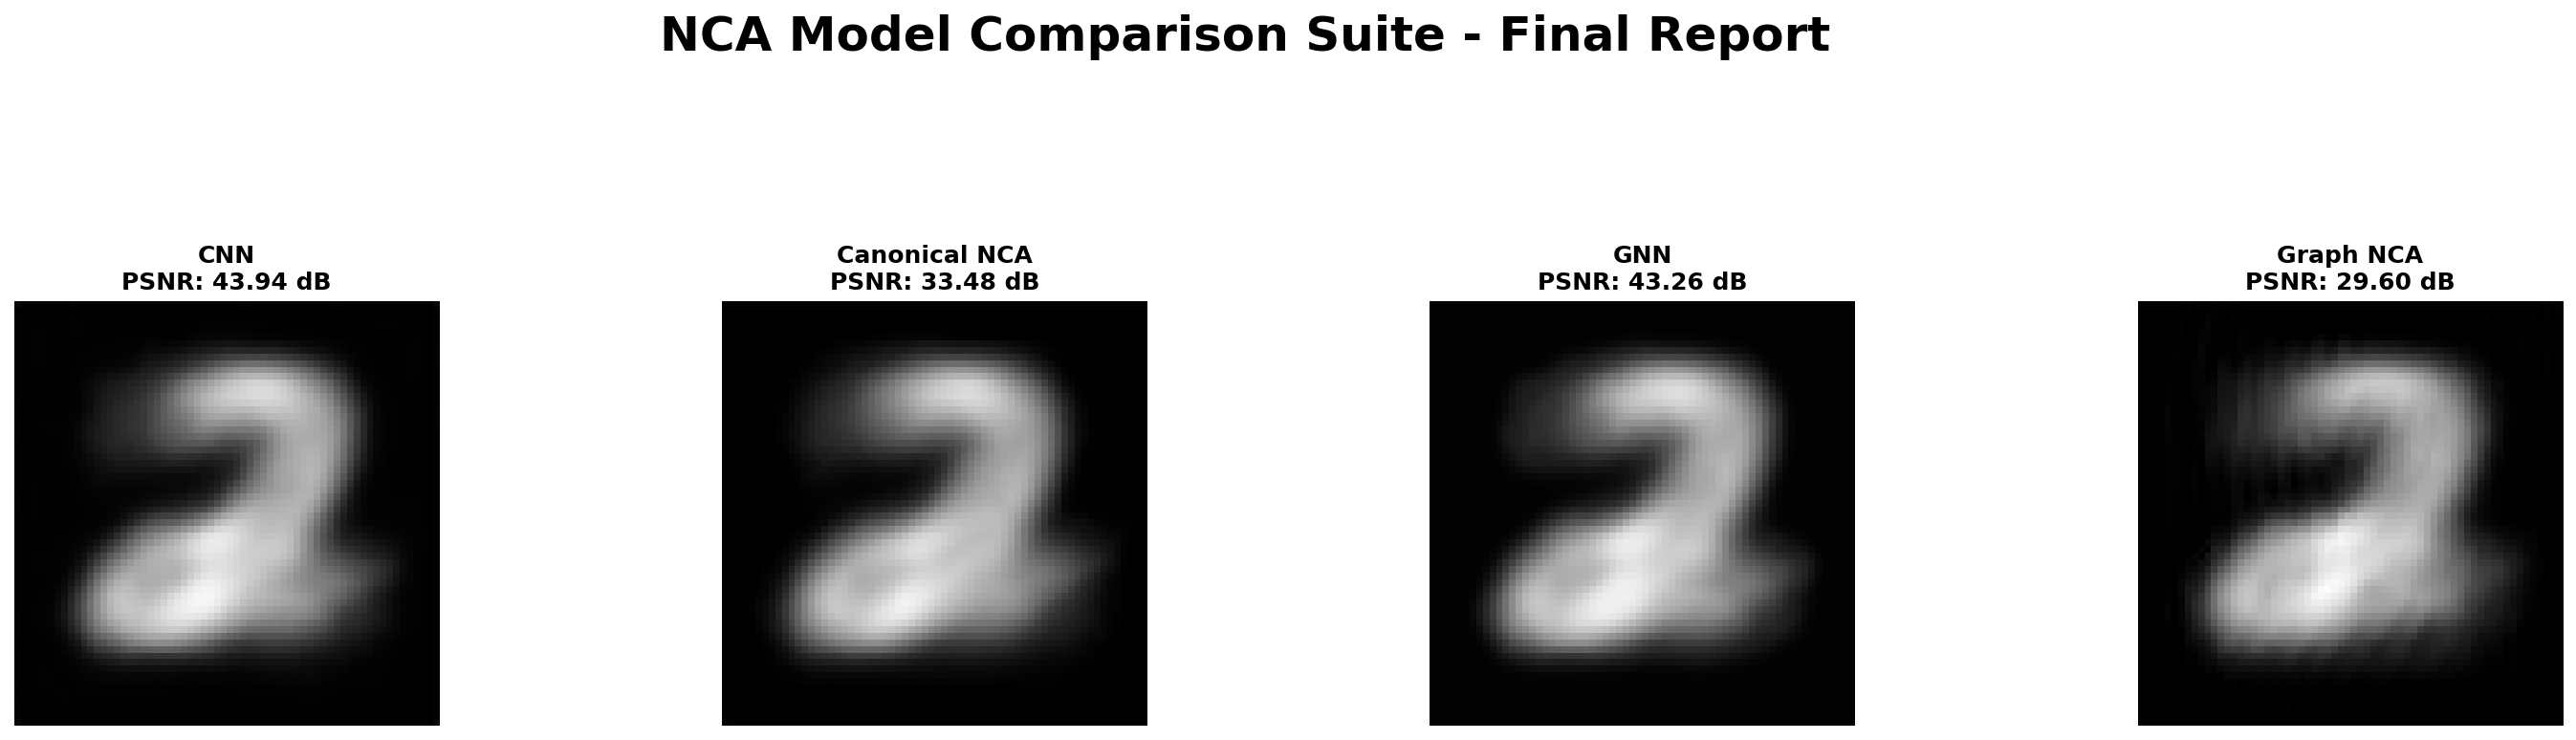

In [15]:
"""
Block 7: Comprehensive Model Evaluation Suite
============================================
Evaluates all models with:
- Common metrics: PSNR, SSIM, Loss, Memory, Accuracy, Precision, Recall, F1, ROC
- NCA-specific: FRE, CSI, Steady State Drift, Temporal Evolution, GIFs
- High-quality visualizations with uniform sizing
- Individual model folders + comparison folder

Run after all training blocks!
Requires: cnn_results, nca_results, gnn_results, gnca_results, gan_results
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, precision_recall_curve
)
from scipy import ndimage
from typing import Dict, List, Tuple, Optional
import torch
import torch.nn.functional as F
import imageio
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIGURATION
# ==============================================================================
class EvalConfig:
    """Evaluation configuration."""
    # Figure settings
    FIG_DPI = 150
    FIG_DPI_HIGH = 300
    FONT_SIZE_TITLE = 16
    FONT_SIZE_SUBTITLE = 14
    FONT_SIZE_LABEL = 12
    FONT_SIZE_TICK = 10
    FONT_SIZE_LEGEND = 10
    
    # Colors
    COLORS = {
        'CNN': '#E74C3C',
        'Canonical NCA': '#3498DB',
        'GNN': '#2ECC71',
        'Graph NCA': '#9B59B6',
        'GAN': '#F39C12'
    }
    
    # NCA evaluation settings
    NCA_EVAL_STEPS = 800
    NCA_STABILITY_WINDOW = 100
    NCA_DRIFT_WINDOW = 50
    
    # Threshold for binary metrics
    BINARY_THRESHOLD = 0.5
    
    # GIF settings
    GIF_FPS = 30
    GIF_DURATION = 10.0

eval_cfg = EvalConfig()

# Set matplotlib defaults
plt.rcParams.update({
    'font.size': eval_cfg.FONT_SIZE_LABEL,
    'axes.titlesize': eval_cfg.FONT_SIZE_SUBTITLE,
    'axes.labelsize': eval_cfg.FONT_SIZE_LABEL,
    'xtick.labelsize': eval_cfg.FONT_SIZE_TICK,
    'ytick.labelsize': eval_cfg.FONT_SIZE_TICK,
    'legend.fontsize': eval_cfg.FONT_SIZE_LEGEND,
    'figure.titlesize': eval_cfg.FONT_SIZE_TITLE,
    'figure.dpi': eval_cfg.FIG_DPI,
    'savefig.dpi': eval_cfg.FIG_DPI_HIGH,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# ==============================================================================
# DIRECTORY SETUP
# ==============================================================================
def setup_eval_directories(base_dir: str, model_names: List[str]) -> Dict[str, str]:
    """Create evaluation directories for each model and comparison."""
    dirs = {}
    
    # Base evaluation directory
    eval_dir = os.path.join(base_dir, "evaluation")
    os.makedirs(eval_dir, exist_ok=True)
    dirs['base'] = eval_dir
    
    # Individual model directories
    for name in model_names:
        model_dir = os.path.join(eval_dir, name.lower().replace(' ', '_'))
        os.makedirs(model_dir, exist_ok=True)
        dirs[name] = model_dir
    
    # Comparison directory
    comparison_dir = os.path.join(eval_dir, "comparison_all_models")
    os.makedirs(comparison_dir, exist_ok=True)
    dirs['comparison'] = comparison_dir
    
    print(f"✓ Created evaluation directories in: {eval_dir}")
    return dirs

# ==============================================================================
# COMMON METRICS
# ==============================================================================
def compute_psnr(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    """Compute Peak Signal-to-Noise Ratio."""
    pred_np = pred.detach().cpu().numpy().flatten()
    target_np = target.detach().cpu().numpy().flatten()
    mse = np.mean((pred_np - target_np) ** 2)
    if mse < 1e-10:
        return 100.0
    return 10 * np.log10(max_val ** 2 / mse)

def compute_ssim(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Compute Structural Similarity Index."""
    pred_np = pred.detach().cpu().squeeze().numpy()
    target_np = target.detach().cpu().squeeze().numpy()
    
    # Constants
    C1 = (0.01 * 1.0) ** 2
    C2 = (0.03 * 1.0) ** 2
    
    # Means
    mu_x = ndimage.uniform_filter(pred_np, size=11)
    mu_y = ndimage.uniform_filter(target_np, size=11)
    
    # Variances and covariance
    sigma_x2 = ndimage.uniform_filter(pred_np ** 2, size=11) - mu_x ** 2
    sigma_y2 = ndimage.uniform_filter(target_np ** 2, size=11) - mu_y ** 2
    sigma_xy = ndimage.uniform_filter(pred_np * target_np, size=11) - mu_x * mu_y
    
    # SSIM
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / \
               ((mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x2 + sigma_y2 + C2))
    
    return float(np.mean(ssim_map))

def compute_mse(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Compute Mean Squared Error."""
    return F.mse_loss(pred, target).item()

def compute_mae(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Compute Mean Absolute Error."""
    return torch.mean(torch.abs(pred - target)).item()

def compute_error_map(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Compute absolute error map."""
    return torch.abs(pred - target)

# ==============================================================================
# BINARY CLASSIFICATION METRICS
# ==============================================================================
def compute_binary_metrics(pred: torch.Tensor, target: torch.Tensor, 
                           threshold: float = 0.5) -> Dict[str, float]:
    """
    Compute binary classification metrics.
    Treats pixels as binary (foreground/background).
    """
    pred_np = pred.detach().cpu().squeeze().numpy().flatten()
    target_np = target.detach().cpu().squeeze().numpy().flatten()
    
    # Binarize
    pred_binary = (pred_np > threshold).astype(int)
    target_binary = (target_np > threshold).astype(int)
    
    # Metrics
    accuracy = accuracy_score(target_binary, pred_binary)
    precision = precision_score(target_binary, pred_binary, zero_division=0)
    recall = recall_score(target_binary, pred_binary, zero_division=0)
    f1 = f1_score(target_binary, pred_binary, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(target_binary, pred_binary)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    # ROC curve data
    fpr, tpr, thresholds = roc_curve(target_binary, pred_np)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall curve
    pr_precision, pr_recall, _ = precision_recall_curve(target_binary, pred_np)
    pr_auc = auc(pr_recall, pr_precision)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'true_positives': int(tp),
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'fpr': fpr,
        'tpr': tpr,
        'pr_precision': pr_precision,
        'pr_recall': pr_recall
    }

# ==============================================================================
# NCA-SPECIFIC METRICS
# ==============================================================================
def evaluate_nca_temporal(model, seed: torch.Tensor, target: torch.Tensor,
                          num_steps: int = 800, device: torch.device = None) -> Dict:
    """
    Comprehensive NCA temporal evaluation.
    Returns FRE, CSI, Steady State Drift, and temporal data.
    """
    if device is None:
        device = next(model.parameters()).device
    
    model.eval()
    seed = seed.to(device)
    target = target.to(device)
    
    # Track metrics over time
    psnr_history = []
    ssim_history = []
    mse_history = []
    frames = []
    
    # Run evaluation
    with torch.no_grad():
        x = seed.clone()
        for step in range(num_steps + 1):
            # Compute metrics
            output = x[:, :1]  # First channel
            psnr = compute_psnr(output, target)
            ssim_val = compute_ssim(output, target)
            mse = compute_mse(output, target)
            
            psnr_history.append(psnr)
            ssim_history.append(ssim_val)
            mse_history.append(mse)
            
            # Save frames at intervals
            if step % 10 == 0:
                frames.append(output[0].cpu().clone())
            
            # NCA step
            x = model(x, fire_rate=1.0)
    
    # Convert to numpy
    psnr_history = np.array(psnr_history)
    ssim_history = np.array(ssim_history)
    mse_history = np.array(mse_history)
    
    # 1. Final Reconstruction Error (FRE)
    best_step = np.argmax(psnr_history)
    best_psnr = psnr_history[best_step]
    fre = mse_history[best_step]
    
    # 2. Convergence Stability Index (CSI)
    # Variance of PSNR after best step
    stability_window = eval_cfg.NCA_STABILITY_WINDOW
    if best_step + stability_window < len(psnr_history):
        post_convergence = psnr_history[best_step:best_step + stability_window]
        csi = np.var(post_convergence)
    else:
        post_convergence = psnr_history[best_step:]
        csi = np.var(post_convergence) if len(post_convergence) > 1 else 0.0
    
    # 3. Steady State Drift
    # Change in output over time after convergence
    drift_window = eval_cfg.NCA_DRIFT_WINDOW
    if best_step + drift_window < len(mse_history):
        drift_start = mse_history[best_step]
        drift_end = mse_history[best_step + drift_window]
        steady_state_drift = abs(drift_end - drift_start)
    else:
        steady_state_drift = 0.0
    
    # 4. Time to convergence (90% of best PSNR)
    threshold_psnr = 0.9 * best_psnr
    convergence_step = np.argmax(psnr_history >= threshold_psnr)
    
    # 5. Final state metrics
    final_psnr = psnr_history[-1]
    final_ssim = ssim_history[-1]
    final_mse = mse_history[-1]
    
    return {
        # FRE
        'fre': fre,
        'best_step': int(best_step),
        'best_psnr': float(best_psnr),
        
        # CSI
        'csi': float(csi),
        'post_convergence_psnr_std': float(np.std(post_convergence)) if len(post_convergence) > 1 else 0.0,
        
        # Steady State Drift
        'steady_state_drift': float(steady_state_drift),
        
        # Convergence
        'convergence_step': int(convergence_step),
        'time_to_90_percent': int(convergence_step),
        
        # Final state
        'final_psnr': float(final_psnr),
        'final_ssim': float(final_ssim),
        'final_mse': float(final_mse),
        
        # Temporal data
        'psnr_history': psnr_history,
        'ssim_history': ssim_history,
        'mse_history': mse_history,
        'frames': frames,
        
        # Stability assessment
        'is_stable': csi < 1.0,  # Threshold for stability
        'has_drift': steady_state_drift > 0.01
    }

# ==============================================================================
# VISUALIZATION FUNCTIONS - INDIVIDUAL MODEL
# ==============================================================================
def plot_model_summary(model_name: str, results: Dict, target: torch.Tensor,
                       save_dir: str, is_nca: bool = False, nca_eval: Dict = None):
    """Create comprehensive summary plot for a single model."""
    
    fig = plt.figure(figsize=(20, 16))
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.3)
    
    color = eval_cfg.COLORS.get(model_name, '#333333')
    
    # Row 1: Output Comparison
    # Target
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(target.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax1.set_title('Target', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax1.axis('off')
    
    # Model output
    ax2 = fig.add_subplot(gs[0, 1])
    output = results['final_output'].squeeze().numpy()
    ax2.imshow(output, cmap='gray', vmin=0, vmax=1)
    ax2.set_title(f'{model_name} Output', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax2.axis('off')
    
    # Error map
    ax3 = fig.add_subplot(gs[0, 2])
    error_map = results['error_map'].squeeze().numpy()
    im = ax3.imshow(error_map, cmap='hot', vmin=0, vmax=0.5)
    ax3.set_title(f'Error Map (MAE: {error_map.mean():.4f})', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax3.axis('off')
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    
    # Difference overlay
    ax4 = fig.add_subplot(gs[0, 3])
    target_np = target.squeeze().cpu().numpy()
    diff = output - target_np
    ax4.imshow(diff, cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax4.set_title('Difference (Blue=Under, Red=Over)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax4.axis('off')
    
    # Row 2: Training Curves
    ax5 = fig.add_subplot(gs[1, :2])
    loss_history = results['loss_history']
    ax5.plot(loss_history, color=color, linewidth=2, alpha=0.8)
    ax5.set_xlabel('Step/Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training Loss', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax5.grid(True, alpha=0.3)
    ax5.set_yscale('log')
    
    ax6 = fig.add_subplot(gs[1, 2:])
    ax6.plot(np.log10(np.array(loss_history) + 1e-10), color=color, linewidth=2, alpha=0.8)
    ax6.set_xlabel('Step/Epoch')
    ax6.set_ylabel('log₁₀(Loss)')
    ax6.set_title('Training Loss (Log Scale)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax6.grid(True, alpha=0.3)
    
    # Row 3: Metrics Summary
    ax7 = fig.add_subplot(gs[2, :2])
    ax7.axis('off')
    
    # Get binary metrics
    binary_metrics = compute_binary_metrics(results['final_output'], target)
    
    metrics_text = f"""
╔══════════════════════════════════════════════════════════════╗
║                    {model_name.upper():^30}                    ║
╠══════════════════════════════════════════════════════════════╣
║  RECONSTRUCTION METRICS                                       ║
║  ─────────────────────                                       ║
║    PSNR:           {results['psnr']:>10.2f} dB                         ║
║    SSIM:           {results['ssim']:>10.4f}                            ║
║    Final Loss:     {results['final_loss']:>10.6f}                      ║
║    MSE:            {compute_mse(results['final_output'], target):>10.6f}                      ║
║    MAE:            {compute_mae(results['final_output'], target):>10.6f}                      ║
║                                                               ║
║  BINARY CLASSIFICATION METRICS                                ║
║  ────────────────────────────                                ║
║    Accuracy:       {binary_metrics['accuracy']:>10.4f}                            ║
║    Precision:      {binary_metrics['precision']:>10.4f}                            ║
║    Recall:         {binary_metrics['recall']:>10.4f}                            ║
║    F1 Score:       {binary_metrics['f1_score']:>10.4f}                            ║
║    ROC AUC:        {binary_metrics['roc_auc']:>10.4f}                            ║
║    PR AUC:         {binary_metrics['pr_auc']:>10.4f}                            ║
║                                                               ��
║  TRAINING INFO                                                ║
║  ─────────────                                               ║
║    Parameters:     {results['parameters']:>10,}                          ║
║    Train Time:     {results['train_time']/60:>10.2f} min                       ║
║    Peak Memory:    {results['peak_memory']:>10.2f} MB                        ║
╚══════════════════════════════════════════════════════════════╝
"""
    ax7.text(0.05, 0.95, metrics_text, transform=ax7.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=color, linewidth=2))
    
    # ROC Curve
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.plot(binary_metrics['fpr'], binary_metrics['tpr'], color=color, linewidth=2,
             label=f'ROC (AUC = {binary_metrics["roc_auc"]:.3f})')
    ax8.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax8.set_xlabel('False Positive Rate')
    ax8.set_ylabel('True Positive Rate')
    ax8.set_title('ROC Curve', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax8.legend(loc='lower right')
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim([0, 1])
    ax8.set_ylim([0, 1])
    
    # Precision-Recall Curve
    ax9 = fig.add_subplot(gs[2, 3])
    ax9.plot(binary_metrics['pr_recall'], binary_metrics['pr_precision'], color=color, linewidth=2,
             label=f'PR (AUC = {binary_metrics["pr_auc"]:.3f})')
    ax9.set_xlabel('Recall')
    ax9.set_ylabel('Precision')
    ax9.set_title('Precision-Recall Curve', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax9.legend(loc='lower left')
    ax9.grid(True, alpha=0.3)
    ax9.set_xlim([0, 1])
    ax9.set_ylim([0, 1])
    
    # Row 4: NCA-specific or Feature Maps
    if is_nca and nca_eval is not None:
        # NCA-specific metrics
        ax10 = fig.add_subplot(gs[3, :2])
        ax10.axis('off')
        
        nca_text = f"""
╔══════════════════════════════════════════════════════════════╗
║                    NCA-SPECIFIC METRICS                       ║
╠══════════════════════════════════════════════════════════════╣
║  FINAL RECONSTRUCTION ERROR (FRE)                             ║
║  ─────────────────────────────────                           ║
║    FRE (MSE at best):     {nca_eval['fre']:>10.6f}                      ║
║    Best Step:             {nca_eval['best_step']:>10d}                          ║
║    Best PSNR:             {nca_eval['best_psnr']:>10.2f} dB                     ║
║                                                               ║
║  CONVERGENCE STABILITY INDEX (CSI)                            ║
║  ──────────────────────────────────                          ║
║    CSI (Variance):        {nca_eval['csi']:>10.6f}                      ║
║    Post-conv PSNR Std:    {nca_eval['post_convergence_psnr_std']:>10.4f}                        ║
║    Stability:             {'STABLE' if nca_eval['is_stable'] else 'UNSTABLE':>10}                          ║
║                                                               ║
║  STEADY STATE DRIFT                                           ║
║  ──────────────────                                          ║
║    Drift Magnitude:       {nca_eval['steady_state_drift']:>10.6f}                      ║
║    Has Drift:             {'YES' if nca_eval['has_drift'] else 'NO':>10}                          ║
║                                                               ║
║  CONVERGENCE                                                  ║
║  ───────────                                                 ║
║    Time to 90%:           {nca_eval['time_to_90_percent']:>10d} steps                    ║
║    Final PSNR:            {nca_eval['final_psnr']:>10.2f} dB                     ║
║    Final SSIM:            {nca_eval['final_ssim']:>10.4f}                        ║
╚══════════════════════════════════════════════════════════════╝
"""
        ax10.text(0.05, 0.95, nca_text, transform=ax10.transAxes, fontsize=11,
                  verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle='round', facecolor='white', edgecolor=color, linewidth=2))
        
        # PSNR over time
        ax11 = fig.add_subplot(gs[3, 2])
        steps = np.arange(len(nca_eval['psnr_history']))
        ax11.plot(steps, nca_eval['psnr_history'], color=color, linewidth=2)
        ax11.axvline(x=nca_eval['best_step'], color='red', linestyle='--', alpha=0.7, label='Best Step')
        ax11.axhline(y=nca_eval['best_psnr'], color='green', linestyle=':', alpha=0.7, label='Best PSNR')
        ax11.set_xlabel('Step')
        ax11.set_ylabel('PSNR (dB)')
        ax11.set_title('PSNR Over Time', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        ax11.legend(loc='lower right', fontsize=8)
        ax11.grid(True, alpha=0.3)
        
        # SSIM over time
        ax12 = fig.add_subplot(gs[3, 3])
        ax12.plot(steps, nca_eval['ssim_history'], color=color, linewidth=2)
        ax12.axvline(x=nca_eval['best_step'], color='red', linestyle='--', alpha=0.7)
        ax12.set_xlabel('Step')
        ax12.set_ylabel('SSIM')
        ax12.set_title('SSIM Over Time', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        ax12.grid(True, alpha=0.3)
    else:
        # Feature maps for non-NCA models
        ax10 = fig.add_subplot(gs[3, 0])
        ax10.hist(output.flatten(), bins=50, color=color, alpha=0.7, edgecolor='black')
        ax10.set_xlabel('Pixel Value')
        ax10.set_ylabel('Count')
        ax10.set_title('Output Histogram', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        ax10.grid(True, alpha=0.3)
        
        ax11 = fig.add_subplot(gs[3, 1])
        ax11.hist(target_np.flatten(), bins=50, color='gray', alpha=0.7, edgecolor='black')
        ax11.set_xlabel('Pixel Value')
        ax11.set_ylabel('Count')
        ax11.set_title('Target Histogram', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        ax11.grid(True, alpha=0.3)
        
        # Confusion matrix
        ax12 = fig.add_subplot(gs[3, 2])
        cm = np.array([[binary_metrics['true_negatives'], binary_metrics['false_positives']],
                       [binary_metrics['false_negatives'], binary_metrics['true_positives']]])
        im = ax12.imshow(cm, cmap='Blues')
        ax12.set_xticks([0, 1])
        ax12.set_yticks([0, 1])
        ax12.set_xticklabels(['Predicted 0', 'Predicted 1'])
        ax12.set_yticklabels(['Actual 0', 'Actual 1'])
        ax12.set_title('Confusion Matrix', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        for i in range(2):
            for j in range(2):
                ax12.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                         color='white' if cm[i, j] > cm.max()/2 else 'black')
        plt.colorbar(im, ax=ax12, fraction=0.046, pad=0.04)
        
        # Empty subplot
        ax13 = fig.add_subplot(gs[3, 3])
        ax13.axis('off')
        ax13.text(0.5, 0.5, f'{model_name}\nEvaluation Complete', 
                  ha='center', va='center', fontsize=14, fontweight='bold',
                  transform=ax13.transAxes)
    
    plt.suptitle(f'{model_name} - Comprehensive Evaluation', 
                 fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold', y=1.02)
    
    # Save
    save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_summary.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")
    return binary_metrics

def plot_nca_temporal_evolution(model_name: str, nca_eval: Dict, save_dir: str):
    """Plot detailed temporal evolution for NCA models."""
    
    color = eval_cfg.COLORS.get(model_name, '#333333')
    frames = nca_eval['frames']
    
    # Select frames to display
    n_display = min(12, len(frames))
    indices = np.linspace(0, len(frames) - 1, n_display, dtype=int)
    
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i < len(axes):
            frame = frames[idx].squeeze().numpy()
            axes[i].imshow(frame, cmap='gray', vmin=0, vmax=1)
            step = idx * 10  # Frames saved every 10 steps
            axes[i].set_title(f'Step {step}', fontsize=10)
            axes[i].axis('off')
    
    # Hide unused axes
    for i in range(n_display, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'{model_name} - Temporal Evolution', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_temporal_evolution.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def plot_nca_stability_analysis(model_name: str, nca_eval: Dict, save_dir: str):
    """Plot stability analysis for NCA models."""
    
    color = eval_cfg.COLORS.get(model_name, '#333333')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    psnr = nca_eval['psnr_history']
    ssim = nca_eval['ssim_history']
    mse = nca_eval['mse_history']
    steps = np.arange(len(psnr))
    best_step = nca_eval['best_step']
    
    # PSNR with stability regions
    ax = axes[0, 0]
    ax.plot(steps, psnr, color=color, linewidth=2, label='PSNR')
    ax.axvline(x=best_step, color='red', linestyle='--', linewidth=2, label=f'Best Step ({best_step})')
    ax.fill_between(steps[best_step:min(best_step+100, len(steps))], 
                    min(psnr), max(psnr), alpha=0.2, color='green', label='Stability Window')
    ax.set_xlabel('Step')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('PSNR Over Time with Stability Window', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # MSE over time
    ax = axes[0, 1]
    ax.plot(steps, mse, color=color, linewidth=2)
    ax.axvline(x=best_step, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Step')
    ax.set_ylabel('MSE')
    ax.set_title('MSE Over Time', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Rolling variance (stability measure)
    ax = axes[1, 0]
    window = 20
    if len(psnr) > window:
        rolling_var = [np.var(psnr[max(0, i-window):i+1]) for i in range(len(psnr))]
        ax.plot(steps, rolling_var, color=color, linewidth=2)
        ax.axvline(x=best_step, color='red', linestyle='--', linewidth=2)
        ax.axhline(y=nca_eval['csi'], color='green', linestyle=':', linewidth=2, label=f'CSI = {nca_eval["csi"]:.4f}')
    ax.set_xlabel('Step')
    ax.set_ylabel('Rolling Variance of PSNR')
    ax.set_title('Convergence Stability Index (CSI) Analysis', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Drift analysis
    ax = axes[1, 1]
    if best_step < len(mse) - 1:
        drift_steps = steps[best_step:]
        drift_mse = mse[best_step:]
        drift_from_best = np.array(drift_mse) - mse[best_step]
        ax.plot(drift_steps - best_step, drift_from_best, color=color, linewidth=2)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=nca_eval['steady_state_drift'], color='red', linestyle='--', 
                   label=f'Drift = {nca_eval["steady_state_drift"]:.6f}')
    ax.set_xlabel('Steps After Best')
    ax.set_ylabel('MSE Change from Best')
    ax.set_title('Steady State Drift Analysis', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} - Stability Analysis', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_stability_analysis.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def save_nca_gif(model_name: str, nca_eval: Dict, save_dir: str):
    """Save GIF of NCA growth."""
    frames = nca_eval['frames']
    if not frames:
        print(f"  ⚠ No frames to save for {model_name}")
        return
    
    imgs = []
    for frame in frames:
        img = frame.squeeze().numpy()
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        imgs.append(img)
    
    save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_growth.gif')
    imageio.mimsave(save_path, imgs, duration=1000 // eval_cfg.GIF_FPS, loop=0)
    
    print(f"  ✓ Saved: {save_path}")

# ==============================================================================
# COMPARISON VISUALIZATIONS
# ==============================================================================
def plot_all_outputs_comparison(all_results: Dict, target: torch.Tensor, save_dir: str):
    """Compare all model outputs side by side."""
    
    models = list(all_results.keys())
    n_models = len(models)
    
    fig, axes = plt.subplots(2, n_models + 1, figsize=(4 * (n_models + 1), 8))
    
    # Row 1: Outputs
    # Target
    axes[0, 0].imshow(target.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('Target', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    axes[0, 0].axis('off')
    
    for i, (name, results) in enumerate(all_results.items(), 1):
        output = results['final_output'].squeeze().numpy()
        axes[0, i].imshow(output, cmap='gray', vmin=0, vmax=1)
        psnr = results['psnr']
        axes[0, i].set_title(f'{name}\nPSNR: {psnr:.2f} dB', fontsize=eval_cfg.FONT_SIZE_SUBTITLE)
        axes[0, i].axis('off')
    
    # Row 2: Error maps
    axes[1, 0].axis('off')
    axes[1, 0].text(0.5, 0.5, 'Error Maps\n(Red = High Error)', ha='center', va='center',
                    fontsize=12, transform=axes[1, 0].transAxes)
    
    for i, (name, results) in enumerate(all_results.items(), 1):
        error = results['error_map'].squeeze().numpy()
        im = axes[1, i].imshow(error, cmap='hot', vmin=0, vmax=0.5)
        mae = error.mean()
        axes[1, i].set_title(f'MAE: {mae:.4f}', fontsize=eval_cfg.FONT_SIZE_LABEL)
        axes[1, i].axis('off')
    
    plt.suptitle('All Models - Output Comparison', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'comparison_outputs.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def plot_metrics_comparison(all_results: Dict, all_binary_metrics: Dict, save_dir: str):
    """Create comprehensive metrics comparison bar charts."""
    
    models = list(all_results.keys())
    colors = [eval_cfg.COLORS.get(m, '#333333') for m in models]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    # 1. PSNR
    ax = axes[0, 0]
    values = [all_results[m]['psnr'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('PSNR Comparison', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. SSIM
    ax = axes[0, 1]
    values = [all_results[m]['ssim'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('SSIM')
    ax.set_title('SSIM Comparison', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Final Loss
    ax = axes[0, 2]
    values = [all_results[m]['final_loss'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Loss')
    ax.set_title('Final Loss Comparison', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Accuracy
    ax = axes[1, 0]
    values = [all_binary_metrics[m]['accuracy'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Accuracy')
    ax.set_title('Pixel Accuracy', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. F1 Score
    ax = axes[1, 1]
    values = [all_binary_metrics[m]['f1_score'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. ROC AUC
    ax = axes[1, 2]
    values = [all_binary_metrics[m]['roc_auc'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('ROC AUC')
    ax.set_title('ROC AUC Score', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 7. Training Time
    ax = axes[2, 0]
    values = [all_results[m]['train_time'] / 60 for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Time (minutes)')
    ax.set_title('Training Time', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 8. Parameters
    ax = axes[2, 1]
    values = [all_results[m]['parameters'] / 1000 for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Parameters (K)')
    ax.set_title('Model Size', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 9. Memory
    ax = axes[2, 2]
    values = [all_results[m]['peak_memory'] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Memory (MB)')
    ax.set_title('Peak Memory Usage', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('All Models - Metrics Comparison', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'comparison_metrics.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def plot_all_roc_curves(all_binary_metrics: Dict, save_dir: str):
    """Plot all ROC curves on single figure."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ROC Curves
    ax = axes[0]
    for name, metrics in all_binary_metrics.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        ax.plot(metrics['fpr'], metrics['tpr'], color=color, linewidth=2,
                label=f'{name} (AUC={metrics["roc_auc"]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves Comparison', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Precision-Recall Curves
    ax = axes[1]
    for name, metrics in all_binary_metrics.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        ax.plot(metrics['pr_recall'], metrics['pr_precision'], color=color, linewidth=2,
                label=f'{name} (AUC={metrics["pr_auc"]:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curves Comparison', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.suptitle('Classification Metrics Comparison', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'comparison_roc_pr_curves.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def plot_training_curves_comparison(all_results: Dict, save_dir: str):
    """Plot all training curves together."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Linear scale
    ax = axes[0]
    for name, results in all_results.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        loss = results['loss_history']
        ax.plot(loss, color=color, linewidth=2, alpha=0.8, label=name)
    ax.set_xlabel('Step/Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss (Linear Scale)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Log scale
    ax = axes[1]
    for name, results in all_results.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        loss = results['loss_history']
        ax.plot(np.log10(np.array(loss) + 1e-10), color=color, linewidth=2, alpha=0.8, label=name)
    ax.set_xlabel('Step/Epoch')
    ax.set_ylabel('log₁₀(Loss)')
    ax.set_title('Training Loss (Log Scale)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Training Curves Comparison', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'comparison_training_curves.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

def plot_nca_comparison(nca_evals: Dict, save_dir: str):
    """Compare NCA-specific metrics between NCA models."""
    
    nca_models = list(nca_evals.keys())
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. FRE Comparison
    ax = axes[0, 0]
    values = [nca_evals[m]['fre'] for m in nca_models]
    colors = [eval_cfg.COLORS.get(m, '#333333') for m in nca_models]
    bars = ax.bar(nca_models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('FRE (MSE at Best)')
    ax.set_title('Final Reconstruction Error (FRE)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{val:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. CSI Comparison
    ax = axes[0, 1]
    values = [nca_evals[m]['csi'] for m in nca_models]
    bars = ax.bar(nca_models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('CSI (PSNR Variance)')
    ax.set_title('Convergence Stability Index (CSI)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Steady State Drift
    ax = axes[0, 2]
    values = [nca_evals[m]['steady_state_drift'] for m in nca_models]
    bars = ax.bar(nca_models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Drift Magnitude')
    ax.set_title('Steady State Drift', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{val:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Best Step (Time to Best)
    ax = axes[1, 0]
    values = [nca_evals[m]['best_step'] for m in nca_models]
    bars = ax.bar(nca_models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Step')
    ax.set_title('Best Step (Time to Optimal)', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. PSNR over time comparison
    ax = axes[1, 1]
    for name in nca_models:
        color = eval_cfg.COLORS.get(name, '#333333')
        psnr = nca_evals[name]['psnr_history']
        ax.plot(psnr, color=color, linewidth=2, label=name)
        ax.axvline(x=nca_evals[name]['best_step'], color=color, linestyle='--', alpha=0.5)
    ax.set_xlabel('Step')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('PSNR Over Time', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Summary table
    ax = axes[1, 2]
    ax.axis('off')
    
    table_data = []
    for name in nca_models:
        e = nca_evals[name]
        table_data.append([
            name,
            f"{e['fre']:.6f}",
            f"{e['csi']:.4f}",
            f"{e['steady_state_drift']:.6f}",
            f"{e['best_step']}",
            f"{e['best_psnr']:.2f}",
            'STABLE' if e['is_stable'] else 'UNSTABLE'
        ])
    
    table = ax.table(
        cellText=table_data,
        colLabels=['Model', 'FRE', 'CSI', 'Drift', 'Best Step', 'Best PSNR', 'Status'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax.set_title('NCA Metrics Summary', fontsize=eval_cfg.FONT_SIZE_SUBTITLE, fontweight='bold', y=0.8)
    
    plt.suptitle('NCA Models - Specialized Metrics Comparison', fontsize=eval_cfg.FONT_SIZE_TITLE, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'comparison_nca_specific.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")

# ==============================================================================
# SUMMARY TABLE AND MAIN EVALUATION (Continued)
# ==============================================================================

def create_summary_table(all_results: Dict, all_binary_metrics: Dict, 
                         nca_evals: Dict, save_dir: str) -> Dict:
    """Create and save comprehensive summary table."""
    
    print("\n" + "="*100)
    print(" COMPREHENSIVE EVALUATION SUMMARY ")
    print("="*100)
    
    # Header
    header = f"{'Model':<18} {'PSNR':<10} {'SSIM':<10} {'Loss':<12} {'Accuracy':<10} {'F1':<10} {'ROC AUC':<10} {'Time(min)':<10} {'Params':<12}"
    print(header)
    print("-"*100)
    
    summary = {}
    
    for name, results in all_results.items():
        bm = all_binary_metrics[name]
        row = {
            'psnr': results['psnr'],
            'ssim': results['ssim'],
            'final_loss': results['final_loss'],
            'accuracy': bm['accuracy'],
            'precision': bm['precision'],
            'recall': bm['recall'],
            'f1_score': bm['f1_score'],
            'roc_auc': bm['roc_auc'],
            'pr_auc': bm['pr_auc'],
            'train_time': results['train_time'],
            'parameters': results['parameters'],
            'peak_memory': results['peak_memory']
        }
        
        # Add NCA-specific metrics
        if name in nca_evals:
            row['fre'] = nca_evals[name]['fre']
            row['csi'] = nca_evals[name]['csi']
            row['steady_state_drift'] = nca_evals[name]['steady_state_drift']
            row['best_step'] = nca_evals[name]['best_step']
            row['best_psnr'] = nca_evals[name]['best_psnr']
            row['is_stable'] = nca_evals[name]['is_stable']
        
        summary[name] = row
        
        # Print row
        print(f"{name:<18} {results['psnr']:<10.2f} {results['ssim']:<10.4f} "
              f"{results['final_loss']:<12.6f} {bm['accuracy']:<10.4f} "
              f"{bm['f1_score']:<10.4f} {bm['roc_auc']:<10.4f} "
              f"{results['train_time']/60:<10.2f} {results['parameters']:<12,}")
    
    print("="*100)
    
    # Find best models
    best_psnr_model = max(all_results.items(), key=lambda x: x[1]['psnr'])
    best_ssim_model = max(all_results.items(), key=lambda x: x[1]['ssim'])
    best_f1_model = max(all_binary_metrics.items(), key=lambda x: x[1]['f1_score'])
    fastest_model = min(all_results.items(), key=lambda x: x[1]['train_time'])
    smallest_model = min(all_results.items(), key=lambda x: x[1]['parameters'])
    
    print(f"\n🏆 BEST MODELS:")
    print(f"   Best PSNR:     {best_psnr_model[0]} ({best_psnr_model[1]['psnr']:.2f} dB)")
    print(f"   Best SSIM:     {best_ssim_model[0]} ({best_ssim_model[1]['ssim']:.4f})")
    print(f"   Best F1:       {best_f1_model[0]} ({best_f1_model[1]['f1_score']:.4f})")
    print(f"   Fastest:       {fastest_model[0]} ({fastest_model[1]['train_time']/60:.2f} min)")
    print(f"   Smallest:      {smallest_model[0]} ({smallest_model[1]['parameters']:,} params)")
    
    # NCA-specific bests
    if nca_evals:
        best_fre_model = min(nca_evals.items(), key=lambda x: x[1]['fre'])
        best_csi_model = min(nca_evals.items(), key=lambda x: x[1]['csi'])
        print(f"\n🔬 NCA-SPECIFIC BESTS:")
        print(f"   Best FRE:      {best_fre_model[0]} ({best_fre_model[1]['fre']:.6f})")
        print(f"   Best CSI:      {best_csi_model[0]} ({best_csi_model[1]['csi']:.6f})")
    
    # Save to JSON
    summary_json = {
        'models': {},
        'best_models': {
            'best_psnr': {'model': best_psnr_model[0], 'value': best_psnr_model[1]['psnr']},
            'best_ssim': {'model': best_ssim_model[0], 'value': best_ssim_model[1]['ssim']},
            'best_f1': {'model': best_f1_model[0], 'value': best_f1_model[1]['f1_score']},
            'fastest': {'model': fastest_model[0], 'value': fastest_model[1]['train_time']/60},
            'smallest': {'model': smallest_model[0], 'value': smallest_model[1]['parameters']}
        }
    }
    
    for name, row in summary.items():
        # Convert numpy types to Python types for JSON serialization
        summary_json['models'][name] = {k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                                         for k, v in row.items()}
    
    save_path = os.path.join(save_dir, 'evaluation_summary.json')
    with open(save_path, 'w') as f:
        json.dump(summary_json, f, indent=2)
    
    print(f"\n✓ Summary saved to: {save_path}")
    
    return summary


def create_final_report(all_results: Dict, all_binary_metrics: Dict, 
                        nca_evals: Dict, save_dir: str):
    """Create a comprehensive final report image."""
    
    fig = plt.figure(figsize=(24, 20))
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    models = list(all_results.keys())
    colors = [eval_cfg.COLORS.get(m, '#333333') for m in models]
    
    # Title
    fig.suptitle('NCA Model Comparison Suite - Final Report', 
                 fontsize=24, fontweight='bold', y=0.98)
    
    # Row 1: All outputs
    for i, (name, results) in enumerate(all_results.items()):
        ax = fig.add_subplot(gs[0, i])
        output = results['final_output'].squeeze().numpy()
        ax.imshow(output, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{name}\nPSNR: {results["psnr"]:.2f} dB', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Row 2: Key metrics comparison
    # PSNR
    ax = fig.add_subplot(gs[1, 0])
    values = [all_results[m]['psnr'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
    ax.set_ylabel('PSNR (dB)', fontsize=11)
    ax.set_title('PSNR Comparison', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # SSIM
    ax = fig.add_subplot(gs[1, 1])
    values = [all_results[m]['ssim'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
    ax.set_ylabel('SSIM', fontsize=11)
    ax.set_title('SSIM Comparison', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # F1 Score
    ax = fig.add_subplot(gs[1, 2])
    values = [all_binary_metrics[m]['f1_score'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title('F1 Score Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Training Time
    ax = fig.add_subplot(gs[1, 3])
    values = [all_results[m]['train_time'] / 60 for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
    ax.set_ylabel('Time (min)', fontsize=11)
    ax.set_title('Training Time', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Row 3: ROC curves and training curves
    # ROC Curves
    ax = fig.add_subplot(gs[2, :2])
    for name, metrics in all_binary_metrics.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        ax.plot(metrics['fpr'], metrics['tpr'], color=color, linewidth=2.5,
                label=f'{name} (AUC={metrics["roc_auc"]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Training Curves
    ax = fig.add_subplot(gs[2, 2:])
    for name, results in all_results.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        loss = results['loss_history']
        # Subsample for cleaner plot
        step = max(1, len(loss) // 500)
        ax.plot(range(0, len(loss), step), loss[::step], color=color, linewidth=2, alpha=0.8, label=name)
    ax.set_xlabel('Step/Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Training Loss Curves', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Row 4: NCA-specific metrics (if available) or summary table
    if nca_evals:
        nca_models = list(nca_evals.keys())
        nca_colors = [eval_cfg.COLORS.get(m, '#333333') for m in nca_models]
        
        # FRE
        ax = fig.add_subplot(gs[3, 0])
        values = [nca_evals[m]['fre'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=9)
        ax.set_ylabel('FRE', fontsize=11)
        ax.set_title('Final Reconstruction Error\n(NCA Only)', fontsize=12, fontweight='bold')
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')
        
        # CSI
        ax = fig.add_subplot(gs[3, 1])
        values = [nca_evals[m]['csi'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=9)
        ax.set_ylabel('CSI', fontsize=11)
        ax.set_title('Convergence Stability Index\n(NCA Only)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # PSNR over time for NCAs
        ax = fig.add_subplot(gs[3, 2])
        for name in nca_models:
            color = eval_cfg.COLORS.get(name, '#333333')
            psnr = nca_evals[name]['psnr_history']
            step = max(1, len(psnr) // 200)
            ax.plot(range(0, len(psnr), step), psnr[::step], color=color, linewidth=2, label=name)
            ax.axvline(x=nca_evals[name]['best_step'], color=color, linestyle='--', alpha=0.5)
        ax.set_xlabel('Step', fontsize=11)
        ax.set_ylabel('PSNR (dB)', fontsize=11)
        ax.set_title('NCA PSNR Over Time', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Steady State Drift
        ax = fig.add_subplot(gs[3, 3])
        values = [nca_evals[m]['steady_state_drift'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=9)
        ax.set_ylabel('Drift', fontsize=11)
        ax.set_title('Steady State Drift\n(NCA Only)', fontsize=12, fontweight='bold')
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')
    else:
        # Summary table if no NCAs
        ax = fig.add_subplot(gs[3, :])
        ax.axis('off')
        
        table_data = []
        for name in models:
            r = all_results[name]
            bm = all_binary_metrics[name]
            table_data.append([
                name,
                f"{r['psnr']:.2f}",
                f"{r['ssim']:.4f}",
                f"{r['final_loss']:.6f}",
                f"{bm['accuracy']:.4f}",
                f"{bm['f1_score']:.4f}",
                f"{r['train_time']/60:.2f}",
                f"{r['parameters']:,}"
            ])
        
        table = ax.table(
            cellText=table_data,
            colLabels=['Model', 'PSNR', 'SSIM', 'Loss', 'Accuracy', 'F1', 'Time(min)', 'Params'],
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.2, 2)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    save_path = os.path.join(save_dir, 'final_report.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")


# ==============================================================================
# MAIN EVALUATION FUNCTION
# ==============================================================================
def run_comprehensive_evaluation(
    all_results: Dict[str, Dict],
    target: torch.Tensor,
    nca_models: Dict[str, torch.nn.Module] = None,
    seed: torch.Tensor = None,
    base_dir: str = "./nca_comparison_results"
):
    """
    Run comprehensive evaluation on all models.
    
    Args:
        all_results: Dictionary of model results from training
                     Keys: model names, Values: result dictionaries
        target: Target image tensor
        nca_models: Dictionary of NCA models for temporal evaluation (optional)
                    Keys: 'Canonical NCA', 'Graph NCA', Values: model instances
        seed: Seed tensor for NCA evaluation (optional)
        base_dir: Base directory for saving results
    
    Returns:
        Dictionary containing all evaluation results
    """
    
    print("\n" + "="*80)
    print(" COMPREHENSIVE MODEL EVALUATION ")
    print("="*80)
    
    model_names = list(all_results.keys())
    print(f"\nModels to evaluate: {', '.join(model_names)}")
    
    # Setup directories
    dirs = setup_eval_directories(base_dir, model_names)
    
    # Store all metrics
    all_binary_metrics = {}
    nca_evals = {}
    
    # ==================================
    # EVALUATE EACH MODEL
    # ==================================
    for name, results in all_results.items():
        print(f"\n{'─'*60}")
        print(f"Evaluating: {name}")
        print(f"{'─'*60}")
        
        is_nca = 'NCA' in name
        nca_eval = None
        
        # NCA-specific temporal evaluation
        if is_nca and nca_models is not None and name in nca_models and seed is not None:
            print(f"  Running NCA temporal evaluation ({eval_cfg.NCA_EVAL_STEPS} steps)...")
            model = nca_models[name]
            nca_eval = evaluate_nca_temporal(
                model, seed, target, 
                num_steps=eval_cfg.NCA_EVAL_STEPS
            )
            nca_evals[name] = nca_eval
            print(f"    FRE: {nca_eval['fre']:.6f}")
            print(f"    CSI: {nca_eval['csi']:.6f}")
            print(f"    Drift: {nca_eval['steady_state_drift']:.6f}")
            print(f"    Best Step: {nca_eval['best_step']}")
            print(f"    Stable: {'Yes' if nca_eval['is_stable'] else 'No'}")
        
        # Generate individual model plots
        print(f"  Generating plots...")
        binary_metrics = plot_model_summary(
            name, results, target, dirs[name], 
            is_nca=is_nca, nca_eval=nca_eval
        )
        all_binary_metrics[name] = binary_metrics
        
        # NCA-specific plots
        if is_nca and nca_eval is not None:
            plot_nca_temporal_evolution(name, nca_eval, dirs[name])
            plot_nca_stability_analysis(name, nca_eval, dirs[name])
            save_nca_gif(name, nca_eval, dirs[name])
        
        # Save individual model metrics to JSON
        model_metrics = {
            'reconstruction': {
                'psnr': results['psnr'],
                'ssim': results['ssim'],
                'final_loss': results['final_loss'],
                'mse': compute_mse(results['final_output'], target),
                'mae': compute_mae(results['final_output'], target)
            },
            'classification': {
                'accuracy': binary_metrics['accuracy'],
                'precision': binary_metrics['precision'],
                'recall': binary_metrics['recall'],
                'f1_score': binary_metrics['f1_score'],
                'roc_auc': binary_metrics['roc_auc'],
                'pr_auc': binary_metrics['pr_auc']
            },
            'training': {
                'parameters': results['parameters'],
                'train_time_seconds': results['train_time'],
                'train_time_minutes': results['train_time'] / 60,
                'peak_memory_mb': results['peak_memory']
            }
        }
        
        if is_nca and nca_eval is not None:
            model_metrics['nca_specific'] = {
                'fre': nca_eval['fre'],
                'csi': nca_eval['csi'],
                'steady_state_drift': nca_eval['steady_state_drift'],
                'best_step': nca_eval['best_step'],
                'best_psnr': nca_eval['best_psnr'],
                'time_to_90_percent': nca_eval['time_to_90_percent'],
                'is_stable': nca_eval['is_stable'],
                'has_drift': nca_eval['has_drift']
            }
        
        metrics_path = os.path.join(dirs[name], f'{name.lower().replace(" ", "_")}_metrics.json')
        with open(metrics_path, 'w') as f:
            json.dump(model_metrics, f, indent=2)
        print(f"  ✓ Saved: {metrics_path}")
    
    # ==================================
    # COMPARISON PLOTS
    # ==================================
    print(f"\n{'─'*60}")
    print("Generating Comparison Plots")
    print(f"{'─'*60}")
    
    comparison_dir = dirs['comparison']
    
    # All outputs comparison
    print("  Creating output comparison...")
    plot_all_outputs_comparison(all_results, target, comparison_dir)
    
    # Metrics comparison
    print("  Creating metrics comparison...")
    plot_metrics_comparison(all_results, all_binary_metrics, comparison_dir)
    
    # ROC/PR curves
    print("  Creating ROC/PR curves comparison...")
    plot_all_roc_curves(all_binary_metrics, comparison_dir)
    
    # Training curves
    print("  Creating training curves comparison...")
    plot_training_curves_comparison(all_results, comparison_dir)
    
    # NCA-specific comparison
    if nca_evals:
        print("  Creating NCA-specific comparison...")
        plot_nca_comparison(nca_evals, comparison_dir)
    
    # Final report
    print("  Creating final report...")
    create_final_report(all_results, all_binary_metrics, nca_evals, comparison_dir)
    
    # Summary table
    print("  Creating summary table...")
    summary = create_summary_table(all_results, all_binary_metrics, nca_evals, comparison_dir)
    
    # ==================================
    # FINAL OUTPUT
    # ==================================
    print("\n" + "="*80)
    print(" EVALUATION COMPLETE ")
    print("="*80)
    print(f"\nResults saved to: {dirs['base']}")
    print("\nDirectory structure:")
    for name, path in dirs.items():
        if name != 'base':
            n_files = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
            print(f"  📁 {os.path.basename(path)}: {n_files} files")
    
    return {
        'summary': summary,
        'binary_metrics': all_binary_metrics,
        'nca_evals': nca_evals,
        'directories': dirs
    }


# ==============================================================================
# USAGE EXAMPLE / RUNNER
# ==============================================================================
# ==============================================================================
# COMPLETE EVALUATION RUNNER
# ==============================================================================
# Run this after all training blocks (1-6) are complete
# Requires: cnn_results, nca_results, gnn_results, gnca_results, gan_results, TARGET

def run_evaluation_from_results(
    cnn_results: Dict = None,
    nca_results: Dict = None,
    gnn_results: Dict = None,
    gnca_results: Dict = None,
    gan_results: Dict = None,
    target: torch.Tensor = None,
    base_dir: str = "./nca_comparison_results",
    device: torch.device = None
):
    """
    Run comprehensive evaluation from training results.
    
    Works with the exact output from training Blocks 2-6:
    - Block 2: cnn_results = train_cnn(...)
    - Block 3: nca_results = train_canonical_nca(...)
    - Block 4: gnn_results = train_gnn(...)
    - Block 5: gnca_results = train_graph_nca(...)
    - Block 6: gan_results = train_gan(...)
    
    Args:
        cnn_results: Results from CNN training (Block 2)
        nca_results: Results from Canonical NCA training (Block 3)
        gnn_results: Results from GNN training (Block 4)
        gnca_results: Results from Graph NCA training (Block 5)
        gan_results: Results from GAN training (Block 6)
        target: Target image tensor (TARGET from Block 1)
        base_dir: Base directory for saving results
        device: Device to use (defaults to cuda if available)
    
    Returns:
        Dictionary containing all evaluation results
    """
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("\n" + "="*80)
    print(" COMPREHENSIVE MODEL EVALUATION ")
    print("="*80)
    
    # ==================================
    # COLLECT ALL RESULTS
    # ==================================
    all_results = {}
    
    if cnn_results is not None:
        all_results['CNN'] = cnn_results
        print("✓ CNN results loaded")
    
    if nca_results is not None:
        all_results['Canonical NCA'] = nca_results
        print("✓ Canonical NCA results loaded")
    
    if gnn_results is not None:
        all_results['GNN'] = gnn_results
        print("✓ GNN results loaded")
    
    if gnca_results is not None:
        all_results['Graph NCA'] = gnca_results
        print("✓ Graph NCA results loaded")
    
    if gan_results is not None:
        all_results['GAN'] = gan_results
        print("✓ GAN results loaded")
    
    if not all_results:
        raise ValueError("At least one model result must be provided!")
    
    if target is None:
        raise ValueError("Target tensor must be provided! Pass TARGET from Block 1.")
    
    model_names = list(all_results.keys())
    print(f"\nModels to evaluate: {', '.join(model_names)}")
    
    # ==================================
    # SETUP DIRECTORIES
    # ==================================
    dirs = setup_eval_directories(base_dir, model_names)
    
    # ==================================
    # RECREATE NCA MODELS FOR TEMPORAL EVALUATION
    # ==================================
    nca_models = {}
    seed = None
    
    # Check if we have NCA results and can do temporal evaluation
    has_nca = nca_results is not None or gnca_results is not None
    
    if has_nca:
        print("\n" + "-"*60)
        print("Setting up NCA models for temporal evaluation...")
        print("-"*60)
        
        # Get config from results
        if nca_results is not None:
            # Extract channels from the saved state
            # The perception weight shape tells us the channels: [channels*3, channels, 3, 3]
            state_dict = nca_results['best_state']
            if 'perception.weight' in state_dict:
                channels = state_dict['perception.weight'].shape[1]
            else:
                channels = 16  # Default
            
            # Determine hidden size from dmodel
            if 'dmodel.0.weight' in state_dict:
                hidden_size = state_dict['dmodel.0.weight'].shape[0]
            else:
                hidden_size = 128  # Default
            
            print(f"  Canonical NCA: channels={channels}, hidden_size={hidden_size}")
            
            # Recreate model
            canonical_nca_model = CanonicalNCA(
                channels=channels,
                hidden_size=hidden_size,
                fire_rate=0.5
            ).to(device)
            canonical_nca_model.load_state_dict(state_dict)
            canonical_nca_model.eval()
            nca_models['Canonical NCA'] = canonical_nca_model
            print("  ✓ Canonical NCA model recreated and loaded")
        
        if gnca_results is not None:
            # Extract config from saved state
            state_dict = gnca_results['best_state']
            
            # Get channels from dir_attn weight: [4*channels, channels, 1, 1]
            if 'dir_attn.weight' in state_dict:
                channels = state_dict['dir_attn.weight'].shape[1]
            else:
                channels = 16
            
            # Get hidden size from dmodel
            if 'dmodel.0.weight' in state_dict:
                hidden_size = state_dict['dmodel.0.weight'].shape[0]
            else:
                hidden_size = 128
            
            print(f"  Graph NCA: channels={channels}, hidden_size={hidden_size}")
            
            # Recreate model
            graph_nca_model = GraphNCA(
                channels=channels,
                hidden_size=hidden_size,
                fire_rate=0.5,
                dx_clip=0.25
            ).to(device)
            graph_nca_model.load_state_dict(state_dict)
            graph_nca_model.eval()
            nca_models['Graph NCA'] = graph_nca_model
            print("  ✓ Graph NCA model recreated and loaded")
        
        # Create seed for NCA evaluation
        # Use the same channels as the NCA models
        if nca_results is not None:
            state_dict = nca_results['best_state']
            if 'perception.weight' in state_dict:
                channels = state_dict['perception.weight'].shape[1]
            else:
                channels = 16
        elif gnca_results is not None:
            state_dict = gnca_results['best_state']
            if 'dir_attn.weight' in state_dict:
                channels = state_dict['dir_attn.weight'].shape[1]
            else:
                channels = 16
        else:
            channels = 16
        
        img_size = target.shape[-1]  # Get image size from target
        
        seed = torch.zeros(1, channels, img_size, img_size, device=device)
        center = img_size // 2
        seed[:, :, center, center] = 1.0
        print(f"  ✓ Seed created: shape={seed.shape}")
    
    # ==================================
    # STORE ALL METRICS
    # ==================================
    all_binary_metrics = {}
    nca_evals = {}
    
    # ==================================
    # EVALUATE EACH MODEL
    # ==================================
    for name, results in all_results.items():
        print(f"\n{'─'*60}")
        print(f"Evaluating: {name}")
        print(f"{'─'*60}")
        
        is_nca = 'NCA' in name
        nca_eval = None
        
        # Ensure tensors are on correct device
                # Ensure tensors are on correct device
        final_output = results['final_output']
        if isinstance(final_output, torch.Tensor):
            final_output = final_output.to(device)
        
        target_tensor = target.to(device) if isinstance(target, torch.Tensor) else target
        
        # Compute error_map if not present in results
        if 'error_map' in results:
            error_map = results['error_map']
            if isinstance(error_map, torch.Tensor):
                error_map = error_map.to(device)
        else:
            # Compute error map from final_output and target
            error_map = compute_error_map(final_output, target_tensor)
            results['error_map'] = error_map  # Add it to results for later use
            
        # NCA-specific temporal evaluation
        if is_nca and name in nca_models and seed is not None:
            print(f"  Running NCA temporal evaluation ({eval_cfg.NCA_EVAL_STEPS} steps)...")
            model = nca_models[name]
            
            nca_eval = evaluate_nca_temporal(
                model, seed, target_tensor.unsqueeze(0) if target_tensor.dim() == 3 else target_tensor,
                num_steps=eval_cfg.NCA_EVAL_STEPS,
                device=device
            )
            nca_evals[name] = nca_eval
            
            print(f"    FRE (MSE at best): {nca_eval['fre']:.6f}")
            print(f"    CSI (Variance):    {nca_eval['csi']:.6f}")
            print(f"    Drift:             {nca_eval['steady_state_drift']:.6f}")
            print(f"    Best Step:         {nca_eval['best_step']}")
            print(f"    Best PSNR:         {nca_eval['best_psnr']:.2f} dB")
            print(f"    Stable:            {'Yes ✓' if nca_eval['is_stable'] else 'No ✗'}")
        
        # Generate individual model plots
        print(f"  Generating plots...")
        
        # Prepare results dict with tensors
                # Prepare results dict with tensors
        results_for_plot = results.copy()
        results_for_plot['final_output'] = final_output.cpu() if isinstance(final_output, torch.Tensor) else final_output
        results_for_plot['error_map'] = error_map.cpu() if isinstance(error_map, torch.Tensor) else error_map
        
        # Ensure all required keys exist with defaults
        if 'psnr' not in results_for_plot:
            results_for_plot['psnr'] = compute_psnr(final_output.cpu(), target_tensor.cpu())
        if 'ssim' not in results_for_plot:
            results_for_plot['ssim'] = compute_ssim(final_output.cpu(), target_tensor.cpu())
        if 'final_loss' not in results_for_plot:
            results_for_plot['final_loss'] = compute_mse(final_output.cpu(), target_tensor.cpu())
        if 'loss_history' not in results_for_plot:
            results_for_plot['loss_history'] = [results_for_plot['final_loss']]
        if 'train_time' not in results_for_plot:
            results_for_plot['train_time'] = 0.0
        if 'peak_memory' not in results_for_plot:
            results_for_plot['peak_memory'] = 0.0
        if 'parameters' not in results_for_plot:
            results_for_plot['parameters'] = 0

        
        binary_metrics = plot_model_summary(
            name, results_for_plot, target_tensor.cpu(),
            dirs[name], is_nca=is_nca, nca_eval=nca_eval
        )
        all_binary_metrics[name] = binary_metrics
        
        # NCA-specific plots
        if is_nca and nca_eval is not None:
            plot_nca_temporal_evolution(name, nca_eval, dirs[name])
            plot_nca_stability_analysis(name, nca_eval, dirs[name])
            save_nca_gif(name, nca_eval, dirs[name])
        
        # Save individual model metrics to JSON
        model_metrics = {
            'reconstruction': {
                'psnr': float(results['psnr']),
                'ssim': float(results['ssim']),
                'final_loss': float(results['final_loss']),
                'mse': float(compute_mse(final_output.cpu(), target_tensor.cpu())),
                'mae': float(compute_mae(final_output.cpu(), target_tensor.cpu()))
            },
            'classification': {
                'accuracy': float(binary_metrics['accuracy']),
                'precision': float(binary_metrics['precision']),
                'recall': float(binary_metrics['recall']),
                'f1_score': float(binary_metrics['f1_score']),
                'roc_auc': float(binary_metrics['roc_auc']),
                'pr_auc': float(binary_metrics['pr_auc']),
                'true_positives': int(binary_metrics['true_positives']),
                'true_negatives': int(binary_metrics['true_negatives']),
                'false_positives': int(binary_metrics['false_positives']),
                'false_negatives': int(binary_metrics['false_negatives'])
            },
            'training': {
                'parameters': int(results['parameters']),
                'train_time_seconds': float(results['train_time']),
                'train_time_minutes': float(results['train_time'] / 60),
                'peak_memory_mb': float(results['peak_memory'])
            }
        }
        
        if is_nca and nca_eval is not None:
            model_metrics['nca_specific'] = {
                'fre': float(nca_eval['fre']),
                'csi': float(nca_eval['csi']),
                'steady_state_drift': float(nca_eval['steady_state_drift']),
                'best_step': int(nca_eval['best_step']),
                'best_psnr': float(nca_eval['best_psnr']),
                'time_to_90_percent': int(nca_eval['time_to_90_percent']),
                'final_psnr': float(nca_eval['final_psnr']),
                'final_ssim': float(nca_eval['final_ssim']),
                'final_mse': float(nca_eval['final_mse']),
                'is_stable': bool(nca_eval['is_stable']),
                'has_drift': bool(nca_eval['has_drift']),
                'post_convergence_psnr_std': float(nca_eval['post_convergence_psnr_std'])
            }
        
        metrics_path = os.path.join(dirs[name], f'{name.lower().replace(" ", "_")}_metrics.json')
        with open(metrics_path, 'w') as f:
            json.dump(model_metrics, f, indent=2)
        print(f"  ✓ Saved: {metrics_path}")
    
    # ==================================
    # COMPARISON PLOTS
    # ==================================
    print(f"\n{'─'*60}")
    print("Generating Comparison Plots")
    print(f"{'─'*60}")
    
    comparison_dir = dirs['comparison']
    
    # Prepare results for comparison (ensure CPU tensors)
    all_results_cpu = {}
    for name, results in all_results.items():
        all_results_cpu[name] = results.copy()
        if isinstance(results['final_output'], torch.Tensor):
            all_results_cpu[name]['final_output'] = results['final_output'].cpu()
        if isinstance(results['error_map'], torch.Tensor):
            all_results_cpu[name]['error_map'] = results['error_map'].cpu()
    
    target_cpu = target.cpu() if isinstance(target, torch.Tensor) else target
    
    # All outputs comparison
    print("  Creating output comparison...")
    plot_all_outputs_comparison(all_results_cpu, target_cpu, comparison_dir)
    
    # Metrics comparison
    print("  Creating metrics comparison...")
    plot_metrics_comparison(all_results_cpu, all_binary_metrics, comparison_dir)
    
    # ROC/PR curves
    print("  Creating ROC/PR curves comparison...")
    plot_all_roc_curves(all_binary_metrics, comparison_dir)
    
    # Training curves
    print("  Creating training curves comparison...")
    plot_training_curves_comparison(all_results_cpu, comparison_dir)
    
    # NCA-specific comparison
    if nca_evals:
        print("  Creating NCA-specific comparison...")
        plot_nca_comparison(nca_evals, comparison_dir)
    
    # Final report
    print("  Creating final report...")
    create_final_report(all_results_cpu, all_binary_metrics, nca_evals, comparison_dir)
    
    # Summary table
    print("  Creating summary table...")
    summary = create_summary_table(all_results_cpu, all_binary_metrics, nca_evals, comparison_dir)
    
    # ==================================
    # SAVE COMPLETE EVALUATION RESULTS
    # ==================================
    complete_results = {
        'models_evaluated': model_names,
        'summary': {},
        'nca_metrics': {}
    }
    
    for name in model_names:
        complete_results['summary'][name] = {
            'psnr': float(all_results[name]['psnr']),
            'ssim': float(all_results[name]['ssim']),
            'final_loss': float(all_results[name]['final_loss']),
            'accuracy': float(all_binary_metrics[name]['accuracy']),
            'f1_score': float(all_binary_metrics[name]['f1_score']),
            'roc_auc': float(all_binary_metrics[name]['roc_auc']),
            'train_time_min': float(all_results[name]['train_time'] / 60),
            'parameters': int(all_results[name]['parameters']),
            'peak_memory_mb': float(all_results[name]['peak_memory'])
        }
        
        if name in nca_evals:
            complete_results['nca_metrics'][name] = {
                'fre': float(nca_evals[name]['fre']),
                'csi': float(nca_evals[name]['csi']),
                'steady_state_drift': float(nca_evals[name]['steady_state_drift']),
                'best_step': int(nca_evals[name]['best_step']),
                'best_psnr': float(nca_evals[name]['best_psnr']),
                'is_stable': bool(nca_evals[name]['is_stable'])
            }
    
    # Find best models
    complete_results['best_models'] = {
        'best_psnr': max(model_names, key=lambda x: all_results[x]['psnr']),
        'best_ssim': max(model_names, key=lambda x: all_results[x]['ssim']),
        'best_f1': max(model_names, key=lambda x: all_binary_metrics[x]['f1_score']),
        'fastest': min(model_names, key=lambda x: all_results[x]['train_time']),
        'smallest': min(model_names, key=lambda x: all_results[x]['parameters'])
    }
    
    if nca_evals:
        nca_names = list(nca_evals.keys())
        complete_results['best_models']['best_fre'] = min(nca_names, key=lambda x: nca_evals[x]['fre'])
        complete_results['best_models']['best_csi'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])
        complete_results['best_models']['most_stable'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])
    
    complete_results_path = os.path.join(comparison_dir, 'complete_evaluation_results.json')
    with open(complete_results_path, 'w') as f:
        json.dump(complete_results, f, indent=2)
    print(f"\n✓ Complete results saved to: {complete_results_path}")
    
    # ==================================
    # FINAL OUTPUT
    # ==================================
    print("\n" + "="*80)
    print(" EVALUATION COMPLETE ")
    print("="*80)
    print(f"\nResults saved to: {dirs['base']}")
    print("\nDirectory structure:")
    for name, path in dirs.items():
        if name != 'base':
            n_files = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
            print(f"  📁 {os.path.basename(path)}: {n_files} files")
    
    # Print summary
    print("\n" + "-"*60)
    print("QUICK SUMMARY")
    print("-"*60)
    print(f"{'Model':<18} {'PSNR':<10} {'SSIM':<10} {'F1':<10}")
    print("-"*60)
    for name in model_names:
        print(f"{name:<18} {all_results[name]['psnr']:<10.2f} {all_results[name]['ssim']:<10.4f} {all_binary_metrics[name]['f1_score']:<10.4f}")
    print("-"*60)
    
    print(f"\n🏆 Best PSNR: {complete_results['best_models']['best_psnr']}")
    print(f"🏆 Best SSIM: {complete_results['best_models']['best_ssim']}")
    print(f"🏆 Best F1:   {complete_results['best_models']['best_f1']}")
    
    if nca_evals:
        print(f"\n🔬 NCA Best FRE: {complete_results['best_models']['best_fre']}")
        print(f"🔬 NCA Most Stable (lowest CSI): {complete_results['best_models']['most_stable']}")
    
    return {
        'summary': summary,
        'binary_metrics': all_binary_metrics,
        'nca_evals': nca_evals,
        'directories': dirs,
        'complete_results': complete_results
    }


# ==============================================================================
# RUN EVALUATION
# ==============================================================================
# After running all training blocks, call this:

print("\n" + "="*80)
print(" STARTING COMPREHENSIVE EVALUATION ")
print("="*80)

# Run the evaluation
eval_results = run_evaluation_from_results(
    cnn_results=cnn_results,       # From Block 2
    nca_results=nca_results,       # From Block 3
    gnn_results=gnn_results,       # From Block 4
    gnca_results=gnca_results,     # From Block 5
    gan_results=gan_results,       # From Block 6
    target=TARGET,                 # From Block 1
    base_dir=cfg.save_dir,         # From Block 1
    device=cfg.device              # From Block 1
)

print("\n✅ All evaluations complete!")
print(f"📁 Results saved to: {cfg.save_dir}/evaluation/")

In [16]:
# ==============================================================================
# FIX: Complete the remaining evaluation (Final Report + Summary)
# ==============================================================================
# Run this after the error - it will complete the evaluation

def create_final_report_fixed(all_results: Dict, all_binary_metrics: Dict, 
                              nca_evals: Dict, save_dir: str):
    """Create a comprehensive final report image - FIXED for any number of models."""
    
    models = list(all_results.keys())
    n_models = len(models)
    colors = [eval_cfg.COLORS.get(m, '#333333') for m in models]
    
    # Adjust grid based on number of models
    n_cols = min(n_models, 5)  # Max 5 columns for outputs
    
    fig = plt.figure(figsize=(24, 22))
    gs = gridspec.GridSpec(5, max(4, n_cols), figure=fig, hspace=0.4, wspace=0.3)
    
    # Title
    fig.suptitle('NCA Model Comparison Suite - Final Report', 
                 fontsize=24, fontweight='bold', y=0.98)
    
    # Row 1: All outputs (handle any number of models)
    for i, (name, results) in enumerate(all_results.items()):
        if i < n_cols:
            ax = fig.add_subplot(gs[0, i])
            output = results['final_output'].squeeze().numpy()
            ax.imshow(output, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{name}\nPSNR: {results["psnr"]:.2f} dB', fontsize=11, fontweight='bold')
            ax.axis('off')
    
    # Row 2: Key metrics comparison
    # PSNR
    ax = fig.add_subplot(gs[1, 0])
    values = [all_results[m]['psnr'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('PSNR (dB)', fontsize=10)
    ax.set_title('PSNR Comparison', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # SSIM
    ax = fig.add_subplot(gs[1, 1])
    values = [all_results[m]['ssim'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('SSIM', fontsize=10)
    ax.set_title('SSIM Comparison', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # F1 Score
    ax = fig.add_subplot(gs[1, 2])
    values = [all_binary_metrics[m]['f1_score'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_title('F1 Score Comparison', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Training Time
    ax = fig.add_subplot(gs[1, 3])
    values = [all_results[m]['train_time'] / 60 for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('Time (min)', fontsize=10)
    ax.set_title('Training Time', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Row 3: ROC curves and training curves
    # ROC Curves
    ax = fig.add_subplot(gs[2, :2])
    for name, metrics in all_binary_metrics.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        ax.plot(metrics['fpr'], metrics['tpr'], color=color, linewidth=2.5,
                label=f'{name} (AUC={metrics["roc_auc"]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title('ROC Curves Comparison', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Training Curves
    ax = fig.add_subplot(gs[2, 2:])
    for name, results in all_results.items():
        color = eval_cfg.COLORS.get(name, '#333333')
        loss = results.get('loss_history', [results.get('final_loss', 0)])
        if len(loss) > 0:
            step = max(1, len(loss) // 500)
            ax.plot(range(0, len(loss), step), loss[::step], color=color, linewidth=2, alpha=0.8, label=name)
    ax.set_xlabel('Step/Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title('Training Loss Curves', fontsize=11, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Row 4: Additional metrics
    # Parameters
    ax = fig.add_subplot(gs[3, 0])
    values = [all_results[m]['parameters'] / 1000 for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('Parameters (K)', fontsize=10)
    ax.set_title('Model Size', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Memory
    ax = fig.add_subplot(gs[3, 1])
    values = [all_results[m]['peak_memory'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('Memory (MB)', fontsize=10)
    ax.set_title('Peak Memory Usage', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Accuracy
    ax = fig.add_subplot(gs[3, 2])
    values = [all_binary_metrics[m]['accuracy'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_title('Pixel Accuracy', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # ROC AUC
    ax = fig.add_subplot(gs[3, 3])
    values = [all_binary_metrics[m]['roc_auc'] for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
    ax.set_ylabel('ROC AUC', fontsize=10)
    ax.set_title('ROC AUC Score', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Row 5: NCA-specific metrics (if available) or summary table
    if nca_evals:
        nca_models = list(nca_evals.keys())
        nca_colors = [eval_cfg.COLORS.get(m, '#333333') for m in nca_models]
        
        # FRE
        ax = fig.add_subplot(gs[4, 0])
        values = [nca_evals[m]['fre'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=8)
        ax.set_ylabel('FRE', fontsize=10)
        ax.set_title('Final Reconstruction Error\n(NCA Only)', fontsize=11, fontweight='bold')
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')
        
        # CSI
        ax = fig.add_subplot(gs[4, 1])
        values = [nca_evals[m]['csi'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=8)
        ax.set_ylabel('CSI', fontsize=10)
        ax.set_title('Convergence Stability Index\n(NCA Only)', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # PSNR over time for NCAs
        ax = fig.add_subplot(gs[4, 2])
        for name in nca_models:
            color = eval_cfg.COLORS.get(name, '#333333')
            psnr = nca_evals[name]['psnr_history']
            step = max(1, len(psnr) // 200)
            ax.plot(range(0, len(psnr), step), psnr[::step], color=color, linewidth=2, label=name)
            ax.axvline(x=nca_evals[name]['best_step'], color=color, linestyle='--', alpha=0.5)
        ax.set_xlabel('Step', fontsize=10)
        ax.set_ylabel('PSNR (dB)', fontsize=10)
        ax.set_title('NCA PSNR Over Time', fontsize=11, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Steady State Drift
        ax = fig.add_subplot(gs[4, 3])
        values = [nca_evals[m]['steady_state_drift'] for m in nca_models]
        bars = ax.bar(range(len(nca_models)), values, color=nca_colors, edgecolor='black')
        ax.set_xticks(range(len(nca_models)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in nca_models], fontsize=8)
        ax.set_ylabel('Drift', fontsize=10)
        ax.set_title('Steady State Drift\n(NCA Only)', fontsize=11, fontweight='bold')
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')
    else:
        # Summary table if no NCAs
        ax = fig.add_subplot(gs[4, :])
        ax.axis('off')
        
        table_data = []
        for name in models:
            r = all_results[name]
            bm = all_binary_metrics[name]
            table_data.append([
                name,
                f"{r['psnr']:.2f}",
                f"{r['ssim']:.4f}",
                f"{r.get('final_loss', 0):.6f}",
                f"{bm['accuracy']:.4f}",
                f"{bm['f1_score']:.4f}",
                f"{r['train_time']/60:.2f}",
                f"{r['parameters']:,}"
            ])
        
        table = ax.table(
            cellText=table_data,
            colLabels=['Model', 'PSNR', 'SSIM', 'Loss', 'Accuracy', 'F1', 'Time(min)', 'Params'],
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.8)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    save_path = os.path.join(save_dir, 'final_report.png')
    plt.savefig(save_path, dpi=eval_cfg.FIG_DPI_HIGH, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"  ✓ Saved: {save_path}")


# ==============================================================================
# NOW RUN THE REMAINING PARTS
# ==============================================================================

# Get the comparison directory
comparison_dir = os.path.join(cfg.save_dir, "evaluation", "comparison_all_models")
os.makedirs(comparison_dir, exist_ok=True)

# Prepare all_results_cpu (should already exist from previous run, but let's be safe)
all_results_cpu = {}
all_results = {
    'CNN': cnn_results,
    'Canonical NCA': nca_results,
    'GNN': gnn_results,
    'Graph NCA': gnca_results,
    'GAN': gan_results
}

target_cpu = TARGET.cpu() if isinstance(TARGET, torch.Tensor) else TARGET

for name, results in all_results.items():
    if results is not None:
        all_results_cpu[name] = results.copy()
        if isinstance(results.get('final_output'), torch.Tensor):
            all_results_cpu[name]['final_output'] = results['final_output'].cpu()
        # Compute error_map if missing
        if 'error_map' not in results or results.get('error_map') is None:
            fo = results['final_output']
            if isinstance(fo, torch.Tensor):
                fo = fo.cpu()
            all_results_cpu[name]['error_map'] = torch.abs(fo - target_cpu)
        elif isinstance(results.get('error_map'), torch.Tensor):
            all_results_cpu[name]['error_map'] = results['error_map'].cpu()

# Compute binary metrics for all models (if not already done)
print("Computing binary metrics...")
all_binary_metrics = {}
for name, results in all_results_cpu.items():
    print(f"  {name}...")
    all_binary_metrics[name] = compute_binary_metrics(results['final_output'], target_cpu)

# Get NCA evals (need to recompute if not saved)
print("\nSetting up NCA temporal evaluation...")
nca_evals = {}
device = cfg.device

# Recreate NCA models and evaluate
if nca_results is not None:
    print("  Evaluating Canonical NCA...")
    state_dict = nca_results['best_state']
    channels = state_dict['perception.weight'].shape[1] if 'perception.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    canonical_nca_model = CanonicalNCA(channels=channels, hidden_size=hidden_size, fire_rate=0.5).to(device)
    canonical_nca_model.load_state_dict(state_dict)
    canonical_nca_model.eval()
    
    seed = torch.zeros(1, channels, cfg.img_size, cfg.img_size, device=device)
    seed[:, :, cfg.img_size//2, cfg.img_size//2] = 1.0
    
    nca_evals['Canonical NCA'] = evaluate_nca_temporal(
        canonical_nca_model, seed, TARGET.to(device).unsqueeze(0),
        num_steps=eval_cfg.NCA_EVAL_STEPS, device=device
    )
    print(f"    Best PSNR: {nca_evals['Canonical NCA']['best_psnr']:.2f} dB at step {nca_evals['Canonical NCA']['best_step']}")

if gnca_results is not None:
    print("  Evaluating Graph NCA...")
    state_dict = gnca_results['best_state']
    channels = state_dict['dir_attn.weight'].shape[1] if 'dir_attn.weight' in state_dict else 16
    hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128
    
    graph_nca_model = GraphNCA(channels=channels, hidden_size=hidden_size, fire_rate=0.5, dx_clip=0.25).to(device)
    graph_nca_model.load_state_dict(state_dict)
    graph_nca_model.eval()
    
    seed = torch.zeros(1, channels, cfg.img_size, cfg.img_size, device=device)
    seed[:, :, cfg.img_size//2, cfg.img_size//2] = 1.0
    
    nca_evals['Graph NCA'] = evaluate_nca_temporal(
        graph_nca_model, seed, TARGET.to(device).unsqueeze(0),
        num_steps=eval_cfg.NCA_EVAL_STEPS, device=device
    )
    print(f"    Best PSNR: {nca_evals['Graph NCA']['best_psnr']:.2f} dB at step {nca_evals['Graph NCA']['best_step']}")

# Now create the final report with the fixed function
print("\n  Creating final report (fixed)...")
create_final_report_fixed(all_results_cpu, all_binary_metrics, nca_evals, comparison_dir)

# Create summary table
print("  Creating summary table...")
summary = create_summary_table(all_results_cpu, all_binary_metrics, nca_evals, comparison_dir)

# Save complete evaluation results
print("\n  Saving complete results...")
model_names = list(all_results_cpu.keys())

complete_results = {
    'models_evaluated': model_names,
    'summary': {},
    'nca_metrics': {}
}

for name in model_names:
    complete_results['summary'][name] = {
        'psnr': float(all_results_cpu[name]['psnr']),
        'ssim': float(all_results_cpu[name]['ssim']),
        'final_loss': float(all_results_cpu[name].get('final_loss', 0)),
        'accuracy': float(all_binary_metrics[name]['accuracy']),
        'f1_score': float(all_binary_metrics[name]['f1_score']),
        'roc_auc': float(all_binary_metrics[name]['roc_auc']),
        'train_time_min': float(all_results_cpu[name]['train_time'] / 60),
        'parameters': int(all_results_cpu[name]['parameters']),
        'peak_memory_mb': float(all_results_cpu[name]['peak_memory'])
    }
    
    if name in nca_evals:
        complete_results['nca_metrics'][name] = {
            'fre': float(nca_evals[name]['fre']),
            'csi': float(nca_evals[name]['csi']),
            'steady_state_drift': float(nca_evals[name]['steady_state_drift']),
            'best_step': int(nca_evals[name]['best_step']),
            'best_psnr': float(nca_evals[name]['best_psnr']),
            'is_stable': bool(nca_evals[name]['is_stable'])
        }

# Find best models
complete_results['best_models'] = {
    'best_psnr': max(model_names, key=lambda x: all_results_cpu[x]['psnr']),
    'best_ssim': max(model_names, key=lambda x: all_results_cpu[x]['ssim']),
    'best_f1': max(model_names, key=lambda x: all_binary_metrics[x]['f1_score']),
    'fastest': min(model_names, key=lambda x: all_results_cpu[x]['train_time']),
    'smallest': min(model_names, key=lambda x: all_results_cpu[x]['parameters'])
}

if nca_evals:
    nca_names = list(nca_evals.keys())
    complete_results['best_models']['best_fre'] = min(nca_names, key=lambda x: nca_evals[x]['fre'])
    complete_results['best_models']['best_csi'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])
    complete_results['best_models']['most_stable'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])

complete_results_path = os.path.join(comparison_dir, 'complete_evaluation_results.json')
with open(complete_results_path, 'w') as f:
    json.dump(complete_results, f, indent=2)
print(f"  ✓ Complete results saved to: {complete_results_path}")

# ==================================
# FINAL OUTPUT
# ==================================
print("\n" + "="*80)
print(" EVALUATION COMPLETE ")
print("="*80)

eval_dir = os.path.join(cfg.save_dir, "evaluation")
print(f"\nResults saved to: {eval_dir}")

print("\nDirectory structure:")
for folder in os.listdir(eval_dir):
    folder_path = os.path.join(eval_dir, folder)
    if os.path.isdir(folder_path):
        n_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        print(f"  📁 {folder}: {n_files} files")

# Print summary
print("\n" + "-"*60)
print("QUICK SUMMARY")
print("-"*60)
print(f"{'Model':<18} {'PSNR':<10} {'SSIM':<10} {'F1':<10}")
print("-"*60)
for name in model_names:
    print(f"{name:<18} {all_results_cpu[name]['psnr']:<10.2f} {all_results_cpu[name]['ssim']:<10.4f} {all_binary_metrics[name]['f1_score']:<10.4f}")
print("-"*60)

print(f"\n🏆 Best PSNR: {complete_results['best_models']['best_psnr']}")
print(f"🏆 Best SSIM: {complete_results['best_models']['best_ssim']}")
print(f"🏆 Best F1:   {complete_results['best_models']['best_f1']}")

if nca_evals:
    print(f"\n🔬 NCA Best FRE: {complete_results['best_models']['best_fre']}")
    print(f"🔬 NCA Most Stable (lowest CSI): {complete_results['best_models']['most_stable']}")

print("\n✅ All evaluations complete!")
print(f"📁 Results saved to: {eval_dir}")

Computing binary metrics...
  CNN...
  Canonical NCA...
  GNN...
  Graph NCA...
  GAN...

Setting up NCA temporal evaluation...
  Evaluating Canonical NCA...
    Best PSNR: 9.19 dB at step 5
  Evaluating Graph NCA...
    Best PSNR: 32.54 dB at step 91

  Creating final report (fixed)...
  ✓ Saved: ./nca_comparison_results/evaluation/comparison_all_models/final_report.png
  Creating summary table...

 COMPREHENSIVE EVALUATION SUMMARY 
Model              PSNR       SSIM       Loss         Accuracy   F1         ROC AUC    Time(min)  Params      
----------------------------------------------------------------------------------------------------
CNN                43.94      0.9999     0.000035     0.9983     0.9958     1.0000     0.03       2,502,081   
Canonical NCA      33.48      0.9986     0.000095     0.9905     0.9765     0.9996     23.05      22,480      
GNN                43.26      0.9998     0.000048     0.9983     0.9959     1.0000     0.05       629,057     
Graph NCA        

TypeError: Object of type bool is not JSON serializable

In [17]:
# ==============================================================================
# COMPLETE THE EVALUATION (Fix JSON serialization)
# ==============================================================================

# Save complete evaluation results with proper type conversion
print("\n  Saving complete results...")
model_names = list(all_results_cpu.keys())

complete_results = {
    'models_evaluated': model_names,
    'summary': {},
    'nca_metrics': {}
}

for name in model_names:
    complete_results['summary'][name] = {
        'psnr': float(all_results_cpu[name]['psnr']),
        'ssim': float(all_results_cpu[name]['ssim']),
        'final_loss': float(all_results_cpu[name].get('final_loss', 0)),
        'accuracy': float(all_binary_metrics[name]['accuracy']),
        'f1_score': float(all_binary_metrics[name]['f1_score']),
        'roc_auc': float(all_binary_metrics[name]['roc_auc']),
        'train_time_min': float(all_results_cpu[name]['train_time'] / 60),
        'parameters': int(all_results_cpu[name]['parameters']),
        'peak_memory_mb': float(all_results_cpu[name]['peak_memory'])
    }
    
    if name in nca_evals:
        complete_results['nca_metrics'][name] = {
            'fre': float(nca_evals[name]['fre']),
            'csi': float(nca_evals[name]['csi']),
            'steady_state_drift': float(nca_evals[name]['steady_state_drift']),
            'best_step': int(nca_evals[name]['best_step']),
            'best_psnr': float(nca_evals[name]['best_psnr']),
            'is_stable': bool(nca_evals[name]['is_stable'])  # Convert numpy bool to Python bool
        }

# Find best models
complete_results['best_models'] = {
    'best_psnr': max(model_names, key=lambda x: all_results_cpu[x]['psnr']),
    'best_ssim': max(model_names, key=lambda x: all_results_cpu[x]['ssim']),
    'best_f1': max(model_names, key=lambda x: all_binary_metrics[x]['f1_score']),
    'fastest': min(model_names, key=lambda x: all_results_cpu[x]['train_time']),
    'smallest': min(model_names, key=lambda x: all_results_cpu[x]['parameters'])
}

if nca_evals:
    nca_names = list(nca_evals.keys())
    complete_results['best_models']['best_fre'] = min(nca_names, key=lambda x: nca_evals[x]['fre'])
    complete_results['best_models']['best_csi'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])
    complete_results['best_models']['most_stable'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])

# Save with proper JSON serialization
complete_results_path = os.path.join(comparison_dir, 'complete_evaluation_results.json')
with open(complete_results_path, 'w') as f:
    json.dump(complete_results, f, indent=2)
print(f"  ✓ Complete results saved to: {complete_results_path}")

# Also save the summary JSON with fixed serialization
def convert_to_json_serializable(obj):
    """Convert numpy/torch types to Python native types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif hasattr(obj, 'item'):  # For torch tensors with single value
        return obj.item()
    else:
        return obj

# Create summary dict with proper types
summary_json = {
    'models': {},
    'best_models': {
        'best_psnr': {'model': complete_results['best_models']['best_psnr'], 
                      'value': float(all_results_cpu[complete_results['best_models']['best_psnr']]['psnr'])},
        'best_ssim': {'model': complete_results['best_models']['best_ssim'], 
                      'value': float(all_results_cpu[complete_results['best_models']['best_ssim']]['ssim'])},
        'best_f1': {'model': complete_results['best_models']['best_f1'], 
                    'value': float(all_binary_metrics[complete_results['best_models']['best_f1']]['f1_score'])},
        'fastest': {'model': complete_results['best_models']['fastest'], 
                    'value': float(all_results_cpu[complete_results['best_models']['fastest']]['train_time']/60)},
        'smallest': {'model': complete_results['best_models']['smallest'], 
                     'value': int(all_results_cpu[complete_results['best_models']['smallest']]['parameters'])}
    }
}

for name in model_names:
    bm = all_binary_metrics[name]
    r = all_results_cpu[name]
    
    model_data = {
        'psnr': float(r['psnr']),
        'ssim': float(r['ssim']),
        'final_loss': float(r.get('final_loss', 0)),
        'accuracy': float(bm['accuracy']),
        'precision': float(bm['precision']),
        'recall': float(bm['recall']),
        'f1_score': float(bm['f1_score']),
        'roc_auc': float(bm['roc_auc']),
        'pr_auc': float(bm['pr_auc']),
        'train_time': float(r['train_time']),
        'parameters': int(r['parameters']),
        'peak_memory': float(r['peak_memory'])
    }
    
    # Add NCA-specific metrics if available
    if name in nca_evals:
        model_data['fre'] = float(nca_evals[name]['fre'])
        model_data['csi'] = float(nca_evals[name]['csi'])
        model_data['steady_state_drift'] = float(nca_evals[name]['steady_state_drift'])
        model_data['best_step'] = int(nca_evals[name]['best_step'])
        model_data['best_psnr'] = float(nca_evals[name]['best_psnr'])
        model_data['is_stable'] = bool(nca_evals[name]['is_stable'])
    
    summary_json['models'][name] = model_data

# Save summary JSON
summary_path = os.path.join(comparison_dir, 'evaluation_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_json, f, indent=2)
print(f"  ✓ Summary saved to: {summary_path}")

# ==================================
# FINAL OUTPUT
# ==================================
print("\n" + "="*80)
print(" EVALUATION COMPLETE ")
print("="*80)

eval_dir = os.path.join(cfg.save_dir, "evaluation")
print(f"\nResults saved to: {eval_dir}")

print("\nDirectory structure:")
for folder in os.listdir(eval_dir):
    folder_path = os.path.join(eval_dir, folder)
    if os.path.isdir(folder_path):
        n_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        print(f"  📁 {folder}: {n_files} files")

# Print final summary
print("\n" + "-"*70)
print("FINAL SUMMARY")
print("-"*70)
print(f"{'Model':<18} {'PSNR':<10} {'SSIM':<10} {'F1':<10} {'Time(min)':<10} {'Params':<12}")
print("-"*70)
for name in model_names:
    r = all_results_cpu[name]
    bm = all_binary_metrics[name]
    print(f"{name:<18} {r['psnr']:<10.2f} {r['ssim']:<10.4f} {bm['f1_score']:<10.4f} {r['train_time']/60:<10.2f} {r['parameters']:<12,}")
print("-"*70)

print(f"\n🏆 OVERALL BEST MODELS:")
print(f"   Best PSNR:     {complete_results['best_models']['best_psnr']} ({all_results_cpu[complete_results['best_models']['best_psnr']]['psnr']:.2f} dB)")
print(f"   Best SSIM:     {complete_results['best_models']['best_ssim']} ({all_results_cpu[complete_results['best_models']['best_ssim']]['ssim']:.4f})")
print(f"   Best F1:       {complete_results['best_models']['best_f1']} ({all_binary_metrics[complete_results['best_models']['best_f1']]['f1_score']:.4f})")
print(f"   Fastest:       {complete_results['best_models']['fastest']} ({all_results_cpu[complete_results['best_models']['fastest']]['train_time']/60:.2f} min)")
print(f"   Smallest:      {complete_results['best_models']['smallest']} ({all_results_cpu[complete_results['best_models']['smallest']]['parameters']:,} params)")

if nca_evals:
    print(f"\n🔬 NCA-SPECIFIC BESTS:")
    print(f"   Best FRE:      {complete_results['best_models']['best_fre']} ({nca_evals[complete_results['best_models']['best_fre']]['fre']:.6f})")
    print(f"   Best CSI:      {complete_results['best_models']['best_csi']} ({nca_evals[complete_results['best_models']['best_csi']]['csi']:.6f})")
    print(f"   Most Stable:   {complete_results['best_models']['most_stable']}")

print("\n" + "="*80)
print("✅ ALL EVALUATIONS COMPLETE!")
print("="*80)
print(f"\n📁 All results saved to: {eval_dir}")
print("\nGenerated files:")
for folder in sorted(os.listdir(eval_dir)):
    folder_path = os.path.join(eval_dir, folder)
    if os.path.isdir(folder_path):
        print(f"\n  {folder}/")
        for f in sorted(os.listdir(folder_path)):
            print(f"    - {f}")

print("\n🎉 Evaluation suite finished successfully!")


  Saving complete results...
  ✓ Complete results saved to: ./nca_comparison_results/evaluation/comparison_all_models/complete_evaluation_results.json
  ✓ Summary saved to: ./nca_comparison_results/evaluation/comparison_all_models/evaluation_summary.json

 EVALUATION COMPLETE 

Results saved to: ./nca_comparison_results/evaluation

Directory structure:
  📁 comparison_all_models: 8 files
  📁 gnn: 2 files
  📁 canonical_nca: 5 files
  📁 graph_nca: 5 files
  📁 gan: 2 files
  📁 cnn: 2 files

----------------------------------------------------------------------
FINAL SUMMARY
----------------------------------------------------------------------
Model              PSNR       SSIM       F1         Time(min)  Params      
----------------------------------------------------------------------
CNN                43.94      0.9999     0.9958     0.03       2,502,081   
Canonical NCA      33.48      0.9986     0.9765     23.05      22,480      
GNN                43.26      0.9998     0.9959     

In [18]:
"""
Block 8: Create ZIP File for Download
=====================================
Creates a zip file containing all evaluation results, plots, and model weights.
Run after Block 7 evaluation is complete!
"""

import os
import zipfile
from datetime import datetime

def create_results_zip(base_dir: str = "./nca_comparison_results", 
                       output_name: str = None) -> str:
    """
    Create a zip file containing all results.
    
    Args:
        base_dir: Directory containing all results
        output_name: Optional custom name for zip file
    
    Returns:
        Path to the created zip file
    """
    
    # Generate filename with timestamp
    if output_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_name = f"nca_comparison_results_{timestamp}.zip"
    
    # Ensure .zip extension
    if not output_name.endswith('.zip'):
        output_name += '.zip'
    
    # Full path for zip file (save in parent directory of base_dir)
    zip_path = os.path.join(os.path.dirname(base_dir), output_name)
    
    print("="*60)
    print("Creating ZIP File")
    print("="*60)
    print(f"Source directory: {base_dir}")
    print(f"Output file: {zip_path}")
    print()
    
    # Count files
    total_files = 0
    total_size = 0
    
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            total_files += 1
            total_size += os.path.getsize(os.path.join(root, file))
    
    print(f"Total files to compress: {total_files}")
    print(f"Total size: {total_size / (1024*1024):.2f} MB")
    print()
    
    # Create zip file
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        file_count = 0
        
        for root, dirs, files in os.walk(base_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(base_dir))
                
                zipf.write(file_path, arcname)
                file_count += 1
                
                # Progress
                if file_count % 10 == 0:
                    print(f"\rCompressing: {file_count}/{total_files} files...", end='')
    
    # Get compressed size
    compressed_size = os.path.getsize(zip_path)
    compression_ratio = (1 - compressed_size / total_size) * 100 if total_size > 0 else 0
    
    print(f"\rCompressing: {total_files}/{total_files} files... Done!")
    print()
    print("="*60)
    print("ZIP File Created Successfully!")
    print("="*60)
    print(f"  File: {zip_path}")
    print(f"  Original size: {total_size / (1024*1024):.2f} MB")
    print(f"  Compressed size: {compressed_size / (1024*1024):.2f} MB")
    print(f"  Compression ratio: {compression_ratio:.1f}%")
    print()
    
    # List contents
    print("Contents:")
    print("-"*60)
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        # Group by folder
        folders = {}
        for info in zipf.infolist():
            parts = info.filename.split('/')
            if len(parts) > 1:
                folder = parts[1] if parts[0] == 'nca_comparison_results' else parts[0]
            else:
                folder = 'root'
            
            if folder not in folders:
                folders[folder] = []
            folders[folder].append(info.filename)
        
        for folder, files in sorted(folders.items()):
            print(f"\n  📁 {folder}/ ({len(files)} files)")
            # Show first few files
            for f in files[:5]:
                print(f"      - {os.path.basename(f)}")
            if len(files) > 5:
                print(f"      ... and {len(files) - 5} more files")
    
    print()
    print("="*60)
    print(f"✅ Ready for download: {zip_path}")
    print("="*60)
    
    return zip_path


def create_lightweight_zip(base_dir: str = "./nca_comparison_results",
                           output_name: str = None,
                           exclude_weights: bool = True,
                           exclude_gifs: bool = False) -> str:
    """
    Create a lightweight zip file (optionally excluding large files).
    
    Args:
        base_dir: Directory containing all results
        output_name: Optional custom name for zip file
        exclude_weights: Exclude .pth model weight files
        exclude_gifs: Exclude .gif animation files
    
    Returns:
        Path to the created zip file
    """
    
    if output_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_name = f"nca_results_lightweight_{timestamp}.zip"
    
    if not output_name.endswith('.zip'):
        output_name += '.zip'
    
    zip_path = os.path.join(os.path.dirname(base_dir), output_name)
    
    print("="*60)
    print("Creating Lightweight ZIP File")
    print("="*60)
    
    excluded_extensions = []
    if exclude_weights:
        excluded_extensions.append('.pth')
        print("  - Excluding model weights (.pth)")
    if exclude_gifs:
        excluded_extensions.append('.gif')
        print("  - Excluding animations (.gif)")
    print()
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        file_count = 0
        skipped_count = 0
        
        for root, dirs, files in os.walk(base_dir):
            for file in files:
                # Check if should exclude
                ext = os.path.splitext(file)[1].lower()
                if ext in excluded_extensions:
                    skipped_count += 1
                    continue
                
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(base_dir))
                zipf.write(file_path, arcname)
                file_count += 1
    
    compressed_size = os.path.getsize(zip_path)
    
    print(f"✅ Created: {zip_path}")
    print(f"   Files included: {file_count}")
    print(f"   Files skipped: {skipped_count}")
    print(f"   Size: {compressed_size / (1024*1024):.2f} MB")
    
    return zip_path


# ==============================================================================
# RUN ZIP CREATION
# ==============================================================================

# Create full zip with everything
print("\n📦 Creating full ZIP file...\n")
full_zip_path = create_results_zip(
    base_dir="./nca_comparison_results",
    output_name="nca_comparison_final_results.zip"
)

# Optionally create lightweight version (without model weights)
print("\n📦 Creating lightweight ZIP file (no model weights)...\n")
light_zip_path = create_lightweight_zip(
    base_dir="./nca_comparison_results",
    output_name="nca_comparison_lightweight.zip",
    exclude_weights=True,
    exclude_gifs=False
)

print("\n" + "="*60)
print("📥 DOWNLOAD READY")
print("="*60)
print(f"\nFull results (with model weights):")
print(f"  → {full_zip_path}")
print(f"\nLightweight (plots and data only):")
print(f"  → {light_zip_path}")
print()
print("In Google Colab, use:")
print("  from google.colab import files")
print(f"  files.download('{full_zip_path}')")
print()


📦 Creating full ZIP file...

Creating ZIP File
Source directory: ./nca_comparison_results
Output file: ./nca_comparison_final_results.zip

Total files to compress: 69
Total size: 73.42 MB

Compressing: 69/69 files... Done!

ZIP File Created Successfully!
  File: ./nca_comparison_final_results.zip
  Original size: 73.42 MB
  Compressed size: 67.58 MB
  Compression ratio: 7.9%

Contents:
------------------------------------------------------------

  📁 canonical_nca_best.pth/ (1 files)
      - canonical_nca_best.pth

  📁 canonical_nca_growth.gif/ (1 files)
      - canonical_nca_growth.gif

  📁 canonical_nca_results.png/ (1 files)
      - canonical_nca_results.png

  📁 cnn_best.pth/ (1 files)
      - cnn_best.pth

  📁 cnn_generator_results.png/ (1 files)
      - cnn_generator_results.png

  📁 evaluation/ (24 files)
      - comparison_roc_pr_curves.png
      - comparison_nca_specific.png
      - evaluation_summary.json
      - comparison_metrics.png
      - comparison_training_curves.png


In [ ]:
# ==============================================================================
# FIX: Generate Canonical NCA Evaluation + Update Comparisons + Create ZIP
# ==============================================================================

print("="*70)
print(" FIXING CANONICAL NCA EVALUATION ")
print("="*70)

# ==============================================================================
# 1. SETUP
# ==============================================================================
device = cfg.device
target_cpu = TARGET.cpu()
target_device = TARGET.to(device)

# Create evaluation directories
eval_dir = os.path.join(cfg.save_dir, "evaluation")
nca_eval_dir = os.path.join(eval_dir, "canonical_nca")
comparison_dir = os.path.join(eval_dir, "comparison_all_models")
os.makedirs(nca_eval_dir, exist_ok=True)
os.makedirs(comparison_dir, exist_ok=True)

print(f"✓ Directories ready")
print(f"  - NCA eval dir: {nca_eval_dir}")
print(f"  - Comparison dir: {comparison_dir}")

# ==============================================================================
# 2. RECREATE CANONICAL NCA MODEL AND RUN TEMPORAL EVALUATION
# ==============================================================================
print("\n" + "-"*50)
print("Running Canonical NCA Temporal Evaluation...")
print("-"*50)

# Get model config from saved state
state_dict = nca_results['best_state']
channels = state_dict['perception.weight'].shape[1] if 'perception.weight' in state_dict else 16
hidden_size = state_dict['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in state_dict else 128

print(f"  Model config: channels={channels}, hidden_size={hidden_size}")

# Recreate and load model
canonical_nca_model = CanonicalNCA(
    channels=channels,
    hidden_size=hidden_size,
    fire_rate=0.5
).to(device)
canonical_nca_model.load_state_dict(state_dict)
canonical_nca_model.eval()
print("  ✓ Model loaded")

# Create seed
seed = torch.zeros(1, channels, cfg.img_size, cfg.img_size, device=device)
seed[:, :, cfg.img_size//2, cfg.img_size//2] = 1.0

# Run temporal evaluation
print(f"  Running {eval_cfg.NCA_EVAL_STEPS} step evaluation...")
nca_temporal_eval = evaluate_nca_temporal(
    canonical_nca_model, 
    seed, 
    target_device.unsqueeze(0) if target_device.dim() == 3 else target_device,
    num_steps=eval_cfg.NCA_EVAL_STEPS,
    device=device
)

print(f"  ✓ Temporal evaluation complete")
print(f"    FRE: {nca_temporal_eval['fre']:.6f}")
print(f"    CSI: {nca_temporal_eval['csi']:.6f}")
print(f"    Drift: {nca_temporal_eval['steady_state_drift']:.6f}")
print(f"    Best Step: {nca_temporal_eval['best_step']}")
print(f"    Best PSNR: {nca_temporal_eval['best_psnr']:.2f} dB")
print(f"    Stable: {'Yes ✓' if nca_temporal_eval['is_stable'] else 'No ✗'}")

# ==============================================================================
# 3. GENERATE ALL CANONICAL NCA PLOTS
# ==============================================================================
print("\n" + "-"*50)
print("Generating Canonical NCA Plots...")
print("-"*50)

# Prepare results with error_map
nca_results_for_plot = nca_results.copy()
if 'error_map' not in nca_results_for_plot or nca_results_for_plot['error_map'] is None:
    nca_results_for_plot['error_map'] = compute_error_map(
        nca_results['final_output'], target_cpu
    )

# Compute binary metrics
nca_binary_metrics = compute_binary_metrics(nca_results['final_output'], target_cpu)
print(f"  Binary metrics computed: Accuracy={nca_binary_metrics['accuracy']:.4f}, F1={nca_binary_metrics['f1_score']:.4f}")

# Plot model summary
print("  Creating summary plot...")
plot_model_summary(
    'Canonical NCA',
    nca_results_for_plot,
    target_cpu,
    nca_eval_dir,
    is_nca=True,
    nca_eval=nca_temporal_eval
)

# Plot temporal evolution
print("  Creating temporal evolution plot...")
plot_nca_temporal_evolution('Canonical NCA', nca_temporal_eval, nca_eval_dir)

# Plot stability analysis
print("  Creating stability analysis plot...")
plot_nca_stability_analysis('Canonical NCA', nca_temporal_eval, nca_eval_dir)

# Save GIF
print("  Creating growth GIF...")
save_nca_gif('Canonical NCA', nca_temporal_eval, nca_eval_dir)

# Save metrics JSON
nca_metrics_json = {
    'reconstruction': {
        'psnr': float(nca_results['psnr']),
        'ssim': float(nca_results['ssim']),
        'final_loss': float(nca_results['final_loss']),
        'mse': float(compute_mse(nca_results['final_output'], target_cpu)),
        'mae': float(compute_mae(nca_results['final_output'], target_cpu))
    },
    'classification': {
        'accuracy': float(nca_binary_metrics['accuracy']),
        'precision': float(nca_binary_metrics['precision']),
        'recall': float(nca_binary_metrics['recall']),
        'f1_score': float(nca_binary_metrics['f1_score']),
        'roc_auc': float(nca_binary_metrics['roc_auc']),
        'pr_auc': float(nca_binary_metrics['pr_auc'])
    },
    'training': {
        'parameters': int(nca_results['parameters']),
        'train_time_seconds': float(nca_results['train_time']),
        'train_time_minutes': float(nca_results['train_time'] / 60),
        'peak_memory_mb': float(nca_results['peak_memory'])
    },
    'nca_specific': {
        'fre': float(nca_temporal_eval['fre']),
        'csi': float(nca_temporal_eval['csi']),
        'steady_state_drift': float(nca_temporal_eval['steady_state_drift']),
        'best_step': int(nca_temporal_eval['best_step']),
        'best_psnr': float(nca_temporal_eval['best_psnr']),
        'time_to_90_percent': int(nca_temporal_eval['time_to_90_percent']),
        'is_stable': bool(nca_temporal_eval['is_stable']),
        'has_drift': bool(nca_temporal_eval['has_drift'])
    }
}

metrics_path = os.path.join(nca_eval_dir, 'canonical_nca_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(nca_metrics_json, f, indent=2)
print(f"  ✓ Saved: {metrics_path}")

# ==============================================================================
# 4. UPDATE ALL RESULTS AND COMPARISON PLOTS
# ==============================================================================
print("\n" + "-"*50)
print("Updating Comparison Plots...")
print("-"*50)

# Collect all results
all_results = {}
all_binary_metrics = {}
nca_evals = {}

# Add all models
model_data = [
    ('CNN', cnn_results),
    ('Canonical NCA', nca_results),
    ('GNN', gnn_results),
    ('Graph NCA', gnca_results),
    ('GAN', gan_results)
]

for name, results in model_data:
    if results is not None:
        # Prepare results
        all_results[name] = results.copy()
        if isinstance(results.get('final_output'), torch.Tensor):
            all_results[name]['final_output'] = results['final_output'].cpu()
        
        # Compute error_map if missing
        if 'error_map' not in results or results.get('error_map') is None:
            fo = results['final_output']
            if isinstance(fo, torch.Tensor):
                fo = fo.cpu()
            all_results[name]['error_map'] = compute_error_map(fo, target_cpu)
        elif isinstance(results.get('error_map'), torch.Tensor):
            all_results[name]['error_map'] = results['error_map'].cpu()
        
        # Compute binary metrics
        all_binary_metrics[name] = compute_binary_metrics(all_results[name]['final_output'], target_cpu)
        print(f"  ✓ {name} ready")

# Add NCA temporal evals
nca_evals['Canonical NCA'] = nca_temporal_eval

# Also evaluate Graph NCA if available
if gnca_results is not None:
    print("  Running Graph NCA temporal evaluation...")
    gnca_state = gnca_results['best_state']
    gnca_channels = gnca_state['dir_attn.weight'].shape[1] if 'dir_attn.weight' in gnca_state else 16
    gnca_hidden = gnca_state['dmodel.0.weight'].shape[0] if 'dmodel.0.weight' in gnca_state else 128
    
    graph_nca_model = GraphNCA(
        channels=gnca_channels,
        hidden_size=gnca_hidden,
        fire_rate=0.5,
        dx_clip=0.25
    ).to(device)
    graph_nca_model.load_state_dict(gnca_state)
    graph_nca_model.eval()
    
    gnca_seed = torch.zeros(1, gnca_channels, cfg.img_size, cfg.img_size, device=device)
    gnca_seed[:, :, cfg.img_size//2, cfg.img_size//2] = 1.0
    
    nca_evals['Graph NCA'] = evaluate_nca_temporal(
        graph_nca_model, gnca_seed, target_device.unsqueeze(0),
        num_steps=eval_cfg.NCA_EVAL_STEPS, device=device
    )
    print(f"  ✓ Graph NCA temporal eval done")

# Generate comparison plots
print("\n  Creating comparison plots...")

# Outputs comparison
print("    - Output comparison...")
plot_all_outputs_comparison(all_results, target_cpu, comparison_dir)

# Metrics comparison
print("    - Metrics comparison...")
plot_metrics_comparison(all_results, all_binary_metrics, comparison_dir)

# ROC curves
print("    - ROC/PR curves...")
plot_all_roc_curves(all_binary_metrics, comparison_dir)

# Training curves
print("    - Training curves...")
plot_training_curves_comparison(all_results, comparison_dir)

# NCA-specific comparison
print("    - NCA-specific comparison...")
plot_nca_comparison(nca_evals, comparison_dir)

# Final report (fixed version)
print("    - Final report...")
create_final_report_fixed(all_results, all_binary_metrics, nca_evals, comparison_dir)

# ==============================================================================
# 5. SAVE UPDATED SUMMARY
# ==============================================================================
print("\n" + "-"*50)
print("Saving Updated Summary...")
print("-"*50)

model_names = list(all_results.keys())

complete_results = {
    'models_evaluated': model_names,
    'summary': {},
    'nca_metrics': {}
}

for name in model_names:
    complete_results['summary'][name] = {
        'psnr': float(all_results[name]['psnr']),
        'ssim': float(all_results[name]['ssim']),
        'final_loss': float(all_results[name].get('final_loss', 0)),
        'accuracy': float(all_binary_metrics[name]['accuracy']),
        'f1_score': float(all_binary_metrics[name]['f1_score']),
        'roc_auc': float(all_binary_metrics[name]['roc_auc']),
        'train_time_min': float(all_results[name]['train_time'] / 60),
        'parameters': int(all_results[name]['parameters']),
        'peak_memory_mb': float(all_results[name]['peak_memory'])
    }
    
    if name in nca_evals:
        complete_results['nca_metrics'][name] = {
            'fre': float(nca_evals[name]['fre']),
            'csi': float(nca_evals[name]['csi']),
            'steady_state_drift': float(nca_evals[name]['steady_state_drift']),
            'best_step': int(nca_evals[name]['best_step']),
            'best_psnr': float(nca_evals[name]['best_psnr']),
            'is_stable': bool(nca_evals[name]['is_stable'])
        }

complete_results['best_models'] = {
    'best_psnr': max(model_names, key=lambda x: all_results[x]['psnr']),
    'best_ssim': max(model_names, key=lambda x: all_results[x]['ssim']),
    'best_f1': max(model_names, key=lambda x: all_binary_metrics[x]['f1_score']),
    'fastest': min(model_names, key=lambda x: all_results[x]['train_time']),
    'smallest': min(model_names, key=lambda x: all_results[x]['parameters'])
}

if nca_evals:
    nca_names = list(nca_evals.keys())
    complete_results['best_models']['best_fre'] = min(nca_names, key=lambda x: nca_evals[x]['fre'])
    complete_results['best_models']['best_csi'] = min(nca_names, key=lambda x: nca_evals[x]['csi'])

# Save
results_path = os.path.join(comparison_dir, 'complete_evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(complete_results, f, indent=2)
print(f"  ✓ Saved: {results_path}")

# ==============================================================================
# 6. PRINT FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print(" FINAL SUMMARY ")
print("="*80)

print(f"\n{'Model':<18} {'PSNR':<10} {'SSIM':<10} {'F1':<10} {'Time(min)':<10} {'Params':<12}")
print("-"*70)
for name in model_names:
    r = all_results[name]
    bm = all_binary_metrics[name]
    print(f"{name:<18} {r['psnr']:<10.2f} {r['ssim']:<10.4f} {bm['f1_score']:<10.4f} {r['train_time']/60:<10.2f} {r['parameters']:<12,}")
print("-"*70)

print(f"\n🏆 Best PSNR: {complete_results['best_models']['best_psnr']}")
print(f"🏆 Best SSIM: {complete_results['best_models']['best_ssim']}")
print(f"🏆 Best F1:   {complete_results['best_models']['best_f1']}")

if nca_evals:
    print(f"\n🔬 NCA Best FRE: {complete_results['best_models']['best_fre']}")
    print(f"🔬 NCA Best CSI: {complete_results['best_models']['best_csi']}")

# ==============================================================================
# 7. CREATE ZIP FILE
# ==============================================================================
print("\n" + "="*80)
print(" CREATING ZIP FILE ")
print("="*80)

import zipfile
from datetime import datetime

# List all files first
print("\nFiles to include:")
total_files = 0
total_size = 0
for root, dirs, files in os.walk(cfg.save_dir):
    for file in files:
        file_path = os.path.join(root, file)
        size = os.path.getsize(file_path)
        total_files += 1
        total_size += size

print(f"  Total files: {total_files}")
print(f"  Total size: {total_size / (1024*1024):.2f} MB")

# Create zip
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f"nca_comparison_results_{timestamp}.zip"
zip_path = os.path.join(os.path.dirname(cfg.save_dir), zip_filename)

print(f"\nCreating: {zip_path}")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    file_count = 0
    for root, dirs, files in os.walk(cfg.save_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(cfg.save_dir))
            zipf.write(file_path, arcname)
            file_count += 1
            if file_count % 10 == 0:
                print(f"\r  Compressing: {file_count}/{total_files} files...", end='')

print(f"\r  Compressing: {total_files}/{total_files} files... Done!")

# Get compressed size
compressed_size = os.path.getsize(zip_path)
compression_ratio = (1 - compressed_size / total_size) * 100 if total_size > 0 else 0

print(f"\n✅ ZIP file created successfully!")
print(f"   File: {zip_path}")
print(f"   Original size: {total_size / (1024*1024):.2f} MB")
print(f"   Compressed size: {compressed_size / (1024*1024):.2f} MB")
print(f"   Compression: {compression_ratio:.1f}%")

# List contents
print("\n📁 ZIP Contents:")
with zipfile.ZipFile(zip_path, 'r') as zipf:
    folders = {}
    for info in zipf.infolist():
        parts = info.filename.split('/')
        if len(parts) > 1:
            folder = '/'.join(parts[:2])
        else:
            folder = 'root'
        if folder not in folders:
            folders[folder] = 0
        folders[folder] += 1
    
    for folder, count in sorted(folders.items()):
        print(f"   {folder}: {count} files")

print("\n" + "="*80)
print("✅ ALL DONE!")
print("="*80)
print(f"\n📥 Download the ZIP file:")
print(f"   {zip_path}")

# For Google Colab
print("\n🔽 To download in Colab, run:")
print(f"   from google.colab import files")
print(f"   files.download('{zip_path}')")